In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [45]:
df = pd.read_csv('/content/startup_funding.csv')

df.head()

,Sr No,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD,Remarks
0,1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000",NaN
1,2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394",NaN
2,3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860",NaN
3,4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000",NaN
4,5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000",NaN


In [46]:
df.shape
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3044 entries, 0 to 3043
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Sr No              3044 non-null   int64 
 1   Date dd/mm/yyyy    3044 non-null   object
 2   Startup Name       3044 non-null   object
 3   Industry Vertical  2873 non-null   object
 4   SubVertical        2108 non-null   object
 5   City  Location     2864 non-null   object
 6   Investors Name     3020 non-null   object
 7   InvestmentnType    3040 non-null   object
 8   Amount in USD      2084 non-null   object
 9   Remarks            419 non-null    object
dtypes: int64(1), object(9)
memory usage: 237.9+ KB


Index(['Sr No', 'Date dd/mm/yyyy', 'Startup Name', 'Industry Vertical',
       'SubVertical', 'City  Location', 'Investors Name', 'InvestmentnType',
       'Amount in USD', 'Remarks'],
      dtype='object')

In [47]:
#Step 5 Rapikan Nama Kolom

df = df.rename(columns={
    'Sr No': 'sr_no',
    'Date dd/mm/yyyy': 'date',
    'Startup Name': 'startup_name',
    'Industry Vertical': 'industry',
    'SubVertical': 'sub_vertical',
    'City  Location': 'city',
    'Investors Name': 'investors',
    'InvestmentnType': 'investment_type',
    'Amount in USD': 'amount_usd',
    'Remarks': 'remarks'
})

df.head()

,sr_no,date,startup_name,industry,sub_vertical,city,investors,investment_type,amount_usd,remarks
0,1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000",NaN
1,2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394",NaN
2,3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860",NaN
3,4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000",NaN
4,5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000",NaN


In [48]:
# Step 6 — Cek Missing Value

missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'missing_values': missing_values,
    'missing_percentage': missing_percentage
})

missing_df.sort_values(by='missing_percentage', ascending=False)

,missing_values,missing_percentage
remarks,2625,86.235217
amount_usd,960,31.537451
sub_vertical,936,30.749014
city,180,5.913272
industry,171,5.617608
investors,24,0.788436
investment_type,4,0.131406
sr_no,0,0.000000
date,0,0.000000
startup_name,0,0.000000


In [49]:
# Step 7 — Bersihkan Kolom Tanggal

df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['month_name'] = df['date'].dt.month_name()

df[['date', 'year', 'month', 'month_name']].head()

,date,year,month,month_name
0,2020-01-09,2020.0,1.0,January
1,2020-01-13,2020.0,1.0,January
2,2020-01-09,2020.0,1.0,January
3,2020-01-02,2020.0,1.0,January
4,2020-01-02,2020.0,1.0,January


In [50]:
df[df['date'].isnull()]

,sr_no,date,startup_name,industry,sub_vertical,city,investors,investment_type,amount_usd,remarks,year,month,month_name
192,193,NaT,Loan Tap,Consumer Internet,Online Lending Platform For Salaried Professio...,Mumbai,"Shunwei Capital, Tuscan Ventures, Ashish Goenk...",Private Equity,"62,50,000",NaN,NaN,NaN,NaN
2571,2572,NaT,HandyHome,Hyperlocal Electronics repair Service,NaN,Mumbai,"Bessemer Ventures, Kae Capital",Seed Funding,"6,30,000",NaN,NaN,NaN,NaN
2606,2607,NaT,\\xc2\\xa0Infinity Assurance,\\xc2\\xa0Warranty Programs Service Administra...,NaN,\\xc2\\xa0New Delhi,\\xc2\\xa0Indian Angel Network,Seed Funding,"\\xc2\\xa0600,000",NaN,NaN,NaN,NaN
2775,2776,NaT,Mobiefit,Mobile Fitness App,NaN,Goa,Prototyze,Seed Funding,NaN,NaN,NaN,NaN,NaN
2776,2777,NaT,Plancess,Online Education Platform,NaN,Mumbai,"Rajendra Gogri,\\xc2\\xa0 Chandrakant Gogri",Seed Funding,"20,00,000",NaN,NaN,NaN,NaN
2831,2832,NaT,The Porter,Logistics Tech,NaN,Mumbai,Kae Capital,Seed Funding,"5,00,000",NaN,NaN,NaN,NaN
3011,3012,NaT,Wishberry,NaN,NaN,NaN,"Rajan Anandan, Shankar Mahadevan, Deep Kalra &...",Seed Funding,"6,50,000",NaN,NaN,NaN,NaN
3029,3030,NaT,Corporate360,NaN,NaN,NaN,Group of Angel Investors,Seed Funding,"2,00,000",NaN,NaN,NaN,NaN


In [51]:
# Step 8 — Bersihkan Kolom Amount

def clean_amount(value):
    if pd.isnull(value):
        return np.nan

    value = str(value).strip().lower()

    if value in ['undisclosed', 'unknown', 'n/a', 'na', 'nan', 'none', '']:
        return np.nan

    value = value.replace(',', '')
    value = re.sub(r'[^0-9.]', '', value)

    if value == '':
        return np.nan

    return float(value)

df['amount_clean'] = df['amount_usd'].apply(clean_amount)

df[['amount_usd', 'amount_clean']].head(10)

,amount_usd,amount_clean
0,"20,00,00,000",200000000.0
1,"80,48,394",8048394.0
2,"1,83,58,860",18358860.0
3,"30,00,000",3000000.0
4,"18,00,000",1800000.0
5,"90,00,000",9000000.0
6,"15,00,00,000",150000000.0
7,"60,00,000",6000000.0
8,"7,00,00,000",70000000.0
9,"5,00,00,000",50000000.0


In [52]:
df['amount_clean'].describe()

,amount_clean
count,2.077000e+03
mean,2.233217e+07
std,1.494657e+08
min,2.000000e+01
25%,4.700000e+05
50%,1.750000e+06
75%,8.200000e+06
max,3.900000e+09


In [53]:
# Step 9 — Cek Data Duplikat
df.duplicated().sum()
df = df.drop_duplicates()

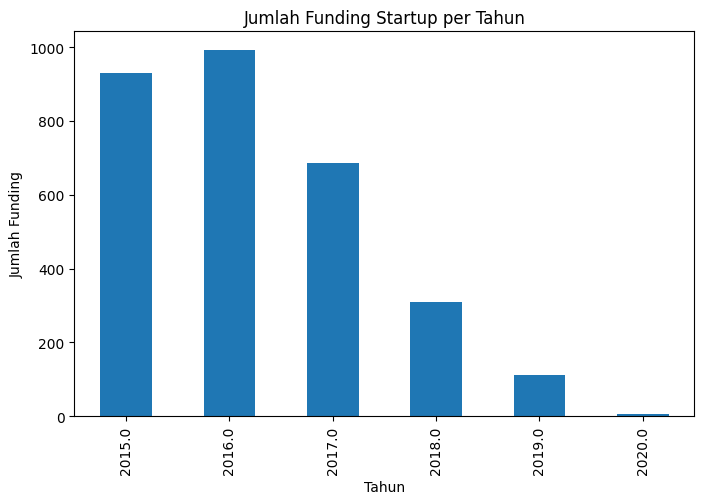

In [54]:
# Step 10 — EDA Awal

# 10.1 Jumlah Funding per Tahun
funding_count_by_year = df.groupby('year')['startup_name'].count()

funding_count_by_year

funding_count_by_year.plot(kind='bar', figsize=(8, 5))

plt.title('Jumlah Funding Startup per Tahun')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Funding')
plt.show()

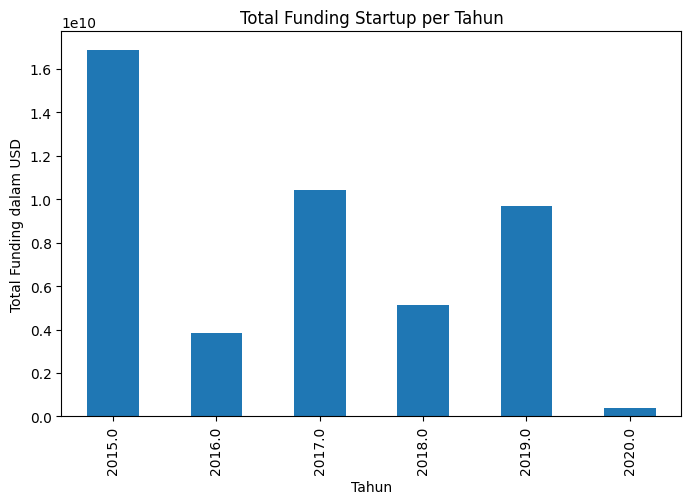

In [55]:
# 10.2 Total Funding per Tahun

funding_amount_by_year = df.groupby('year')['amount_clean'].sum()

funding_amount_by_year

funding_amount_by_year.plot(kind='bar', figsize=(8, 5))

plt.title('Total Funding Startup per Tahun')
plt.xlabel('Tahun')
plt.ylabel('Total Funding dalam USD')
plt.show()

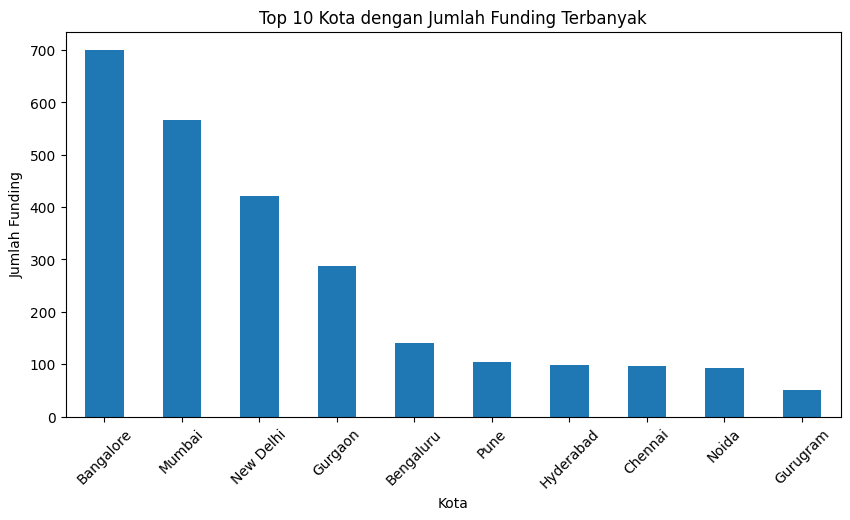

In [56]:
# 10.3 Kota dengan Jumlah Funding Terbanyak

top_city_count = df['city'].value_counts().head(10)

top_city_count
top_city_count.plot(kind='bar', figsize=(10, 5))

plt.title('Top 10 Kota dengan Jumlah Funding Terbanyak')
plt.xlabel('Kota')
plt.ylabel('Jumlah Funding')
plt.xticks(rotation=45)
plt.show()

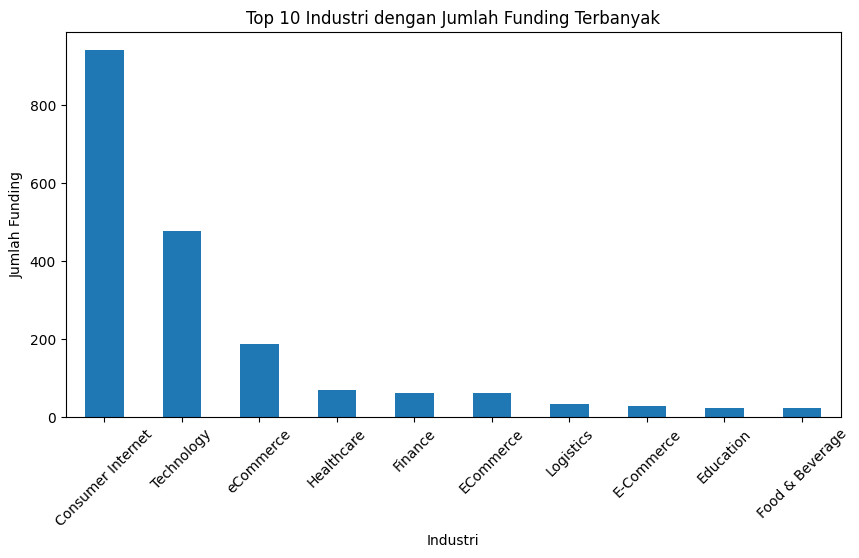

In [57]:
# 10.4 Industri dengan Jumlah Funding Terbanyak

top_industry_count = df['industry'].value_counts().head(10)

top_industry_count
top_industry_count.plot(kind='bar', figsize=(10, 5))

plt.title('Top 10 Industri dengan Jumlah Funding Terbanyak')
plt.xlabel('Industri')
plt.ylabel('Jumlah Funding')
plt.xticks(rotation=45)
plt.show()

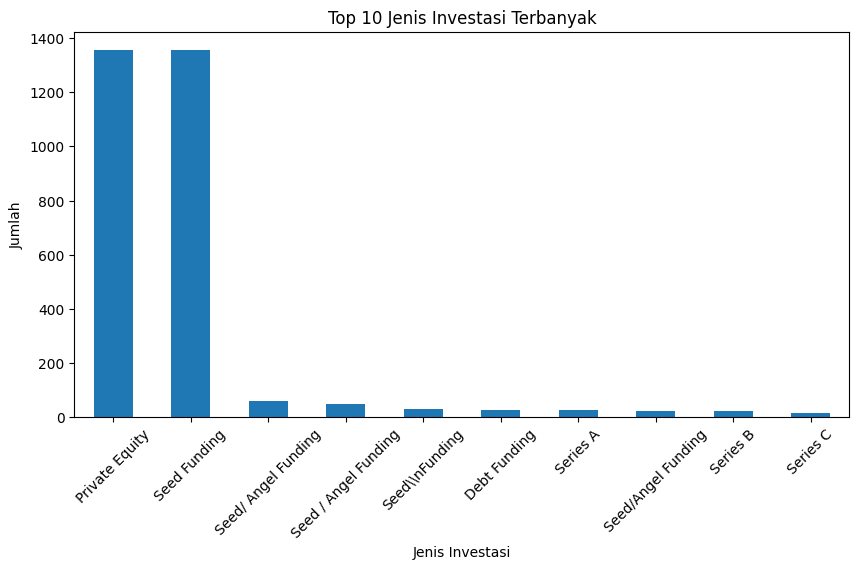

In [58]:
# 10.5 Jenis Investasi Terbanyak

top_investment_type = df['investment_type'].value_counts().head(10)

top_investment_type
top_investment_type.plot(kind='bar', figsize=(10, 5))

plt.title('Top 10 Jenis Investasi Terbanyak')
plt.xlabel('Jenis Investasi')
plt.ylabel('Jumlah')
plt.xticks(rotation=45)
plt.show()

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

df = pd.read_csv('/content/startup_funding.csv')

df = df.rename(columns={
    'Sr No': 'sr_no',
    'Date dd/mm/yyyy': 'date',
    'Startup Name': 'startup_name',
    'Industry Vertical': 'industry',
    'SubVertical': 'sub_vertical',
    'City  Location': 'city',
    'Investors Name': 'investors',
    'InvestmentnType': 'investment_type',
    'Amount in USD': 'amount_usd',
    'Remarks': 'remarks'
})

STEP 11 selesai: Nama kota berhasil distandarisasi.

Top 10 kota sebelum cleaning:


,count
city,
Bangalore,700
Mumbai,567
New Delhi,421
Gurgaon,287
Bengaluru,141
Pune,105
Hyderabad,99
Chennai,97
Noida,92



Top 10 kota setelah cleaning:


,count
city_clean,
Bengaluru,850
Mumbai,572
New Delhi,459
Gurugram,338
Pune,112
Hyderabad,100
Chennai,98
Noida,93
Ahmedabad,40


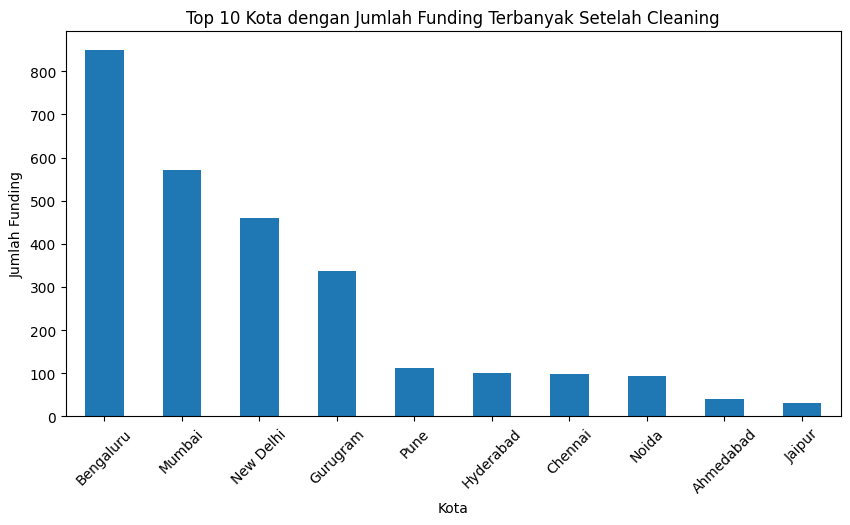

In [60]:
# STEP 11 Standarisasi Nama Kota

import re
import numpy as np
import matplotlib.pyplot as plt

def fix_text(value):
    if pd.isnull(value):
        return np.nan

    value = str(value).strip()

    # Membersihkan karakter aneh seperti \xc2\xa0
    value = value.replace('\\xc2\\xa0', ' ')
    value = value.replace('\\xa0', ' ')
    value = value.replace('\xa0', ' ')
    value = re.sub(r'\\x[a-fA-F0-9]{2}', ' ', value)

    # Merapikan spasi berlebih
    value = re.sub(r'\s+', ' ', value)

    return value.strip()


def standardize_city(city):
    if pd.isnull(city):
        return np.nan

    city = fix_text(city)

    # Kalau ada format seperti "Bangalore / SFO", ambil kota pertama
    city = re.split(r'/|,', city)[0].strip()

    # Ubah format tulisan menjadi title case
    city = city.title()

    # Mapping nama kota yang sama tapi penulisannya berbeda
    city_mapping = {
        'Bangalore': 'Bengaluru',
        'Gurgaon': 'Gurugram',
        'Delhi': 'New Delhi',
        'Ahemadabad': 'Ahmedabad',
        'Kolkatta': 'Kolkata',
        'Kormangala': 'Bengaluru',
        'Koramangala': 'Bengaluru'
    }

    return city_mapping.get(city, city)


# Membuat kolom baru city_clean
df['city_clean'] = df['city'].apply(standardize_city)

print("STEP 11 selesai: Nama kota berhasil distandarisasi.")

print("\nTop 10 kota sebelum cleaning:")
display(df['city'].value_counts().head(10))

print("\nTop 10 kota setelah cleaning:")
display(df['city_clean'].value_counts().head(10))


# Visualisasi ulang setelah nama kota dibersihkan
top_city_clean = df['city_clean'].value_counts().head(10)

plt.figure(figsize=(10, 5))
top_city_clean.plot(kind='bar')

plt.title('Top 10 Kota dengan Jumlah Funding Terbanyak Setelah Cleaning')
plt.xlabel('Kota')
plt.ylabel('Jumlah Funding')
plt.xticks(rotation=45)
plt.show()

STEP 12 selesai: Jenis investasi berhasil distandarisasi.

Top 15 jenis investasi sebelum cleaning:


,count
investment_type,
Private Equity,1356
Seed Funding,1355
Seed/ Angel Funding,60
Seed / Angel Funding,47
Seed\\nFunding,30
Debt Funding,25
Series A,24
Seed/Angel Funding,23
Series B,20



Top 15 jenis investasi setelah cleaning:


,count
investment_type_clean,
Seed Funding,1401
Private Equity,1367
Seed/Angel Funding,138
Debt Funding,30
Series A,24
Series B,21
Series C,14
Series D,12
Pre-Series A,9


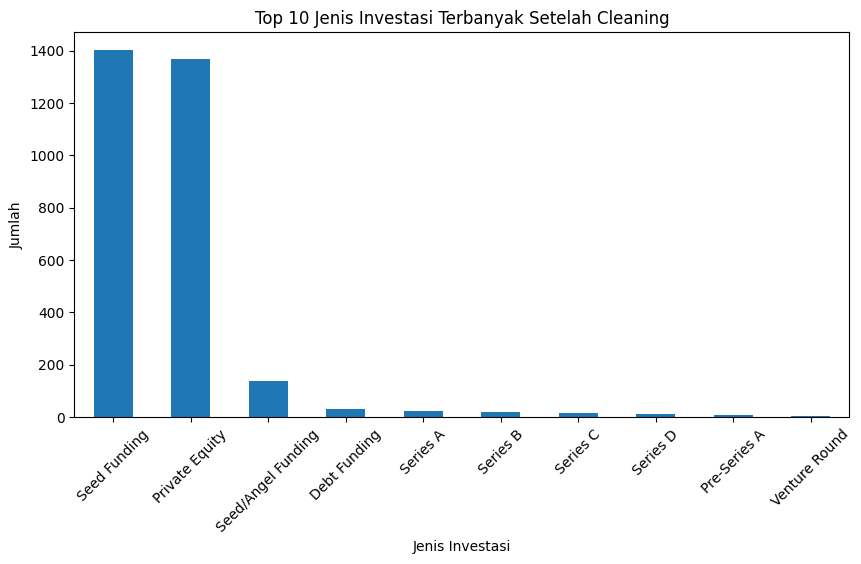

In [61]:
# STEP 12 Standarisasi Jenis Investasi

def standardize_investment_type(value):
    if pd.isnull(value):
        return np.nan

    value = fix_text(value).lower()
    value = value.replace('\\n', ' ')
    value = value.replace('-', ' ')
    value = value.replace('/', ' ')
    value = re.sub(r'\s+', ' ', value).strip()

    # Standarisasi Series Funding
    if 'pre' in value and 'series a' in value:
        return 'Pre-Series A'

    series_match = re.search(r'series\s*([a-j])', value)
    if series_match:
        return 'Series ' + series_match.group(1).upper()

    # Standarisasi Seed dan Angel
    if 'seed' in value and 'angel' in value:
        return 'Seed/Angel Funding'

    if 'seed' in value:
        return 'Seed Funding'

    if 'angel' in value:
        return 'Angel Funding'

    # Standarisasi Private Equity
    if 'private' in value or 'equity' in value:
        return 'Private Equity'

    # Standarisasi Debt
    if 'debt' in value or 'term loan' in value:
        return 'Debt Funding'

    # Standarisasi Venture
    if 'venture' in value:
        return 'Venture Round'

    # Standarisasi Crowd Funding
    if 'crowd' in value:
        return 'Crowd Funding'

    # Standarisasi Corporate
    if 'corporate' in value:
        return 'Corporate Round'

    # Standarisasi Funding Round umum
    if 'funding' in value or 'round' in value:
        return 'Other Funding Round'

    return value.title()


# Membuat kolom baru investment_type_clean
df['investment_type_clean'] = df['investment_type'].apply(standardize_investment_type)

print("STEP 12 selesai: Jenis investasi berhasil distandarisasi.")

print("\nTop 15 jenis investasi sebelum cleaning:")
display(df['investment_type'].value_counts().head(15))

print("\nTop 15 jenis investasi setelah cleaning:")
display(df['investment_type_clean'].value_counts().head(15))


# Visualisasi ulang setelah jenis investasi dibersihkan
top_investment_type_clean = df['investment_type_clean'].value_counts().head(10)

plt.figure(figsize=(10, 5))
top_investment_type_clean.plot(kind='bar')

plt.title('Top 10 Jenis Investasi Terbanyak Setelah Cleaning')
plt.xlabel('Jenis Investasi')
plt.ylabel('Jumlah')
plt.xticks(rotation=45)
plt.show()

STEP 13 selesai: Industri berhasil dikelompokkan.

Top 15 industri sebelum grouping:


,count
industry,
Consumer Internet,941
Technology,478
eCommerce,186
Healthcare,70
Finance,62
ECommerce,61
Logistics,32
E-Commerce,29
Education,24



Jumlah data berdasarkan industry_group:


,count
industry_group,
E-commerce,579
Consumer Internet,524
Technology/SaaS,468
Others,269
FinTech/Finance,263
Healthcare/HealthTech,256
Logistics/Transportation,163
EdTech/Education,160
Food & Beverage,134


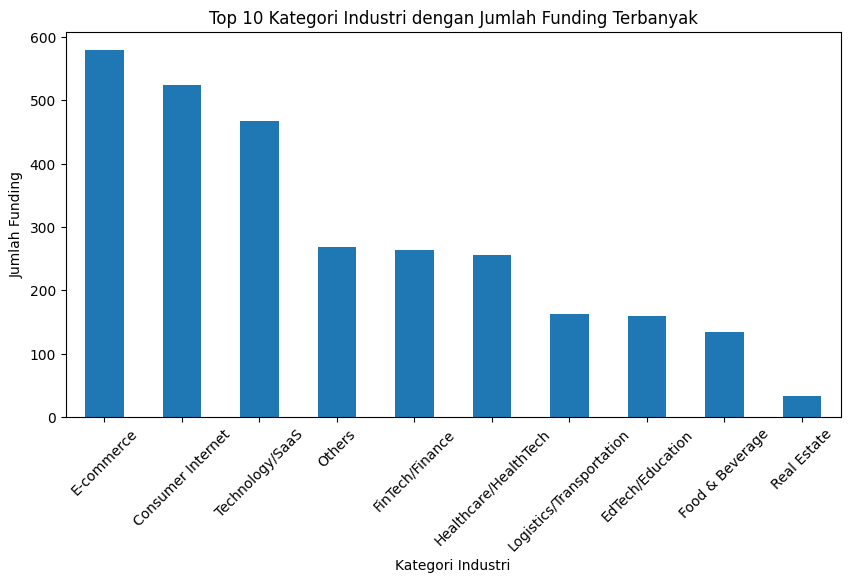

In [62]:
# STEP 13 Pengelompokan Industri
def categorize_industry(industry, sub_vertical):
    text = ''

    if pd.notnull(industry):
        text += ' ' + fix_text(industry).lower()

    if pd.notnull(sub_vertical):
        text += ' ' + fix_text(sub_vertical).lower()

    if text.strip() == '':
        return np.nan

    # E-commerce
    if any(word in text for word in [
        'ecommerce', 'e-commerce', 'e commerce', 'online retail',
        'marketplace', 'grocery', 'fashion', 'retail', 'shopping'
    ]):
        return 'E-commerce'

    # FinTech / Finance
    elif any(word in text for word in [
        'fintech', 'fin-tech', 'finance', 'financial', 'payment',
        'wallet', 'lending', 'loan', 'investment', 'banking',
        'insurance', 'wealth'
    ]):
        return 'FinTech/Finance'

    # Education
    elif any(word in text for word in [
        'edtech', 'ed-tech', 'education', 'e-learning',
        'learning', 'school', 'college', 'student', 'tutor'
    ]):
        return 'EdTech/Education'

    # Healthcare
    elif any(word in text for word in [
        'health', 'healthcare', 'medical', 'doctor',
        'hospital', 'fitness', 'wellness', 'pharma'
    ]):
        return 'Healthcare/HealthTech'

    # Food & Beverage
    elif any(word in text for word in [
        'food', 'restaurant', 'beverage', 'dining',
        'cafe', 'kitchen', 'meal'
    ]):
        return 'Food & Beverage'

    # Logistics / Transportation
    elif any(word in text for word in [
        'logistics', 'transport', 'transportation', 'taxi',
        'cab', 'delivery', 'shuttle', 'mobility', 'automobile',
        'vehicle'
    ]):
        return 'Logistics/Transportation'

    # Consumer Internet
    elif any(word in text for word in [
        'consumer internet', 'social media', 'hyperlocal',
        'digital media', 'online platform'
    ]):
        return 'Consumer Internet'

    # Technology / SaaS
    elif any(word in text for word in [
        'technology', 'tech', 'saas', 'software', 'analytics',
        'artificial intelligence', 'machine learning', 'ai',
        'iot', 'cloud', 'automation', 'data', 'cybersecurity',
        'enterprise'
    ]):
        return 'Technology/SaaS'

    # Travel / Hospitality
    elif any(word in text for word in [
        'travel', 'hotel', 'hospitality', 'tourism',
        'booking', 'accommodation'
    ]):
        return 'Travel/Hospitality'

    # Real Estate
    elif any(word in text for word in [
        'real estate', 'property', 'housing', 'rental'
    ]):
        return 'Real Estate'

    else:
        return 'Others'


# Membuat kolom baru industry_group
df['industry_group'] = df.apply(
    lambda row: categorize_industry(row['industry'], row['sub_vertical']),
    axis=1
)

print("STEP 13 selesai: Industri berhasil dikelompokkan.")

print("\nTop 15 industri sebelum grouping:")
display(df['industry'].value_counts().head(15))

print("\nJumlah data berdasarkan industry_group:")
display(df['industry_group'].value_counts())


# Visualisasi top industri setelah grouping
top_industry_group = df['industry_group'].value_counts().head(10)

plt.figure(figsize=(10, 5))
top_industry_group.plot(kind='bar')

plt.title('Top 10 Kategori Industri dengan Jumlah Funding Terbanyak')
plt.xlabel('Kategori Industri')
plt.ylabel('Jumlah Funding')
plt.xticks(rotation=45)
plt.show()

In [63]:
# STEP 13.5 - Membuat Kolom Amount dalam Juta USD

# Cek dulu apakah kolom amount_clean sudah ada
print("Daftar kolom saat ini:")
print(df.columns)

# Jika amount_clean sudah ada, buat amount_million_usd
if 'amount_clean' in df.columns:
    df['amount_million_usd'] = df['amount_clean'] / 1_000_000
    print("\nKolom amount_million_usd berhasil dibuat dari amount_clean.")
else:
    print("\nKolom amount_clean belum ada. Kita buat ulang dari amount_usd.")

    def clean_amount(value):
        if pd.isnull(value):
            return np.nan

        value = fix_text(value)
        value = str(value).strip().lower()

        invalid_values = ['undisclosed', 'unknown', 'n/a', 'na', 'nan', 'none', '']

        if value in invalid_values:
            return np.nan

        if 'undisclosed' in value or 'unknown' in value:
            return np.nan

        value = value.replace(',', '')
        value = value.replace('$', '')
        value = value.replace('usd', '')

        value = re.sub(r'[^0-9.]', '', value)

        if value == '':
            return np.nan

        try:
            return float(value)
        except:
            return np.nan

    df['amount_clean'] = df['amount_usd'].apply(clean_amount)
    df['amount_million_usd'] = df['amount_clean'] / 1_000_000

    print("\nKolom amount_clean dan amount_million_usd berhasil dibuat ulang.")

print("\nContoh hasil:")
display(df[['amount_usd', 'amount_clean', 'amount_million_usd']].head(10))

print("\nStatistik amount_million_usd:")
display(df['amount_million_usd'].describe())

Daftar kolom saat ini:
Index(['sr_no', 'date', 'startup_name', 'industry', 'sub_vertical', 'city',
       'investors', 'investment_type', 'amount_usd', 'remarks', 'city_clean',
       'investment_type_clean', 'industry_group'],
      dtype='object')

Kolom amount_clean belum ada. Kita buat ulang dari amount_usd.

Kolom amount_clean dan amount_million_usd berhasil dibuat ulang.

Contoh hasil:


,amount_usd,amount_clean,amount_million_usd
0,"20,00,00,000",200000000.0,200.000000
1,"80,48,394",8048394.0,8.048394
2,"1,83,58,860",18358860.0,18.358860
3,"30,00,000",3000000.0,3.000000
4,"18,00,000",1800000.0,1.800000
5,"90,00,000",9000000.0,9.000000
6,"15,00,00,000",150000000.0,150.000000
7,"60,00,000",6000000.0,6.000000
8,"7,00,00,000",70000000.0,70.000000
9,"5,00,00,000",50000000.0,50.000000



Statistik amount_million_usd:


,amount_million_usd
count,2073.000000
mean,18.400345
std,121.140713
min,0.016000
25%,0.486000
50%,1.750000
75%,8.000000
max,3900.000000


STEP 14: Ringkasan Funding Berdasarkan Industri


,jumlah_funding,jumlah_startup_unik,total_funding_juta_usd,rata_rata_funding_juta_usd,median_funding_juta_usd
industry_group,,,,,
E-commerce,579,465,13166.288693,34.109556,3.0
Logistics/Transportation,163,131,7146.117624,61.077928,4.5
FinTech/Finance,263,219,4921.110265,23.212784,5.0
Technology/SaaS,468,433,2936.189100,9.502230,1.8
Consumer Internet,524,481,2498.198920,7.905693,1.0
Others,269,260,2013.756635,10.654797,1.0
Healthcare/HealthTech,256,216,1870.469000,11.475270,1.1
EdTech/Education,160,141,1010.204065,8.939859,1.0
Food & Beverage,134,104,972.669195,9.925196,2.0


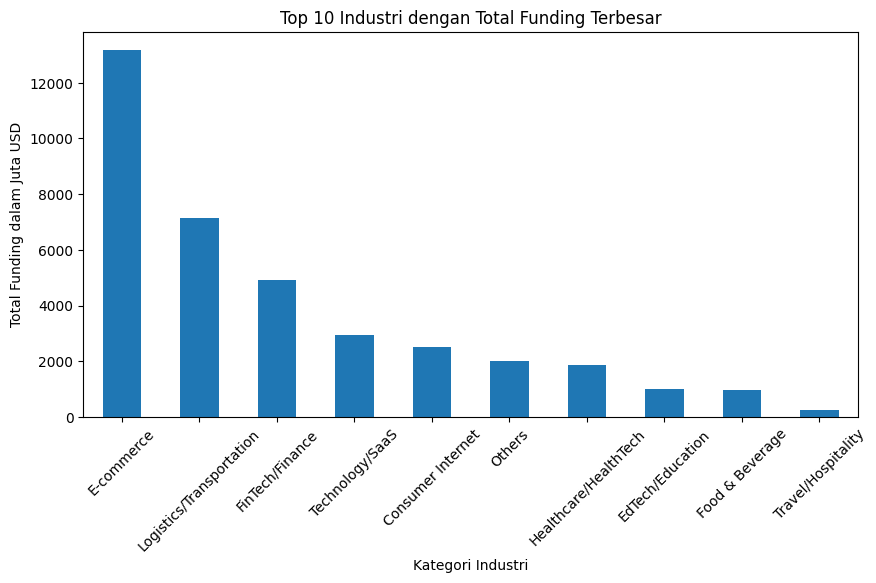


Insight Awal STEP 14:
1. Industri dengan total funding terbesar adalah E-commerce dengan total sekitar 13,166.29 juta USD.
2. Industri dengan jumlah funding terbanyak adalah E-commerce dengan 579.0 kali funding.
3. Jika industri dengan total funding terbesar berbeda dari industri dengan jumlah funding terbanyak, artinya ada industri yang tidak terlalu sering didanai tetapi menerima nilai pendanaan besar.


In [64]:
# STEP 14 Total Funding Berdasarkan Industri

industry_funding = df.groupby('industry_group').agg(
    jumlah_funding=('startup_name', 'count'),
    jumlah_startup_unik=('startup_name', 'nunique'),
    total_funding_juta_usd=('amount_million_usd', 'sum'),
    rata_rata_funding_juta_usd=('amount_million_usd', 'mean'),
    median_funding_juta_usd=('amount_million_usd', 'median')
).sort_values(by='total_funding_juta_usd', ascending=False)

print("STEP 14: Ringkasan Funding Berdasarkan Industri")
display(industry_funding)


# Visualisasi total funding berdasarkan industri
top_industry_funding = industry_funding['total_funding_juta_usd'].head(10)

plt.figure(figsize=(10, 5))
top_industry_funding.plot(kind='bar')

plt.title('Top 10 Industri dengan Total Funding Terbesar')
plt.xlabel('Kategori Industri')
plt.ylabel('Total Funding dalam Juta USD')
plt.xticks(rotation=45)
plt.show()


# Insight otomatis sederhana
top_industry_by_amount = industry_funding.index[0]
top_amount = industry_funding.iloc[0]['total_funding_juta_usd']

industry_funding_by_count = industry_funding.sort_values(by='jumlah_funding', ascending=False)
top_industry_by_count = industry_funding_by_count.index[0]
top_count = industry_funding_by_count.iloc[0]['jumlah_funding']

print("\nInsight Awal STEP 14:")
print(f"1. Industri dengan total funding terbesar adalah {top_industry_by_amount} dengan total sekitar {top_amount:,.2f} juta USD.")
print(f"2. Industri dengan jumlah funding terbanyak adalah {top_industry_by_count} dengan {top_count} kali funding.")
print("3. Jika industri dengan total funding terbesar berbeda dari industri dengan jumlah funding terbanyak, artinya ada industri yang tidak terlalu sering didanai tetapi menerima nilai pendanaan besar.")

STEP 15: Ringkasan Funding Berdasarkan Kota


,jumlah_funding,jumlah_startup_unik,total_funding_juta_usd,rata_rata_funding_juta_usd,median_funding_juta_usd
city_clean,,,,,
Bengaluru,850,669,18797.708863,31.752887,2.25
Mumbai,572,487,4939.225015,12.165579,2.00
Gurugram,338,264,3872.428658,16.001771,2.50
New Delhi,459,400,3358.571515,12.531983,1.00
Noida,93,80,1263.164000,22.556500,1.00
Chennai,98,88,718.767000,9.583560,2.50
Pune,112,98,717.582000,9.319247,2.00
Menlo Park,1,1,450.000000,450.000000,450.00
Hyderabad,100,92,401.676230,5.502414,1.00


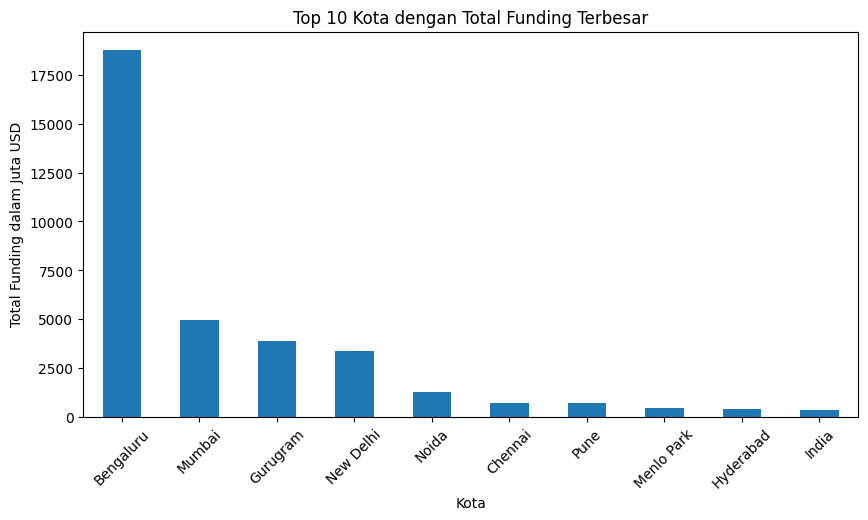

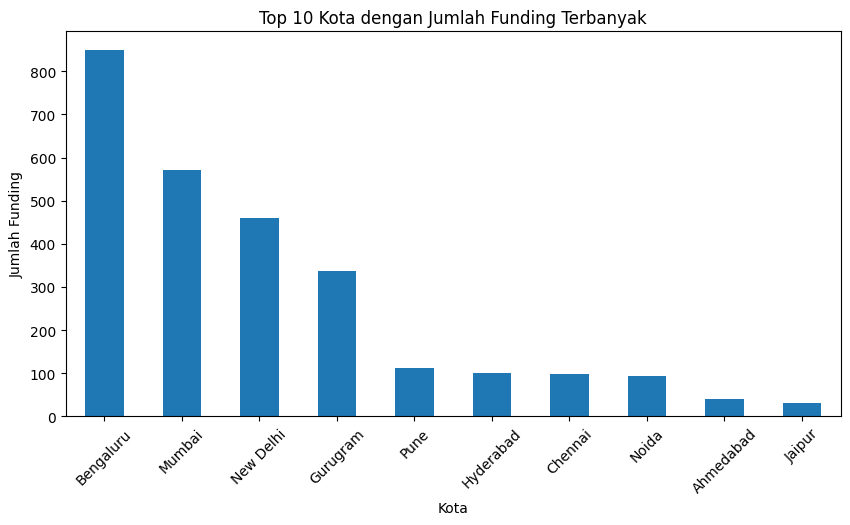


Insight Awal STEP 15:
1. Kota dengan total funding terbesar adalah Bengaluru dengan total sekitar 18,797.71 juta USD.
2. Kota dengan jumlah funding terbanyak adalah Bengaluru dengan 850.0 kali funding.
3. Jika kota dengan total funding terbesar berbeda dari kota dengan jumlah funding terbanyak, berarti ada kota yang jumlah deal-nya lebih sedikit tetapi nilai pendanaannya lebih besar.


In [65]:
# STEP 15 Total Funding Berdasarkan Kota

city_funding = df.groupby('city_clean').agg(
    jumlah_funding=('startup_name', 'count'),
    jumlah_startup_unik=('startup_name', 'nunique'),
    total_funding_juta_usd=('amount_million_usd', 'sum'),
    rata_rata_funding_juta_usd=('amount_million_usd', 'mean'),
    median_funding_juta_usd=('amount_million_usd', 'median')
).sort_values(by='total_funding_juta_usd', ascending=False)

print("STEP 15: Ringkasan Funding Berdasarkan Kota")
display(city_funding.head(15))


# Visualisasi Top 10 kota dengan total funding terbesar
top_city_funding = city_funding['total_funding_juta_usd'].head(10)

plt.figure(figsize=(10, 5))
top_city_funding.plot(kind='bar')

plt.title('Top 10 Kota dengan Total Funding Terbesar')
plt.xlabel('Kota')
plt.ylabel('Total Funding dalam Juta USD')
plt.xticks(rotation=45)
plt.show()


# Visualisasi Top 10 kota dengan jumlah funding terbanyak
top_city_count = city_funding.sort_values(by='jumlah_funding', ascending=False)['jumlah_funding'].head(10)

plt.figure(figsize=(10, 5))
top_city_count.plot(kind='bar')

plt.title('Top 10 Kota dengan Jumlah Funding Terbanyak')
plt.xlabel('Kota')
plt.ylabel('Jumlah Funding')
plt.xticks(rotation=45)
plt.show()


# Insight otomatis sederhana
top_city_by_amount = city_funding.index[0]
top_city_amount = city_funding.iloc[0]['total_funding_juta_usd']

city_funding_by_count = city_funding.sort_values(by='jumlah_funding', ascending=False)
top_city_by_count = city_funding_by_count.index[0]
top_city_count_value = city_funding_by_count.iloc[0]['jumlah_funding']

print("\nInsight Awal STEP 15:")
print(f"1. Kota dengan total funding terbesar adalah {top_city_by_amount} dengan total sekitar {top_city_amount:,.2f} juta USD.")
print(f"2. Kota dengan jumlah funding terbanyak adalah {top_city_by_count} dengan {top_city_count_value} kali funding.")
print("3. Jika kota dengan total funding terbesar berbeda dari kota dengan jumlah funding terbanyak, berarti ada kota yang jumlah deal-nya lebih sedikit tetapi nilai pendanaannya lebih besar.")

In [66]:
# STEP 16 Bersihkan Tanggal dan Buat Kolom Tahun/Bulan

def clean_date(value):
    if pd.isnull(value):
        return np.nan

    value = str(value).strip()

    # Mengganti pemisah tanggal yang tidak konsisten
    value = value.replace('.', '/')
    value = value.replace('-', '/')
    value = value.replace('//', '/')

    # Membersihkan spasi
    value = re.sub(r'\s+', '', value)

    # Memperbaiki format seperti 05/072018 menjadi 05/07/2018
    value = re.sub(r'^(\d{1,2})/(\d{2})(\d{4})$', r'\1/\2/\3', value)

    # Memperbaiki format seperti 01/07/015 menjadi 01/07/2015
    value = re.sub(r'/(\d{3})$', lambda x: '/2' + x.group(1), value)

    return value


# Membersihkan kolom date
df['date_clean'] = df['date'].apply(clean_date)

# Mengubah menjadi datetime
df['date_clean'] = pd.to_datetime(df['date_clean'], dayfirst=True, errors='coerce')

# Membuat kolom tahun dan bulan
df['year'] = df['date_clean'].dt.year.astype('Int64')
df['month'] = df['date_clean'].dt.month.astype('Int64')
df['month_name'] = df['date_clean'].dt.month_name()

print("STEP 16 selesai: Kolom tanggal, tahun, dan bulan berhasil dibuat.")

print("\nContoh hasil tanggal setelah cleaning:")
display(df[['date', 'date_clean', 'year', 'month', 'month_name']].head(10))

print("\nJumlah tanggal yang gagal diproses:")
print(df['date_clean'].isnull().sum())

print("\nData yang tanggalnya gagal diproses:")
display(df[df['date_clean'].isnull()][['sr_no', 'date', 'startup_name', 'city_clean', 'industry_group', 'amount_usd']])

STEP 16 selesai: Kolom tanggal, tahun, dan bulan berhasil dibuat.

Contoh hasil tanggal setelah cleaning:


,date,date_clean,year,month,month_name
0,09/01/2020,2020-01-09,2020,1,January
1,13/01/2020,2020-01-13,2020,1,January
2,09/01/2020,2020-01-09,2020,1,January
3,02/01/2020,2020-01-02,2020,1,January
4,02/01/2020,2020-01-02,2020,1,January
5,13/01/2020,2020-01-13,2020,1,January
6,10/01/2020,2020-01-10,2020,1,January
7,12/12/2019,2019-12-12,2019,12,December
8,06/12/2019,2019-12-06,2019,12,December
9,03/12/2019,2019-12-03,2019,12,December



Jumlah tanggal yang gagal diproses:
1

Data yang tanggalnya gagal diproses:


,sr_no,date,startup_name,city_clean,industry_group,amount_usd
2606,2607,\\xc2\\xa010/7/2015,\\xc2\\xa0Infinity Assurance,\ \ New Delhi,Others,"\\xc2\\xa0600,000"


In [67]:
# STEP 16.5 Memperbaiki Tanggal yang Gagal Diproses

# Membersihkan ulang kolom date dari karakter aneh
df['date_fixed'] = df['date'].astype(str)

df['date_fixed'] = df['date_fixed'].str.replace(r'\\xc2\\xa0', '', regex=True)
df['date_fixed'] = df['date_fixed'].str.replace(r'\\xa0', '', regex=True)
df['date_fixed'] = df['date_fixed'].str.replace('\xa0', '', regex=False)
df['date_fixed'] = df['date_fixed'].str.strip()

# Ubah lagi menjadi datetime
df['date_clean'] = pd.to_datetime(df['date_fixed'], dayfirst=True, errors='coerce')

# Buat ulang kolom tahun dan bulan
df['year'] = df['date_clean'].dt.year.astype('Int64')
df['month'] = df['date_clean'].dt.month.astype('Int64')
df['month_name'] = df['date_clean'].dt.month_name()

print("STEP 16.5 selesai: Tanggal yang gagal diproses sudah diperbaiki.")

print("\nJumlah tanggal yang masih gagal diproses:")
print(df['date_clean'].isnull().sum())

print("\nCek data yang sebelumnya bermasalah:")
display(df.loc[df['sr_no'] == 2607, ['sr_no', 'date', 'date_fixed', 'date_clean', 'year', 'month', 'month_name']])

STEP 16.5 selesai: Tanggal yang gagal diproses sudah diperbaiki.

Jumlah tanggal yang masih gagal diproses:
8

Cek data yang sebelumnya bermasalah:


,sr_no,date,date_fixed,date_clean,year,month,month_name
2606,2607,\\xc2\\xa010/7/2015,\\xc2\10/7/2015,NaT,<NA>,<NA>,NaN


In [68]:
# STEP 16.6 Perbaikan Tanggal Versi Robust

import re
import numpy as np
import pandas as pd

def clean_date_robust(value):
    if pd.isnull(value):
        return np.nan

    value = str(value).strip()

    # Menghapus karakter escape seperti \xc2 dan \xa0
    value = re.sub(r'\\x[a-fA-F0-9]{2}', '', value)

    # Menghapus karakter slash/backslash sisa yang tidak diperlukan
    value = value.replace('\\', '')
    value = value.replace('\xa0', '')

    # Menyamakan pemisah tanggal
    value = value.replace('.', '/')
    value = value.replace('-', '/')

    # Menghapus spasi
    value = re.sub(r'\s+', '', value)

    # Kasus format seperti 05/072018
    match_wrong = re.search(r'(\d{1,2})/(\d{2})(\d{4})', value)
    if match_wrong:
        day = match_wrong.group(1)
        month = match_wrong.group(2)
        year = match_wrong.group(3)
        return f"{day}/{month}/{year}"

    # Kasus format normal seperti 10/7/2015 atau 09/01/2020
    match_normal = re.search(r'(\d{1,2})/(\d{1,2})/(\d{2,4})', value)
    if match_normal:
        day = match_normal.group(1)
        month = match_normal.group(2)
        year = match_normal.group(3)

        # Jika tahun hanya 3 digit, contoh 015, ubah menjadi 2015
        if len(year) == 3:
            year = '2' + year

        # Jika tahun hanya 2 digit, contoh 15, ubah menjadi 2015
        if len(year) == 2:
            year = '20' + year

        return f"{day}/{month}/{year}"

    return np.nan


# Gunakan kolom date asli, bukan date_fixed
df['date_fixed'] = df['date'].apply(clean_date_robust)

# Ubah ke datetime
df['date_clean'] = pd.to_datetime(df['date_fixed'], dayfirst=True, errors='coerce')

# Buat ulang kolom tahun dan bulan
df['year'] = df['date_clean'].dt.year.astype('Int64')
df['month'] = df['date_clean'].dt.month.astype('Int64')
df['month_name'] = df['date_clean'].dt.month_name()

print("STEP 16.6 selesai: Tanggal dibersihkan ulang dengan metode robust.")

print("\nJumlah tanggal yang masih gagal diproses:")
print(df['date_clean'].isnull().sum())

print("\nCek data yang sebelumnya bermasalah:")
display(df.loc[df['sr_no'] == 2607, ['sr_no', 'date', 'date_fixed', 'date_clean', 'year', 'month', 'month_name']])

print("\nData yang masih gagal diproses:")
display(df[df['date_clean'].isnull()][['sr_no', 'date', 'date_fixed', 'startup_name', 'city_clean', 'industry_group', 'amount_usd']])

STEP 16.6 selesai: Tanggal dibersihkan ulang dengan metode robust.

Jumlah tanggal yang masih gagal diproses:
1

Cek data yang sebelumnya bermasalah:


,sr_no,date,date_fixed,date_clean,year,month,month_name
2606,2607,\\xc2\\xa010/7/2015,10/7/2015,2015-07-10,2015,7,July



Data yang masih gagal diproses:


,sr_no,date,date_fixed,startup_name,city_clean,industry_group,amount_usd
3029,3030,22/01//2015,NaN,Corporate360,NaN,NaN,"2,00,000"


In [69]:
# STEP 16.7 Memperbaiki Sisa Tanggal yang Masih Gagal

def clean_date_final(value):
    if pd.isnull(value):
        return np.nan

    value = str(value).strip()

    # Menghapus karakter escape seperti \xc2 dan \xa0
    value = re.sub(r'\\x[a-fA-F0-9]{2}', '', value)

    # Menghapus karakter backslash
    value = value.replace('\\', '')
    value = value.replace('\xa0', '')

    # Menyamakan pemisah tanggal
    value = value.replace('.', '/')
    value = value.replace('-', '/')

    # Memperbaiki slash ganda seperti 22/01//2015
    value = re.sub(r'/+', '/', value)

    # Menghapus spasi
    value = re.sub(r'\s+', '', value)

    # Kasus format seperti 05/072018
    match_wrong = re.search(r'(\d{1,2})/(\d{2})(\d{4})', value)
    if match_wrong:
        day = match_wrong.group(1)
        month = match_wrong.group(2)
        year = match_wrong.group(3)
        return f"{day}/{month}/{year}"

    # Kasus format normal seperti 22/01/2015
    match_normal = re.search(r'(\d{1,2})/(\d{1,2})/(\d{2,4})', value)
    if match_normal:
        day = match_normal.group(1)
        month = match_normal.group(2)
        year = match_normal.group(3)

        if len(year) == 3:
            year = '2' + year

        if len(year) == 2:
            year = '20' + year

        return f"{day}/{month}/{year}"

    return np.nan


# Bersihkan ulang tanggal dari kolom date asli
df['date_fixed'] = df['date'].apply(clean_date_final)

# Ubah ke datetime
df['date_clean'] = pd.to_datetime(df['date_fixed'], dayfirst=True, errors='coerce')

# Buat ulang kolom tahun dan bulan
df['year'] = df['date_clean'].dt.year.astype('Int64')
df['month'] = df['date_clean'].dt.month.astype('Int64')
df['month_name'] = df['date_clean'].dt.month_name()

print("STEP 16.7 selesai: Semua tanggal dibersihkan ulang.")

print("\nJumlah tanggal yang masih gagal diproses:")
print(df['date_clean'].isnull().sum())

print("\nCek data Corporate360:")
display(df.loc[df['sr_no'] == 3030, ['sr_no', 'date', 'date_fixed', 'date_clean', 'year', 'month', 'month_name']])

print("\nData yang masih gagal diproses:")
display(df[df['date_clean'].isnull()][['sr_no', 'date', 'date_fixed', 'startup_name', 'city_clean', 'industry_group', 'amount_usd']])

STEP 16.7 selesai: Semua tanggal dibersihkan ulang.

Jumlah tanggal yang masih gagal diproses:
0

Cek data Corporate360:


,sr_no,date,date_fixed,date_clean,year,month,month_name
3029,3030,22/01//2015,22/01/2015,2015-01-22,2015,1,January



Data yang masih gagal diproses:


,sr_no,date,date_fixed,startup_name,city_clean,industry_group,amount_usd


STEP 17: Ringkasan Funding per Tahun


,jumlah_funding,jumlah_startup_unik,total_funding_juta_usd,rata_rata_funding_juta_usd,median_funding_juta_usd
year,,,,,
2015,936,858,8673.022368,13.261502,1.50
2016,993,937,3828.088608,6.532574,1.00
2017,687,640,10429.309730,22.871293,2.25
2018,310,297,5122.368369,19.329692,4.00
2019,111,106,9700.918535,92.389700,12.00
2020,7,7,390.207254,55.743893,9.00


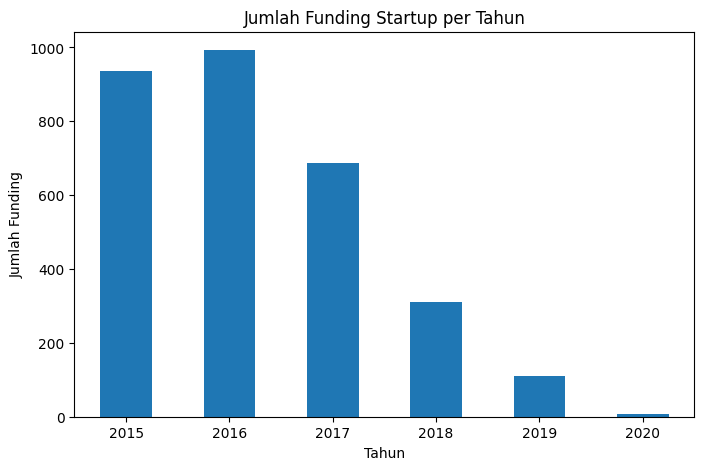

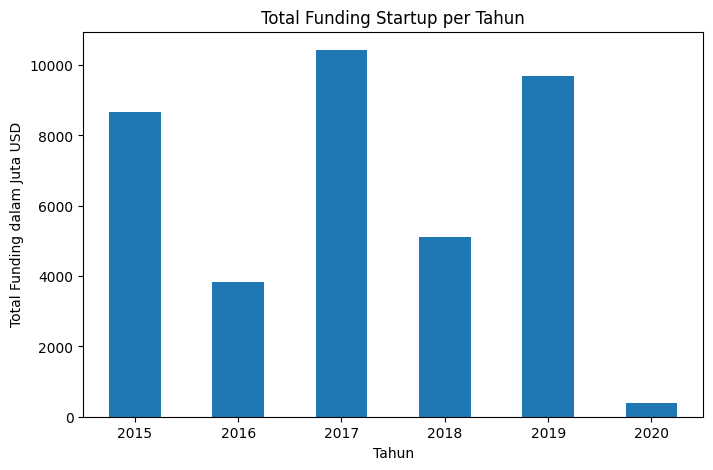

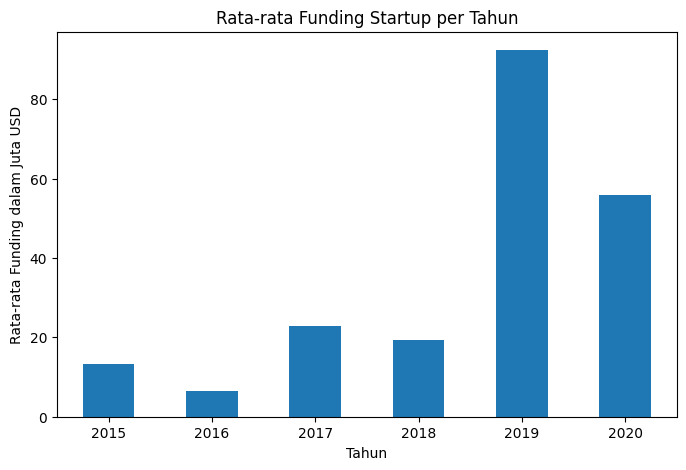

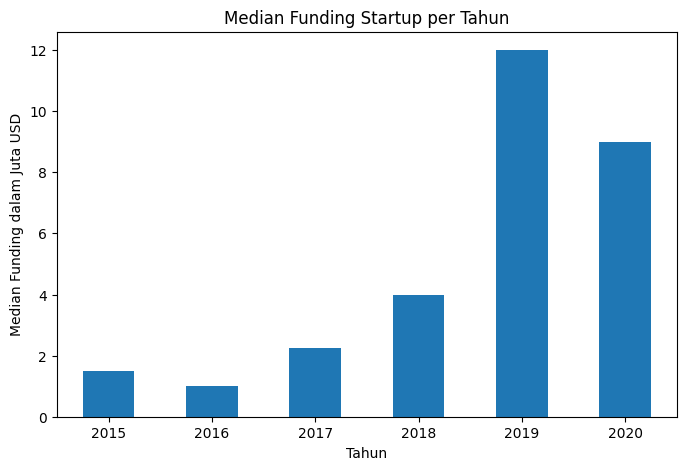


Insight Awal STEP 17:
1. Tahun dengan jumlah funding terbanyak adalah 2016 dengan 993 kali funding.
2. Tahun dengan total funding terbesar adalah 2017 dengan total sekitar 10,429.31 juta USD.
3. Tahun dengan rata-rata funding terbesar adalah 2019 dengan rata-rata sekitar 92.39 juta USD.
4. Catatan: Data tahun 2020 hanya sampai Januari, sehingga tidak boleh dibandingkan langsung dengan tahun penuh seperti 2015-2019.


In [70]:
# STEP 17 Tren Funding per Tahun Setelah Cleaning

# Membuat ringkasan funding per tahun
yearly_funding = df.groupby('year').agg(
    jumlah_funding=('startup_name', 'count'),
    jumlah_startup_unik=('startup_name', 'nunique'),
    total_funding_juta_usd=('amount_million_usd', 'sum'),
    rata_rata_funding_juta_usd=('amount_million_usd', 'mean'),
    median_funding_juta_usd=('amount_million_usd', 'median')
).sort_index()

print("STEP 17: Ringkasan Funding per Tahun")
display(yearly_funding)


# Visualisasi 1: Jumlah funding per tahun
plt.figure(figsize=(8, 5))
yearly_funding['jumlah_funding'].plot(kind='bar')

plt.title('Jumlah Funding Startup per Tahun')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Funding')
plt.xticks(rotation=0)
plt.show()


# Visualisasi 2: Total funding per tahun
plt.figure(figsize=(8, 5))
yearly_funding['total_funding_juta_usd'].plot(kind='bar')

plt.title('Total Funding Startup per Tahun')
plt.xlabel('Tahun')
plt.ylabel('Total Funding dalam Juta USD')
plt.xticks(rotation=0)
plt.show()


# Visualisasi 3: Rata-rata funding per tahun
plt.figure(figsize=(8, 5))
yearly_funding['rata_rata_funding_juta_usd'].plot(kind='bar')

plt.title('Rata-rata Funding Startup per Tahun')
plt.xlabel('Tahun')
plt.ylabel('Rata-rata Funding dalam Juta USD')
plt.xticks(rotation=0)
plt.show()


# Visualisasi 4: Median funding per tahun
plt.figure(figsize=(8, 5))
yearly_funding['median_funding_juta_usd'].plot(kind='bar')

plt.title('Median Funding Startup per Tahun')
plt.xlabel('Tahun')
plt.ylabel('Median Funding dalam Juta USD')
plt.xticks(rotation=0)
plt.show()


# Insight otomatis sederhana
top_year_count = yearly_funding['jumlah_funding'].idxmax()
top_year_count_value = yearly_funding.loc[top_year_count, 'jumlah_funding']

top_year_amount = yearly_funding['total_funding_juta_usd'].idxmax()
top_year_amount_value = yearly_funding.loc[top_year_amount, 'total_funding_juta_usd']

top_year_avg = yearly_funding['rata_rata_funding_juta_usd'].idxmax()
top_year_avg_value = yearly_funding.loc[top_year_avg, 'rata_rata_funding_juta_usd']

print("\nInsight Awal STEP 17:")
print(f"1. Tahun dengan jumlah funding terbanyak adalah {top_year_count} dengan {top_year_count_value} kali funding.")
print(f"2. Tahun dengan total funding terbesar adalah {top_year_amount} dengan total sekitar {top_year_amount_value:,.2f} juta USD.")
print(f"3. Tahun dengan rata-rata funding terbesar adalah {top_year_avg} dengan rata-rata sekitar {top_year_avg_value:,.2f} juta USD.")
print("4. Catatan: Data tahun 2020 hanya sampai Januari, sehingga tidak boleh dibandingkan langsung dengan tahun penuh seperti 2015-2019.")

STEP 18: Ringkasan Funding per Bulan


,jumlah_funding,jumlah_startup_unik,total_funding_juta_usd,rata_rata_funding_juta_usd,median_funding_juta_usd
year_month,,,,,
2015-01,53,51,370.171768,9.254294,0.625
2015-02,55,55,394.262600,9.387205,1.400
2015-03,60,60,463.327000,9.858021,2.500
2015-04,63,62,981.000000,18.865385,2.100
2015-05,61,61,326.185000,7.413295,1.500
2015-06,86,86,536.994000,9.258517,3.000
2015-07,98,98,1606.657000,22.952243,5.000
2015-08,98,98,1063.816000,16.366400,1.000
2015-09,88,87,1470.520000,24.106885,1.000



Data bulan terakhir:


,jumlah_funding,jumlah_startup_unik,total_funding_juta_usd,rata_rata_funding_juta_usd,median_funding_juta_usd
year_month,,,,,
2019-04,14,14,130.135355,9.295383,3.545688
2019-05,9,9,408.968600,58.424086,50.000000
2019-06,15,15,297.152710,19.810181,10.000000
2019-07,13,13,296.794605,22.830354,2.500000
2019-08,17,17,4531.770000,283.235625,28.500000
2019-09,9,9,502.800000,55.866667,5.000000
2019-10,3,3,630.000000,315.000000,315.000000
2019-11,15,15,2062.797265,147.342662,21.705633
2019-12,10,10,476.900000,47.690000,25.000000


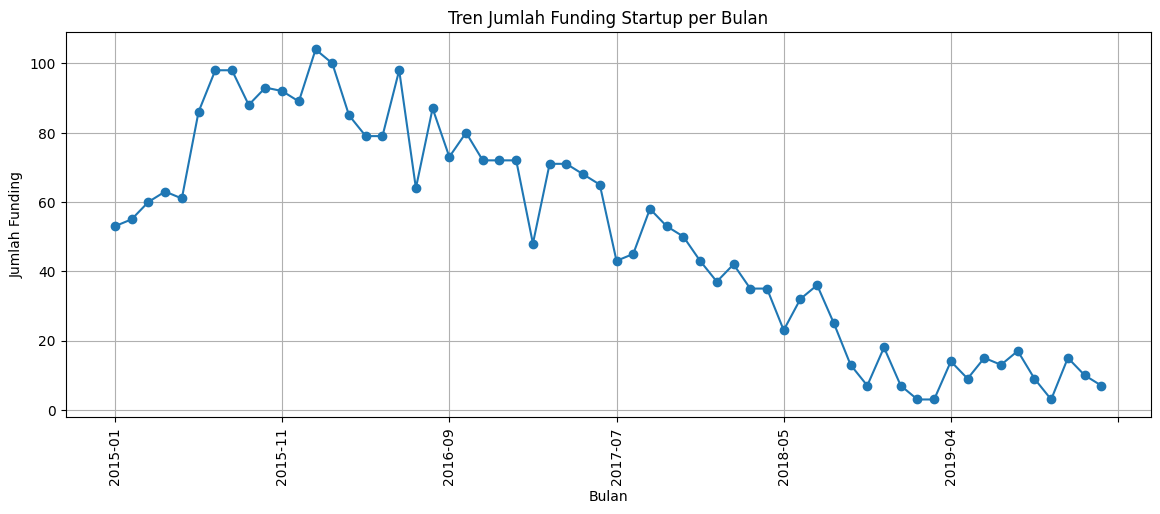

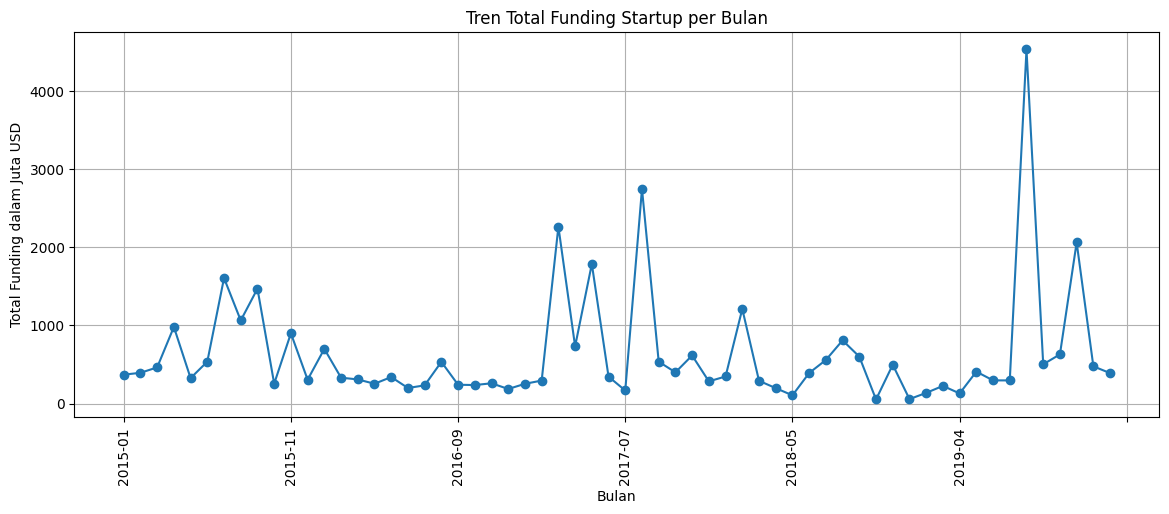


Insight Awal STEP 18:
1. Bulan dengan jumlah funding terbanyak adalah 2016-01 dengan 104 kali funding.
2. Bulan dengan total funding terbesar adalah 2019-08 dengan total sekitar 4,531.77 juta USD.
3. Grafik bulanan membantu melihat apakah ada lonjakan funding pada periode tertentu.


In [71]:
# STEP 18 Tren Funding per Bulan

# Membuat kolom year_month untuk analisis bulanan
df['year_month'] = df['date_clean'].dt.to_period('M').astype(str)

# Ringkasan funding per bulan berdasarkan urutan waktu
monthly_funding = df.groupby('year_month').agg(
    jumlah_funding=('startup_name', 'count'),
    jumlah_startup_unik=('startup_name', 'nunique'),
    total_funding_juta_usd=('amount_million_usd', 'sum'),
    rata_rata_funding_juta_usd=('amount_million_usd', 'mean'),
    median_funding_juta_usd=('amount_million_usd', 'median')
).sort_index()

print("STEP 18: Ringkasan Funding per Bulan")
display(monthly_funding.head(20))

print("\nData bulan terakhir:")
display(monthly_funding.tail(10))


# Visualisasi 1: Jumlah funding per bulan
plt.figure(figsize=(14, 5))
monthly_funding['jumlah_funding'].plot(kind='line', marker='o')

plt.title('Tren Jumlah Funding Startup per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Funding')
plt.xticks(rotation=90)
plt.grid(True)
plt.show()


# Visualisasi 2: Total funding per bulan
plt.figure(figsize=(14, 5))
monthly_funding['total_funding_juta_usd'].plot(kind='line', marker='o')

plt.title('Tren Total Funding Startup per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Total Funding dalam Juta USD')
plt.xticks(rotation=90)
plt.grid(True)
plt.show()


# Mencari bulan dengan jumlah funding tertinggi
top_month_count = monthly_funding['jumlah_funding'].idxmax()
top_month_count_value = monthly_funding.loc[top_month_count, 'jumlah_funding']

# Mencari bulan dengan total funding tertinggi
top_month_amount = monthly_funding['total_funding_juta_usd'].idxmax()
top_month_amount_value = monthly_funding.loc[top_month_amount, 'total_funding_juta_usd']

print("\nInsight Awal STEP 18:")
print(f"1. Bulan dengan jumlah funding terbanyak adalah {top_month_count} dengan {top_month_count_value} kali funding.")
print(f"2. Bulan dengan total funding terbesar adalah {top_month_amount} dengan total sekitar {top_month_amount_value:,.2f} juta USD.")
print("3. Grafik bulanan membantu melihat apakah ada lonjakan funding pada periode tertentu.")

STEP 19: Ringkasan Funding Berdasarkan Bulan Secara Umum


,jumlah_funding,jumlah_startup_unik,total_funding_juta_usd,rata_rata_funding_juta_usd,median_funding_juta_usd
month_name,,,,,
January,276,269,2197.867122,12.210373,2.000
February,248,246,2458.551823,14.462070,1.020
March,251,246,3329.122608,18.915469,1.200
April,262,250,2295.548095,12.969198,2.100
May,240,230,2967.549600,18.205826,1.000
June,296,290,1770.108710,8.806511,2.000
July,254,250,2862.930605,15.905170,2.275
August,272,265,9687.168811,51.803042,1.500
September,241,234,3352.273000,20.566092,1.500


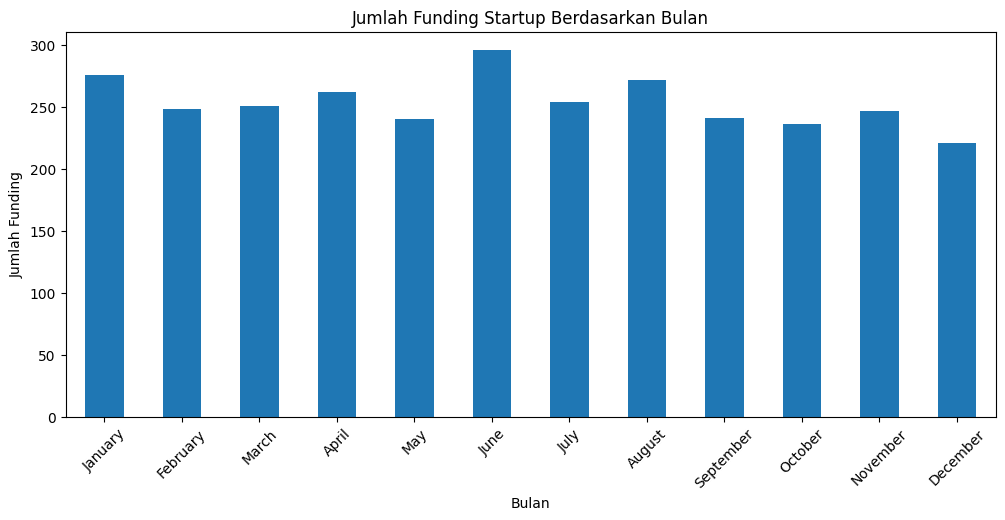

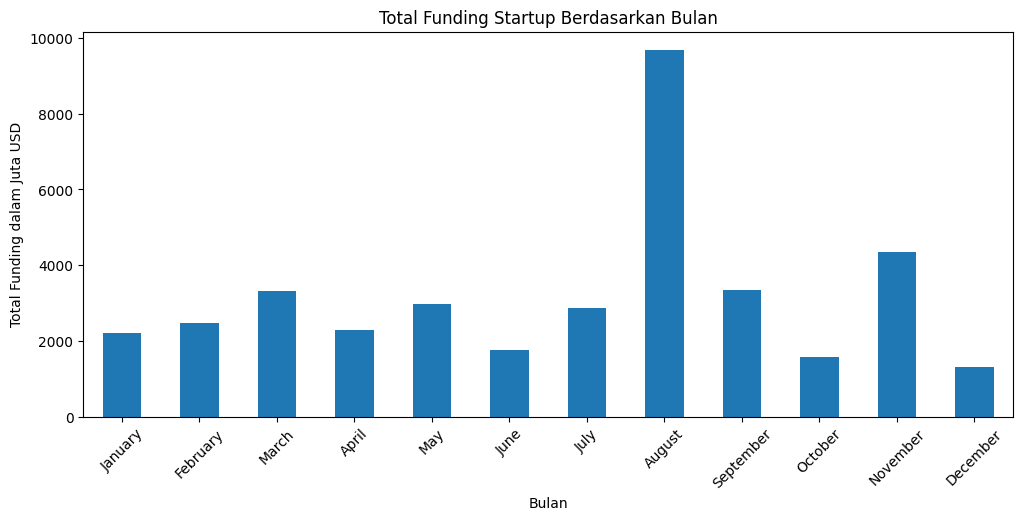


Insight Awal STEP 19:
1. Bulan dengan jumlah funding terbanyak secara umum adalah June dengan 296 kali funding.
2. Bulan dengan total funding terbesar secara umum adalah August dengan total sekitar 9,687.17 juta USD.
3. Bulan dengan median funding terbesar adalah July dengan median sekitar 2.27 juta USD.
4. Catatan: Hasil ini menggabungkan semua tahun, sehingga perlu dibaca sebagai pola umum, bukan tren waktu.


In [72]:
# STEP 19 Bulan Paling Aktif Secara Umum

# Urutan nama bulan agar tidak acak
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

# Membuat ringkasan funding berdasarkan nama bulan
monthly_general = df.groupby('month_name').agg(
    jumlah_funding=('startup_name', 'count'),
    jumlah_startup_unik=('startup_name', 'nunique'),
    total_funding_juta_usd=('amount_million_usd', 'sum'),
    rata_rata_funding_juta_usd=('amount_million_usd', 'mean'),
    median_funding_juta_usd=('amount_million_usd', 'median')
)

# Mengurutkan berdasarkan urutan bulan
monthly_general = monthly_general.reindex(month_order)

print("STEP 19: Ringkasan Funding Berdasarkan Bulan Secara Umum")
display(monthly_general)


# Visualisasi 1: Jumlah funding berdasarkan bulan
plt.figure(figsize=(12, 5))
monthly_general['jumlah_funding'].plot(kind='bar')

plt.title('Jumlah Funding Startup Berdasarkan Bulan')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Funding')
plt.xticks(rotation=45)
plt.show()


# Visualisasi 2: Total funding berdasarkan bulan
plt.figure(figsize=(12, 5))
monthly_general['total_funding_juta_usd'].plot(kind='bar')

plt.title('Total Funding Startup Berdasarkan Bulan')
plt.xlabel('Bulan')
plt.ylabel('Total Funding dalam Juta USD')
plt.xticks(rotation=45)
plt.show()


# Insight otomatis sederhana
top_month_by_count = monthly_general['jumlah_funding'].idxmax()
top_month_count = monthly_general.loc[top_month_by_count, 'jumlah_funding']

top_month_by_amount = monthly_general['total_funding_juta_usd'].idxmax()
top_month_amount = monthly_general.loc[top_month_by_amount, 'total_funding_juta_usd']

top_month_by_median = monthly_general['median_funding_juta_usd'].idxmax()
top_month_median = monthly_general.loc[top_month_by_median, 'median_funding_juta_usd']

print("\nInsight Awal STEP 19:")
print(f"1. Bulan dengan jumlah funding terbanyak secara umum adalah {top_month_by_count} dengan {top_month_count} kali funding.")
print(f"2. Bulan dengan total funding terbesar secara umum adalah {top_month_by_amount} dengan total sekitar {top_month_amount:,.2f} juta USD.")
print(f"3. Bulan dengan median funding terbesar adalah {top_month_by_median} dengan median sekitar {top_month_median:,.2f} juta USD.")
print("4. Catatan: Hasil ini menggabungkan semua tahun, sehingga perlu dibaca sebagai pola umum, bukan tren waktu.")

STEP 20: Top 15 Investor Paling Aktif


,count
investors,
Sequoia Capital,72
Accel Partners,68
Kalaari Capital,50
SAIF Partners,47
Blume Ventures,47
Indian Angel Network,41
Undisclosed investors,31
Ratan Tata,31
Nexus Venture Partners,30


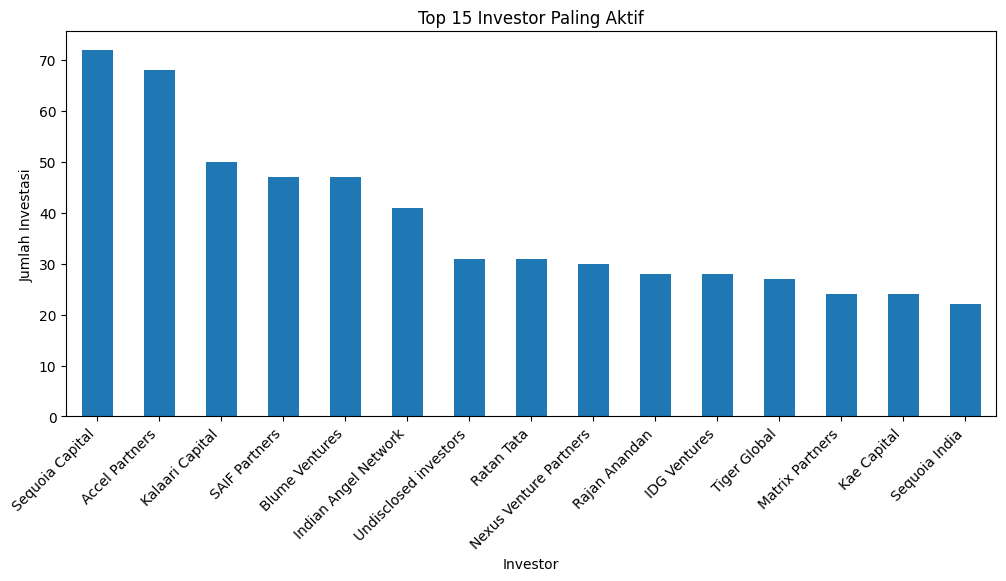


Insight Awal STEP 20:
1. Investor paling aktif adalah Sequoia Capital dengan 72 kemunculan investasi.
2. Investor paling aktif dihitung berdasarkan frekuensi kemunculan nama investor di dataset.
3. Karena satu funding bisa melibatkan lebih dari satu investor, analisis ini menggunakan hasil pemisahan nama investor berdasarkan koma.


In [73]:
# STEP 20 Analisis Investor Paling Aktif

# Mengambil kolom investors, menghapus missing value, lalu memisahkan berdasarkan koma
investor_series = df['investors'].dropna().str.split(',').explode()

# Membersihkan nama investor
investor_series = investor_series.apply(fix_text)
investor_series = investor_series.str.strip()

# Menghapus data kosong
investor_series = investor_series[investor_series.notnull()]
investor_series = investor_series[investor_series != '']

# Menghapus investor yang kurang informatif
invalid_investors = [
    'Undisclosed Investors',
    'Undisclosed Investor',
    'Undisclosed',
    'undisclosed investors',
    'undisclosed investor',
    'undisclosed'
]

investor_series = investor_series[~investor_series.isin(invalid_investors)]

# Menghitung investor paling aktif
top_investors = investor_series.value_counts().head(15)

print("STEP 20: Top 15 Investor Paling Aktif")
display(top_investors)


# Visualisasi top investor
plt.figure(figsize=(12, 5))
top_investors.plot(kind='bar')

plt.title('Top 15 Investor Paling Aktif')
plt.xlabel('Investor')
plt.ylabel('Jumlah Investasi')
plt.xticks(rotation=45, ha='right')
plt.show()


# Insight otomatis sederhana
top_investor_name = top_investors.index[0]
top_investor_count = top_investors.iloc[0]

print("\nInsight Awal STEP 20:")
print(f"1. Investor paling aktif adalah {top_investor_name} dengan {top_investor_count} kemunculan investasi.")
print("2. Investor paling aktif dihitung berdasarkan frekuensi kemunculan nama investor di dataset.")
print("3. Karena satu funding bisa melibatkan lebih dari satu investor, analisis ini menggunakan hasil pemisahan nama investor berdasarkan koma.")

STEP 20.5: Top 15 Investor Paling Aktif Setelah Cleaning


,count
investors,
Sequoia Capital,112
Accel Partners,74
Kalaari Capital,51
Tiger Global,48
Blume Ventures,47
SAIF Partners,47
IDG Ventures,46
Indian Angel Network,43
Ratan Tata,31


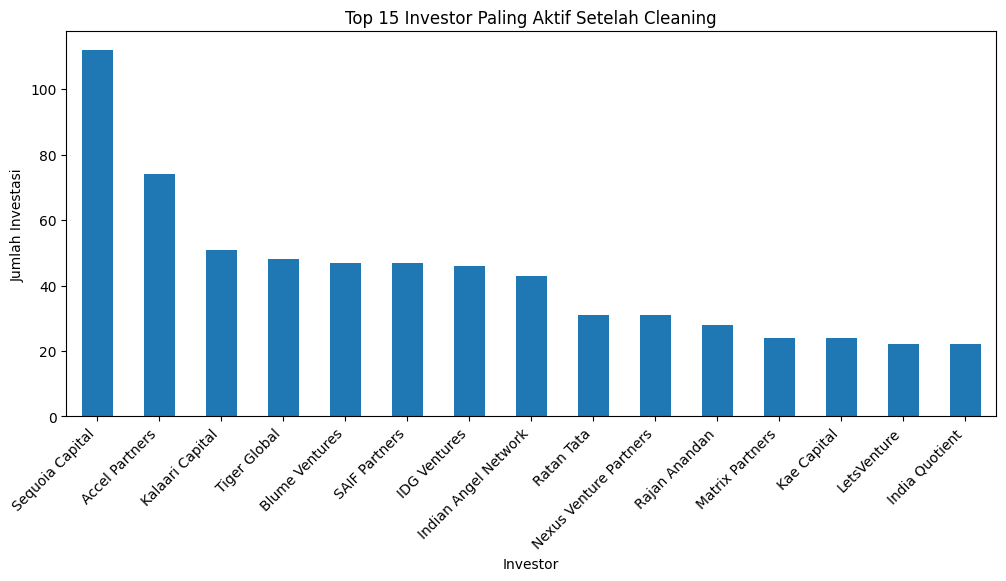


Insight Awal STEP 20.5:
1. Setelah cleaning, investor paling aktif adalah Sequoia Capital dengan 112 kemunculan investasi.
2. Data seperti 'Undisclosed investors' sudah dihapus karena tidak menunjukkan nama investor spesifik.
3. Beberapa variasi nama investor juga sudah digabung agar hasil analisis lebih akurat.


In [74]:
# STEP 20.5 Membersihkan Nama Investor

# Ambil kolom investors, lalu pisahkan jika ada lebih dari satu investor dalam satu baris
investor_series = df['investors'].dropna().str.split(',').explode()

# Bersihkan teks
investor_series = investor_series.apply(fix_text)
investor_series = investor_series.str.strip()

# Hapus data kosong
investor_series = investor_series[investor_series.notnull()]
investor_series = investor_series[investor_series != '']

# Buat versi lowercase untuk filtering
investor_series_lower = investor_series.str.lower()

# Hapus investor yang tidak informatif
invalid_keywords = [
    'undisclosed',
    'undisclosed investors',
    'undisclosed investor',
    'undisclosed angel investors',
    'group of angel investors',
    'angel investors',
    'investors'
]

investor_series = investor_series[
    ~investor_series_lower.isin(invalid_keywords)
]

# Standarisasi beberapa nama investor yang sama tapi penulisannya berbeda
def standardize_investor_name(name):
    if pd.isnull(name):
        return np.nan

    name = fix_text(name).strip()
    name_lower = name.lower()

    investor_mapping = {
        'sequoia india': 'Sequoia Capital',
        'sequoia capital india': 'Sequoia Capital',
        'sequoia capital india advisors': 'Sequoia Capital',
        'accel india': 'Accel Partners',
        'accel': 'Accel Partners',
        'saif partners india': 'SAIF Partners',
        'kalaari': 'Kalaari Capital',
        'kalaari capital partners': 'Kalaari Capital',
        'blume': 'Blume Ventures',
        'tiger global management': 'Tiger Global',
        'nexus ventures': 'Nexus Venture Partners',
        'indian angel network (ian)': 'Indian Angel Network',
        'idg ventures india': 'IDG Ventures'
    }

    return investor_mapping.get(name_lower, name)

investor_series_clean = investor_series.apply(standardize_investor_name)

# Hitung ulang top investor
top_investors_clean = investor_series_clean.value_counts().head(15)

print("STEP 20.5: Top 15 Investor Paling Aktif Setelah Cleaning")
display(top_investors_clean)

# Visualisasi ulang
plt.figure(figsize=(12, 5))
top_investors_clean.plot(kind='bar')

plt.title('Top 15 Investor Paling Aktif Setelah Cleaning')
plt.xlabel('Investor')
plt.ylabel('Jumlah Investasi')
plt.xticks(rotation=45, ha='right')
plt.show()

# Insight otomatis
top_investor_name = top_investors_clean.index[0]
top_investor_count = top_investors_clean.iloc[0]

print("\nInsight Awal STEP 20.5:")
print(f"1. Setelah cleaning, investor paling aktif adalah {top_investor_name} dengan {top_investor_count} kemunculan investasi.")
print("2. Data seperti 'Undisclosed investors' sudah dihapus karena tidak menunjukkan nama investor spesifik.")
print("3. Beberapa variasi nama investor juga sudah digabung agar hasil analisis lebih akurat.")

STEP 21: Top 15 Investor dengan Total Funding Terbesar


,jumlah_investasi,jumlah_startup_unik,total_funding_juta_usd,rata_rata_funding_juta_usd,median_funding_juta_usd
investor_name_clean,,,,,
Westbridge Capital,1,1,3900.00000,3900.000000,3900.00
Softbank,6,6,3545.00000,590.833333,172.50
Sequoia Capital,112,85,2997.06886,28.274235,12.65
Tiger Global,48,42,2836.80000,59.100000,20.00
SoftBank Group,6,6,2487.00000,414.500000,212.50
Tencent Holdings,3,3,1610.00000,536.666667,175.00
DST Global,4,4,1492.00000,373.000000,450.00
eBay,1,1,1400.00000,1400.000000,1400.00
Microsoft,1,1,1400.00000,1400.000000,1400.00


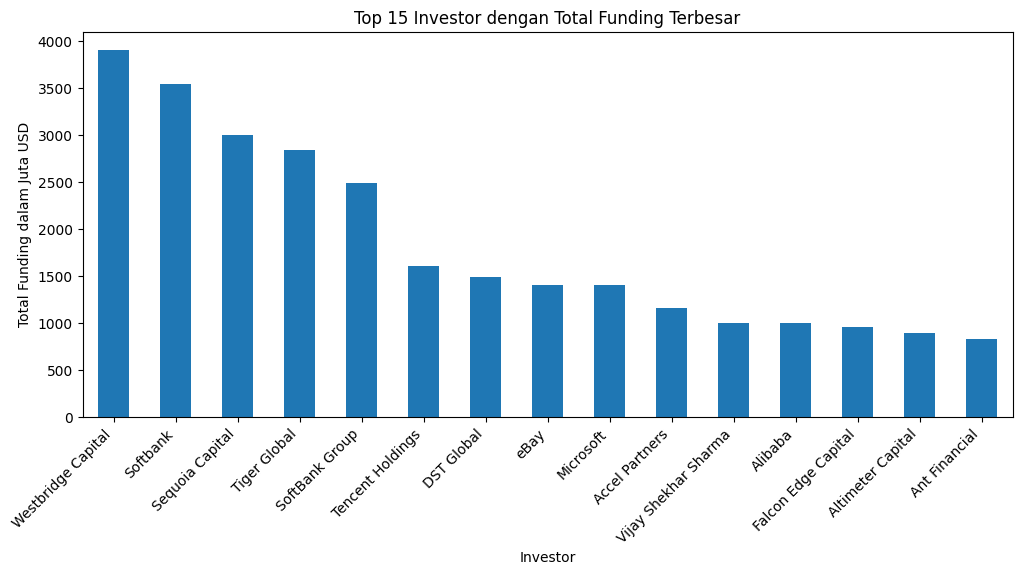

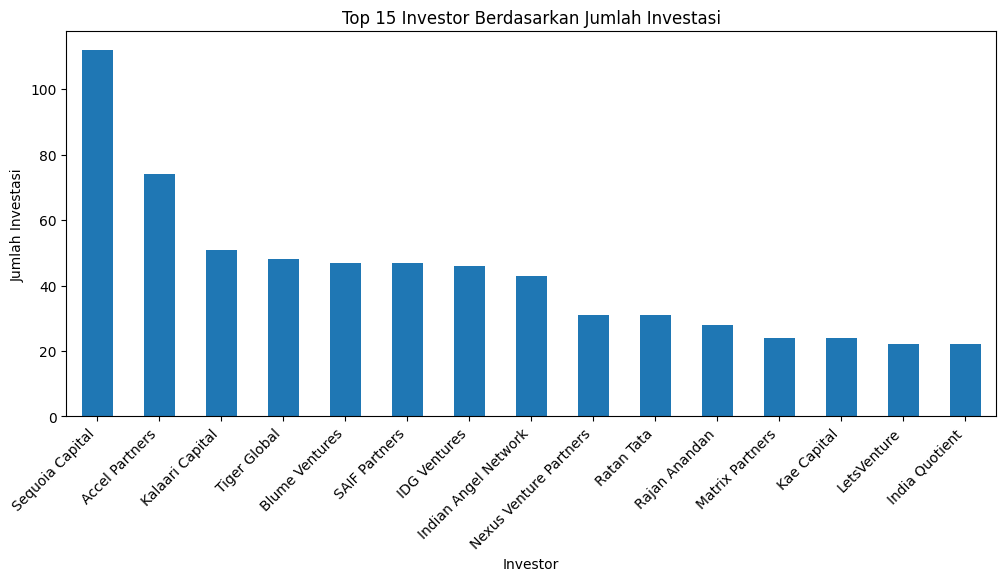


Insight Awal STEP 21:
1. Investor dengan total funding terbesar adalah Westbridge Capital dengan total sekitar 3,900.00 juta USD.
2. Investor dengan jumlah investasi terbanyak adalah Sequoia Capital dengan 112.0 kemunculan investasi.
3. Jika investor dengan total funding terbesar berbeda dari investor paling aktif, berarti investor tersebut lebih sering terlibat dalam deal bernilai besar.
4. Catatan: Total funding dihitung berdasarkan nilai deal yang melibatkan investor tersebut, bukan kontribusi individual investor.


In [75]:
# STEP 21 Investor dengan Total Funding Terbesar

# Membuat dataframe khusus investor
investor_df = df[['startup_name', 'investors', 'amount_million_usd']].copy()

# Menghapus baris yang investor-nya kosong
investor_df = investor_df.dropna(subset=['investors'])

# Memisahkan investor yang ada dalam satu baris
investor_df['investor_name'] = investor_df['investors'].str.split(',')

# Explode agar satu investor menjadi satu baris
investor_df = investor_df.explode('investor_name')

# Membersihkan nama investor
investor_df['investor_name'] = investor_df['investor_name'].apply(fix_text)
investor_df['investor_name'] = investor_df['investor_name'].str.strip()

# Menghapus investor kosong
investor_df = investor_df[
    investor_df['investor_name'].notnull() &
    (investor_df['investor_name'] != '')
]

# Menghapus investor yang tidak informatif
investor_df['investor_name_lower'] = investor_df['investor_name'].str.lower()

invalid_keywords = [
    'undisclosed',
    'undisclosed investors',
    'undisclosed investor',
    'undisclosed angel investors',
    'group of angel investors',
    'angel investors',
    'investors'
]

investor_df = investor_df[
    ~investor_df['investor_name_lower'].isin(invalid_keywords)
]

# Standarisasi nama investor
investor_df['investor_name_clean'] = investor_df['investor_name'].apply(standardize_investor_name)

# Membuat ringkasan investor berdasarkan total funding
investor_funding = investor_df.groupby('investor_name_clean').agg(
    jumlah_investasi=('startup_name', 'count'),
    jumlah_startup_unik=('startup_name', 'nunique'),
    total_funding_juta_usd=('amount_million_usd', 'sum'),
    rata_rata_funding_juta_usd=('amount_million_usd', 'mean'),
    median_funding_juta_usd=('amount_million_usd', 'median')
).sort_values(by='total_funding_juta_usd', ascending=False)

print("STEP 21: Top 15 Investor dengan Total Funding Terbesar")
display(investor_funding.head(15))


# Visualisasi Top 15 investor berdasarkan total funding
top_investor_funding = investor_funding['total_funding_juta_usd'].head(15)

plt.figure(figsize=(12, 5))
top_investor_funding.plot(kind='bar')

plt.title('Top 15 Investor dengan Total Funding Terbesar')
plt.xlabel('Investor')
plt.ylabel('Total Funding dalam Juta USD')
plt.xticks(rotation=45, ha='right')
plt.show()


# Visualisasi Top 15 investor berdasarkan jumlah investasi
top_investor_count = investor_funding.sort_values(
    by='jumlah_investasi',
    ascending=False
)['jumlah_investasi'].head(15)

plt.figure(figsize=(12, 5))
top_investor_count.plot(kind='bar')

plt.title('Top 15 Investor Berdasarkan Jumlah Investasi')
plt.xlabel('Investor')
plt.ylabel('Jumlah Investasi')
plt.xticks(rotation=45, ha='right')
plt.show()


# Insight otomatis sederhana
top_investor_by_amount = investor_funding.index[0]
top_investor_amount = investor_funding.iloc[0]['total_funding_juta_usd']

investor_funding_by_count = investor_funding.sort_values(by='jumlah_investasi', ascending=False)
top_investor_by_count = investor_funding_by_count.index[0]
top_investor_count_value = investor_funding_by_count.iloc[0]['jumlah_investasi']

print("\nInsight Awal STEP 21:")
print(f"1. Investor dengan total funding terbesar adalah {top_investor_by_amount} dengan total sekitar {top_investor_amount:,.2f} juta USD.")
print(f"2. Investor dengan jumlah investasi terbanyak adalah {top_investor_by_count} dengan {top_investor_count_value} kemunculan investasi.")
print("3. Jika investor dengan total funding terbesar berbeda dari investor paling aktif, berarti investor tersebut lebih sering terlibat dalam deal bernilai besar.")
print("4. Catatan: Total funding dihitung berdasarkan nilai deal yang melibatkan investor tersebut, bukan kontribusi individual investor.")

STEP 21.5: Top 15 Investor dengan Total Funding Terbesar Setelah Cleaning Tambahan


,jumlah_investasi,jumlah_startup_unik,total_funding_juta_usd,rata_rata_funding_juta_usd,median_funding_juta_usd
investor_name_clean,,,,,
SoftBank,20,15,7075.00000,353.750000,147.50
WestBridge Capital,3,3,3992.00000,1330.666667,52.00
Sequoia Capital,112,85,2997.06886,28.274235,12.65
Tiger Global,48,42,2836.80000,59.100000,20.00
Tencent Holdings,3,3,1610.00000,536.666667,175.00
DST Global,4,4,1492.00000,373.000000,450.00
eBay,1,1,1400.00000,1400.000000,1400.00
Microsoft,1,1,1400.00000,1400.000000,1400.00
Accel Partners,74,63,1165.68000,17.933538,8.00


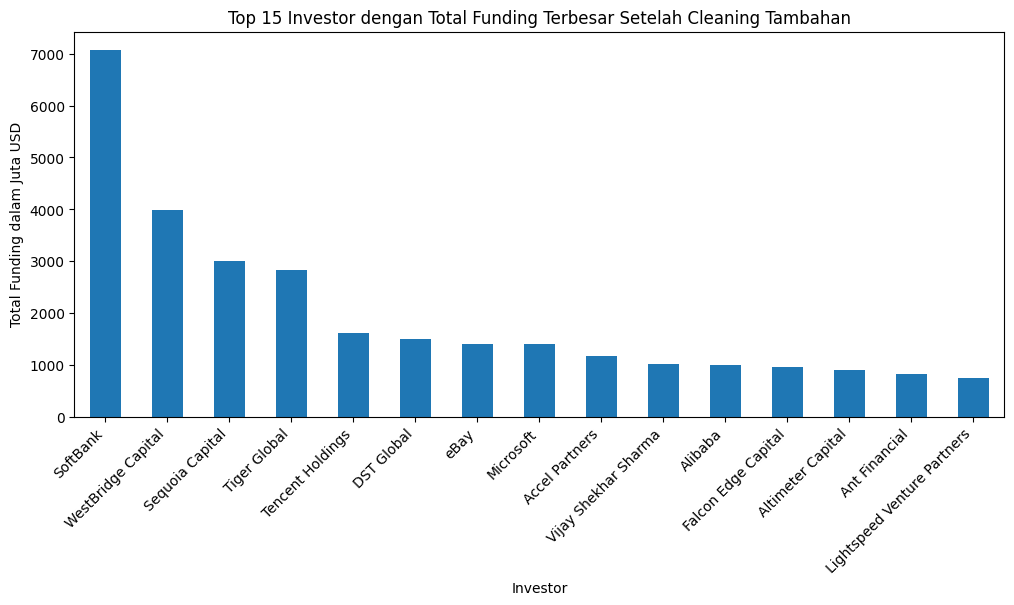

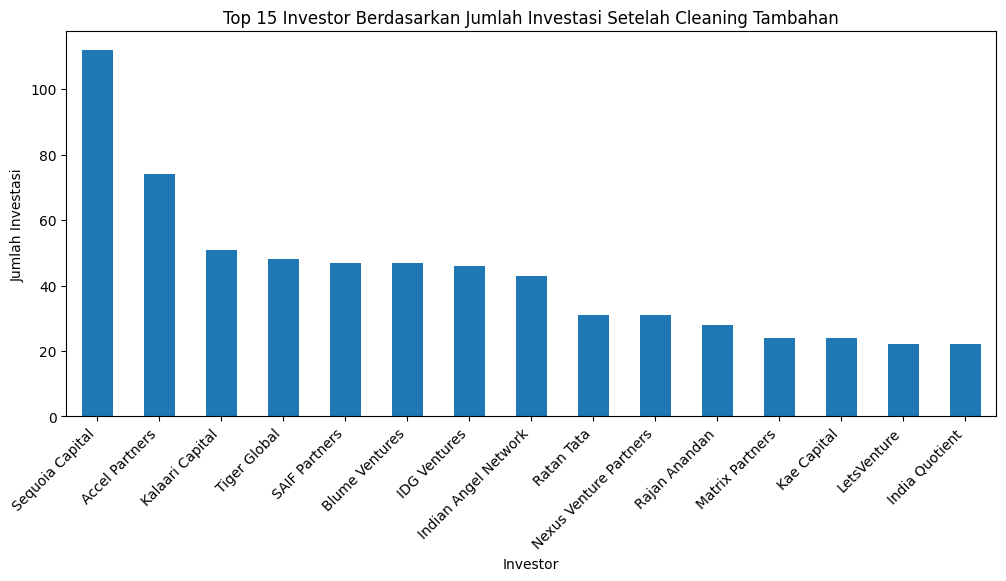


Insight Awal STEP 21.5:
1. Investor dengan total funding terbesar setelah cleaning tambahan adalah SoftBank.
2. Total funding investor tersebut sekitar 7,075.00 juta USD.
3. Softbank dan SoftBank Group sudah digabung menjadi SoftBank.
4. Catatan: Total funding tetap dihitung berdasarkan nilai deal yang melibatkan investor tersebut, bukan kontribusi individual investor.


In [76]:
# STEP 21.5 Rapikan Ulang Nama Investor SoftBank

def standardize_investor_name_v2(name):
    if pd.isnull(name):
        return np.nan

    name = fix_text(name).strip()
    name_lower = name.lower()

    investor_mapping = {
        'sequoia india': 'Sequoia Capital',
        'sequoia capital india': 'Sequoia Capital',
        'sequoia capital india advisors': 'Sequoia Capital',

        'accel india': 'Accel Partners',
        'accel': 'Accel Partners',

        'saif partners india': 'SAIF Partners',

        'kalaari': 'Kalaari Capital',
        'kalaari capital partners': 'Kalaari Capital',

        'blume': 'Blume Ventures',

        'tiger global management': 'Tiger Global',

        'nexus ventures': 'Nexus Venture Partners',

        'indian angel network (ian)': 'Indian Angel Network',

        'idg ventures india': 'IDG Ventures',

        # Tambahan cleaning SoftBank
        'softbank': 'SoftBank',
        'softbank group': 'SoftBank',
        'softbank vision fund': 'SoftBank',
        'softbank corp': 'SoftBank',

        # Tambahan cleaning WestBridge
        'westbridge capital': 'WestBridge Capital',
        'westbridge': 'WestBridge Capital'
    }

    return investor_mapping.get(name_lower, name)


# Membuat ulang dataframe investor
investor_df = df[['startup_name', 'investors', 'amount_million_usd']].copy()

investor_df = investor_df.dropna(subset=['investors'])

investor_df['investor_name'] = investor_df['investors'].str.split(',')
investor_df = investor_df.explode('investor_name')

investor_df['investor_name'] = investor_df['investor_name'].apply(fix_text)
investor_df['investor_name'] = investor_df['investor_name'].str.strip()

investor_df = investor_df[
    investor_df['investor_name'].notnull() &
    (investor_df['investor_name'] != '')
]

# Filtering investor tidak informatif
investor_df['investor_name_lower'] = investor_df['investor_name'].str.lower()

invalid_keywords = [
    'undisclosed',
    'undisclosed investors',
    'undisclosed investor',
    'undisclosed angel investors',
    'group of angel investors',
    'angel investors',
    'investors'
]

investor_df = investor_df[
    ~investor_df['investor_name_lower'].isin(invalid_keywords)
]

# Standarisasi nama investor versi terbaru
investor_df['investor_name_clean'] = investor_df['investor_name'].apply(standardize_investor_name_v2)

# Ringkasan ulang investor
investor_funding_clean = investor_df.groupby('investor_name_clean').agg(
    jumlah_investasi=('startup_name', 'count'),
    jumlah_startup_unik=('startup_name', 'nunique'),
    total_funding_juta_usd=('amount_million_usd', 'sum'),
    rata_rata_funding_juta_usd=('amount_million_usd', 'mean'),
    median_funding_juta_usd=('amount_million_usd', 'median')
).sort_values(by='total_funding_juta_usd', ascending=False)

print("STEP 21.5: Top 15 Investor dengan Total Funding Terbesar Setelah Cleaning Tambahan")
display(investor_funding_clean.head(15))


# Visualisasi total funding investor setelah cleaning tambahan
plt.figure(figsize=(12, 5))
investor_funding_clean['total_funding_juta_usd'].head(15).plot(kind='bar')

plt.title('Top 15 Investor dengan Total Funding Terbesar Setelah Cleaning Tambahan')
plt.xlabel('Investor')
plt.ylabel('Total Funding dalam Juta USD')
plt.xticks(rotation=45, ha='right')
plt.show()


# Visualisasi jumlah investasi investor setelah cleaning tambahan
investor_count_clean = investor_funding_clean.sort_values(
    by='jumlah_investasi',
    ascending=False
)['jumlah_investasi'].head(15)

plt.figure(figsize=(12, 5))
investor_count_clean.plot(kind='bar')

plt.title('Top 15 Investor Berdasarkan Jumlah Investasi Setelah Cleaning Tambahan')
plt.xlabel('Investor')
plt.ylabel('Jumlah Investasi')
plt.xticks(rotation=45, ha='right')
plt.show()


print("\nInsight Awal STEP 21.5:")
print(f"1. Investor dengan total funding terbesar setelah cleaning tambahan adalah {investor_funding_clean.index[0]}.")
print(f"2. Total funding investor tersebut sekitar {investor_funding_clean.iloc[0]['total_funding_juta_usd']:,.2f} juta USD.")
print("3. Softbank dan SoftBank Group sudah digabung menjadi SoftBank.")
print("4. Catatan: Total funding tetap dihitung berdasarkan nilai deal yang melibatkan investor tersebut, bukan kontribusi individual investor.")

STEP 22: Startup yang Mendapat Funding Berulang


,jumlah_funding,total_funding_juta_usd,rata_rata_funding_juta_usd,median_funding_juta_usd,funding_pertama,funding_terakhir
startup_name_clean,,,,,,
Ola,12,1654.20000,150.381818,104.50000,2015-07-01,2019-07-03
OYO Rooms,9,997.00000,110.777778,100.00000,2015-03-25,2018-02-14
Paytm,8,3348.95000,558.158333,440.00000,2015-02-05,2019-11-25
Swiggy,8,270.50000,33.812500,15.75000,2015-04-03,2018-02-07
Meesho,6,189.60000,47.400000,30.75000,2016-05-06,2019-08-12
Nykaa,6,214.00000,42.800000,12.30000,2015-10-05,2018-09-05
Medinfi,6,0.78000,0.156000,0.12500,2015-11-20,2017-08-25
NoBroker,6,71.40000,17.850000,8.70000,2015-02-23,2019-06-05
Flipkart,6,4759.70000,793.283333,385.50000,2015-06-04,2017-08-11


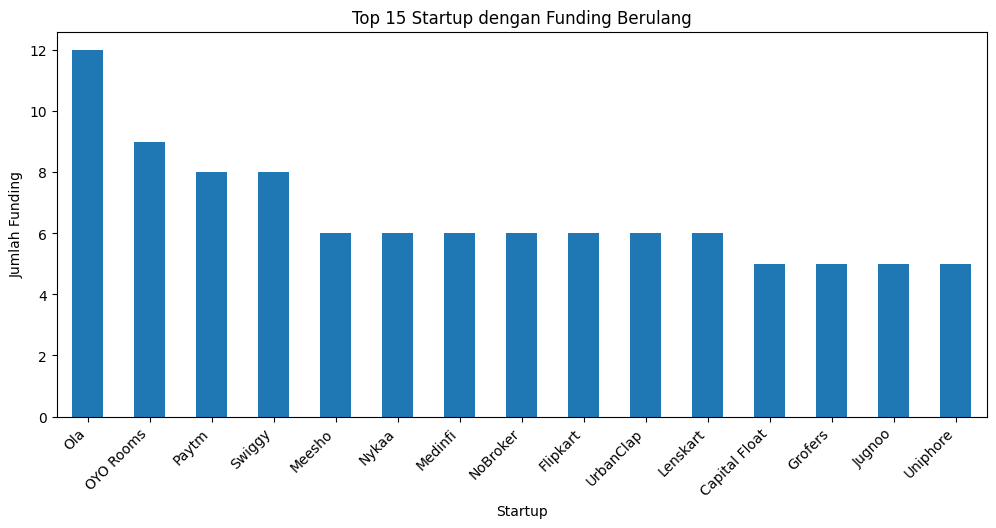

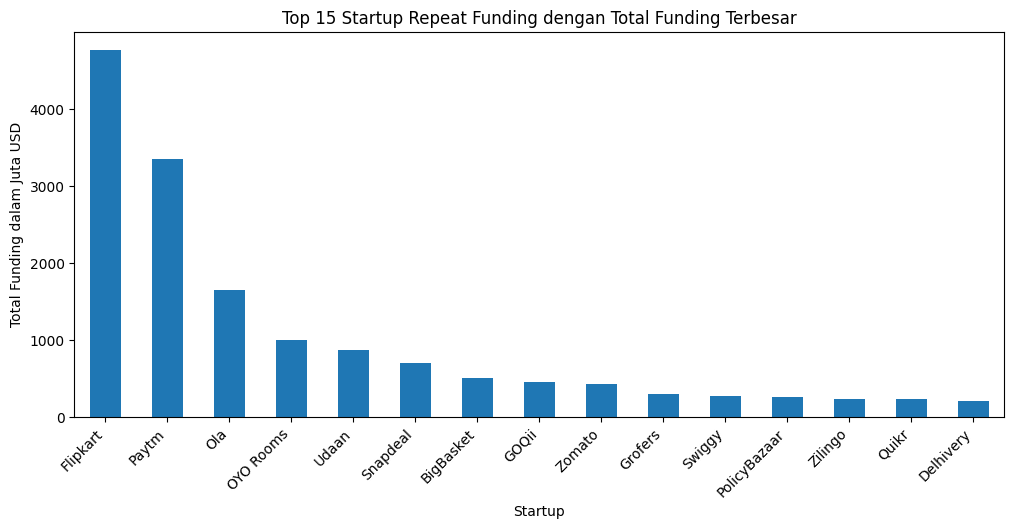


Insight Awal STEP 22:
1. Jumlah startup yang mendapatkan funding lebih dari satu kali adalah 389 startup.
2. Startup dengan jumlah funding terbanyak adalah Ola dengan 12 kali funding.
3. Startup repeat funding dengan total funding terbesar adalah Flipkart dengan total sekitar 4,759.70 juta USD.
4. Startup yang mendapat funding berulang dapat dianggap memiliki daya tarik lebih tinggi bagi investor karena mampu memperoleh pendanaan dalam beberapa putaran.


In [77]:
# STEP 22 Startup dengan Funding Berulang

def standardize_startup_name(name):
    if pd.isnull(name):
        return np.nan

    name = fix_text(name).strip()

    # Menyamakan apostrof
    name = name.replace('’', "'")
    name = name.replace('‘', "'")

    # Menghapus spasi berlebih
    name = re.sub(r'\s+', ' ', name)

    # Standarisasi beberapa nama startup yang umum muncul dengan variasi
    name_lower = name.lower()

    startup_mapping = {
        'flipkart.com': 'Flipkart',
        'flipkart': 'Flipkart',

        'paytm': 'Paytm',
        'paytm marketplace': 'Paytm',

        'ola': 'Ola',
        'ola cabs': 'Ola',

        'oyo': 'OYO Rooms',
        'oyo rooms': 'OYO Rooms',
        'oyorooms': 'OYO Rooms',

        'zomato': 'Zomato',
        'swiggy': 'Swiggy',
        'bigbasket': 'BigBasket',
        'big basket': 'BigBasket',

        "byju's": "BYJU'S",
        'byjus': "BYJU'S",
        'byju’s': "BYJU'S",

        'urbanclap': 'UrbanClap',
        'urban clap': 'UrbanClap',

        'delhivery': 'Delhivery',
        'grofers': 'Grofers',
        'lenskart': 'Lenskart',
        'practo': 'Practo',
        'freshmenu': 'FreshMenu',
        'foodpanda': 'Foodpanda'
    }

    return startup_mapping.get(name_lower, name)


# Membuat kolom startup_name_clean
df['startup_name_clean'] = df['startup_name'].apply(standardize_startup_name)

# Menghitung jumlah funding per startup
startup_repeat_summary = df.groupby('startup_name_clean').agg(
    jumlah_funding=('startup_name_clean', 'count'),
    total_funding_juta_usd=('amount_million_usd', 'sum'),
    rata_rata_funding_juta_usd=('amount_million_usd', 'mean'),
    median_funding_juta_usd=('amount_million_usd', 'median'),
    funding_pertama=('date_clean', 'min'),
    funding_terakhir=('date_clean', 'max')
).sort_values(by='jumlah_funding', ascending=False)

# Filter hanya startup yang mendapat funding lebih dari satu kali
repeat_startups = startup_repeat_summary[startup_repeat_summary['jumlah_funding'] > 1]

print("STEP 22: Startup yang Mendapat Funding Berulang")
display(repeat_startups.head(20))


# Visualisasi top startup berdasarkan jumlah funding
top_repeat_startups = repeat_startups['jumlah_funding'].head(15)

plt.figure(figsize=(12, 5))
top_repeat_startups.plot(kind='bar')

plt.title('Top 15 Startup dengan Funding Berulang')
plt.xlabel('Startup')
plt.ylabel('Jumlah Funding')
plt.xticks(rotation=45, ha='right')
plt.show()


# Visualisasi top startup repeat berdasarkan total funding
top_repeat_startups_amount = repeat_startups.sort_values(
    by='total_funding_juta_usd',
    ascending=False
)['total_funding_juta_usd'].head(15)

plt.figure(figsize=(12, 5))
top_repeat_startups_amount.plot(kind='bar')

plt.title('Top 15 Startup Repeat Funding dengan Total Funding Terbesar')
plt.xlabel('Startup')
plt.ylabel('Total Funding dalam Juta USD')
plt.xticks(rotation=45, ha='right')
plt.show()


# Insight otomatis sederhana
top_startup_by_count = repeat_startups.index[0]
top_startup_count = repeat_startups.iloc[0]['jumlah_funding']

repeat_startups_by_amount = repeat_startups.sort_values(
    by='total_funding_juta_usd',
    ascending=False
)

top_startup_by_amount = repeat_startups_by_amount.index[0]
top_startup_amount = repeat_startups_by_amount.iloc[0]['total_funding_juta_usd']

total_repeat_startups = repeat_startups.shape[0]

print("\nInsight Awal STEP 22:")
print(f"1. Jumlah startup yang mendapatkan funding lebih dari satu kali adalah {total_repeat_startups} startup.")
print(f"2. Startup dengan jumlah funding terbanyak adalah {top_startup_by_count} dengan {top_startup_count} kali funding.")
print(f"3. Startup repeat funding dengan total funding terbesar adalah {top_startup_by_amount} dengan total sekitar {top_startup_amount:,.2f} juta USD.")
print("4. Startup yang mendapat funding berulang dapat dianggap memiliki daya tarik lebih tinggi bagi investor karena mampu memperoleh pendanaan dalam beberapa putaran.")

STEP 22.5: Startup yang Mendapat Funding Berulang Setelah Cleaning Tambahan


,jumlah_funding,total_funding_juta_usd,rata_rata_funding_juta_usd,median_funding_juta_usd,funding_pertama,funding_terakhir
startup_name_clean,,,,,,
Ola,13,2054.20000,171.183333,107.25000,2015-04-08,2019-07-03
OYO Rooms,9,997.00000,110.777778,100.00000,2015-03-25,2018-02-14
Swiggy,8,270.50000,33.812500,15.75000,2015-04-03,2018-02-07
Paytm,8,3348.95000,558.158333,440.00000,2015-02-05,2019-11-25
BYJU'S,7,525.00000,87.500000,62.50000,2016-03-22,2020-01-09
Nykaa,6,214.00000,42.800000,12.30000,2015-10-05,2018-09-05
UrbanClap,6,60.70000,12.140000,10.00000,2015-04-16,2017-06-30
Medinfi,6,0.78000,0.156000,0.12500,2015-11-20,2017-08-25
Meesho,6,189.60000,47.400000,30.75000,2016-05-06,2019-08-12


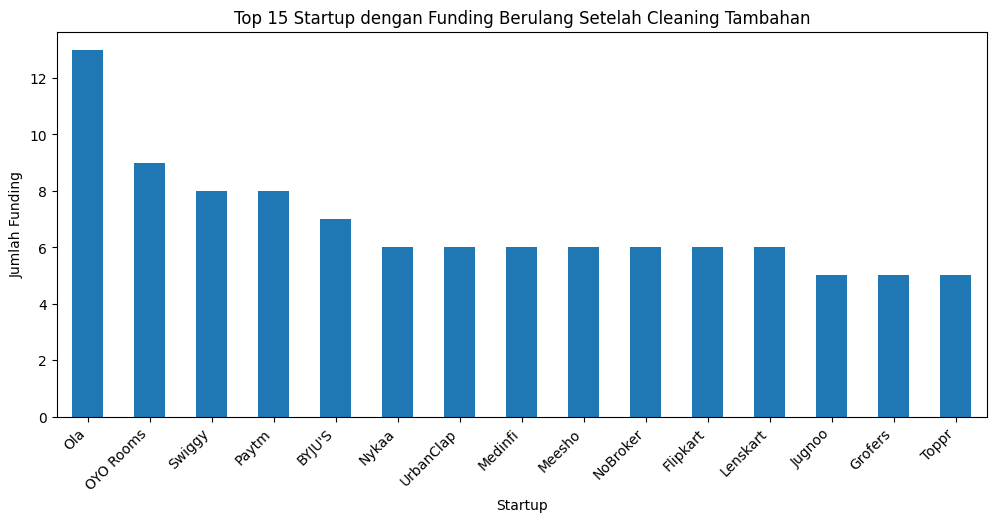

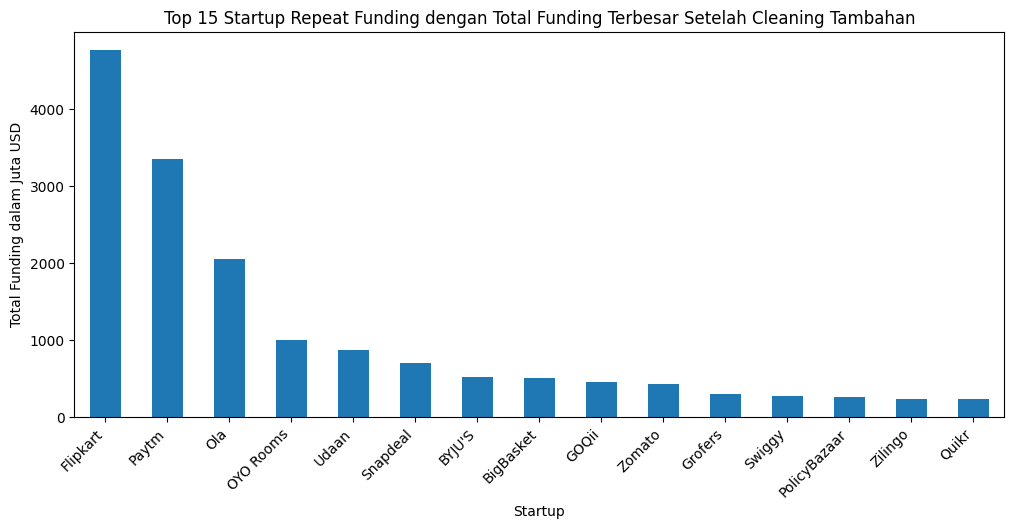


Insight Awal STEP 22.5:
1. Jumlah startup yang mendapatkan funding lebih dari satu kali adalah 391 startup.
2. Startup dengan jumlah funding terbanyak adalah Ola dengan 13 kali funding.
3. Startup repeat funding dengan total funding terbesar adalah Flipkart dengan total sekitar 4,759.70 juta USD.
4. Nama startup seperti BYJU'S sudah dibersihkan agar tidak muncul dalam bentuk karakter aneh.


In [78]:
# STEP 22.5 Rapikan Ulang Nama Startup

def standardize_startup_name_v2(name):
    if pd.isnull(name):
        return np.nan

    name = fix_text(name).strip()

    # Membersihkan karakter aneh
    name = name.replace('\\', '')
    name = name.replace('’', "'")
    name = name.replace('‘', "'")
    name = name.replace('`', "'")

    # Merapikan spasi
    name = re.sub(r'\s+', ' ', name).strip()

    # Membuat versi normalized untuk mapping
    name_normalized = name.lower()
    name_normalized = re.sub(r'[^a-z0-9]', '', name_normalized)

    startup_mapping = {
        'flipkartcom': 'Flipkart',
        'flipkart': 'Flipkart',

        'paytm': 'Paytm',
        'paytmmarketplace': 'Paytm',

        'ola': 'Ola',
        'olacabs': 'Ola',

        'oyo': 'OYO Rooms',
        'oyorooms': 'OYO Rooms',

        'zomato': 'Zomato',
        'swiggy': 'Swiggy',

        'bigbasket': 'BigBasket',
        'bigbasketcom': 'BigBasket',

        'byjus': "BYJU'S",
        'byju': "BYJU'S",
        'byjusapp': "BYJU'S",

        'urbanclap': 'UrbanClap',
        'urbanclaptechnologies': 'UrbanClap',

        'delhivery': 'Delhivery',
        'grofers': 'Grofers',
        'lenskart': 'Lenskart',
        'practo': 'Practo',
        'freshmenu': 'FreshMenu',
        'foodpanda': 'Foodpanda',
        'nykaa': 'Nykaa',
        'meesho': 'Meesho',
        'nobroker': 'NoBroker',
        'medinfi': 'Medinfi',
        'uniphore': 'Uniphore',
        'capitalfloat': 'Capital Float',
        'jugnoo': 'Jugnoo',
        'toppr': 'Toppr',
        'moglix': 'Moglix',
        'furlenco': 'Furlenco'
    }

    return startup_mapping.get(name_normalized, name)


# Membuat ulang kolom startup_name_clean
df['startup_name_clean'] = df['startup_name'].apply(standardize_startup_name_v2)

# Menghitung ulang startup repeat funding
startup_repeat_summary = df.groupby('startup_name_clean').agg(
    jumlah_funding=('startup_name_clean', 'count'),
    total_funding_juta_usd=('amount_million_usd', 'sum'),
    rata_rata_funding_juta_usd=('amount_million_usd', 'mean'),
    median_funding_juta_usd=('amount_million_usd', 'median'),
    funding_pertama=('date_clean', 'min'),
    funding_terakhir=('date_clean', 'max')
).sort_values(by='jumlah_funding', ascending=False)

repeat_startups = startup_repeat_summary[startup_repeat_summary['jumlah_funding'] > 1]

print("STEP 22.5: Startup yang Mendapat Funding Berulang Setelah Cleaning Tambahan")
display(repeat_startups.head(20))


# Visualisasi top startup berdasarkan jumlah funding
top_repeat_startups = repeat_startups['jumlah_funding'].head(15)

plt.figure(figsize=(12, 5))
top_repeat_startups.plot(kind='bar')

plt.title('Top 15 Startup dengan Funding Berulang Setelah Cleaning Tambahan')
plt.xlabel('Startup')
plt.ylabel('Jumlah Funding')
plt.xticks(rotation=45, ha='right')
plt.show()


# Visualisasi top startup repeat berdasarkan total funding
top_repeat_startups_amount = repeat_startups.sort_values(
    by='total_funding_juta_usd',
    ascending=False
)['total_funding_juta_usd'].head(15)

plt.figure(figsize=(12, 5))
top_repeat_startups_amount.plot(kind='bar')

plt.title('Top 15 Startup Repeat Funding dengan Total Funding Terbesar Setelah Cleaning Tambahan')
plt.xlabel('Startup')
plt.ylabel('Total Funding dalam Juta USD')
plt.xticks(rotation=45, ha='right')
plt.show()


# Insight otomatis sederhana
top_startup_by_count = repeat_startups.index[0]
top_startup_count = repeat_startups.iloc[0]['jumlah_funding']

repeat_startups_by_amount = repeat_startups.sort_values(
    by='total_funding_juta_usd',
    ascending=False
)

top_startup_by_amount = repeat_startups_by_amount.index[0]
top_startup_amount = repeat_startups_by_amount.iloc[0]['total_funding_juta_usd']

total_repeat_startups = repeat_startups.shape[0]

print("\nInsight Awal STEP 22.5:")
print(f"1. Jumlah startup yang mendapatkan funding lebih dari satu kali adalah {total_repeat_startups} startup.")
print(f"2. Startup dengan jumlah funding terbanyak adalah {top_startup_by_count} dengan {top_startup_count} kali funding.")
print(f"3. Startup repeat funding dengan total funding terbesar adalah {top_startup_by_amount} dengan total sekitar {top_startup_amount:,.2f} juta USD.")
print("4. Nama startup seperti BYJU'S sudah dibersihkan agar tidak muncul dalam bentuk karakter aneh.")

STEP 23: Detail Riwayat Funding Startup Teratas


,date_clean,startup_name_clean,city_clean,industry_group,investment_type_clean,investors,amount_million_usd
1880,2016-03-22,BYJU'S,Bengaluru,EdTech/Education,Private Equity,"Sequoia India, Sofina",75.00
1356,2016-09-09,BYJU'S,Bengaluru,EdTech/Education,Private Equity,"Chan Zuckerberg Initiative, Times Internet Ltd...",50.00
1164,2016-12-20,BYJU'S,Bengaluru,EdTech/Education,Private Equity,International Financial Corporation,15.00
983,2017-03-29,BYJU'S,Bengaluru,EdTech/Education,Private Equity,Verlinvest,NaN
712,2017-07-25,BYJU'S,Bengaluru,EdTech/Education,Private Equity,Tencent Holdings,35.00
67,2019-07-10,BYJU'S,Bengaluru,EdTech/Education,Private Equity,Qatar Investment Authority,150.00
0,2020-01-09,BYJU'S,Bengaluru,EdTech/Education,Private Equity,Tiger Global Management,200.00
2689,2015-06-04,Flipkart,Bengaluru,E-commerce,Private Equity,Morgan Stanley,50.00
2648,2015-07-28,Flipkart,Bengaluru,E-commerce,Private Equity,Steadview Capital and existing investors,700.00
1032,2017-02-20,Flipkart,Bengaluru,E-commerce,Private Equity,"Bennett, Coleman and Co. Ltd (BCCL)",38.70



Ringkasan Riwayat Funding Startup Teratas


,jumlah_funding,total_funding_juta_usd,rata_rata_funding_juta_usd,median_funding_juta_usd,funding_terbesar_juta_usd,funding_pertama,funding_terakhir
startup_name_clean,,,,,,,
Flipkart,6,4759.70,793.283333,385.50,2500.0,2015-06-04,2017-08-11
Paytm,8,3348.95,558.158333,440.00,1400.0,2015-02-05,2019-11-25
Ola,13,2054.20,171.183333,107.25,500.0,2015-04-08,2019-07-03
OYO Rooms,9,997.00,110.777778,100.00,250.0,2015-03-25,2018-02-14
BYJU'S,7,525.00,87.500000,62.50,200.0,2016-03-22,2020-01-09


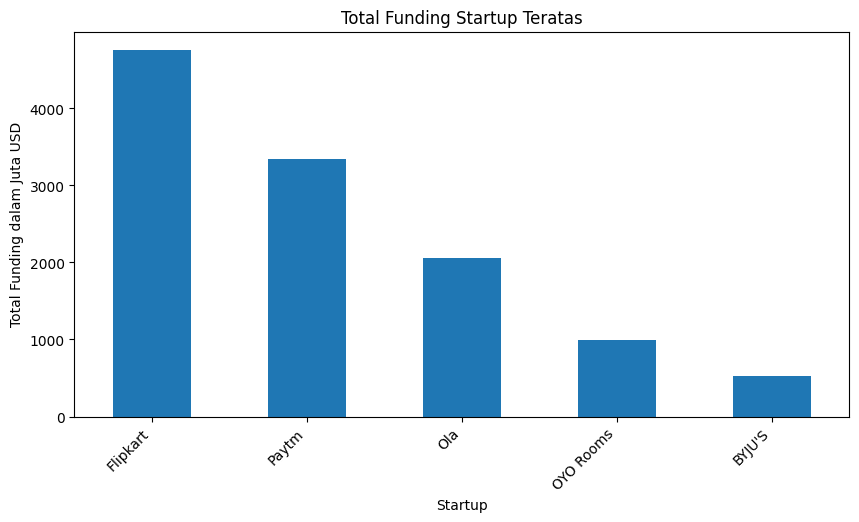

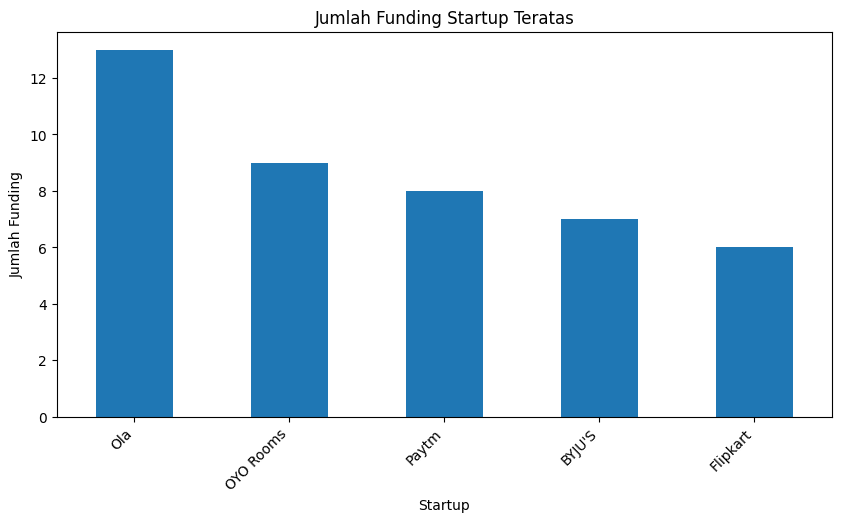

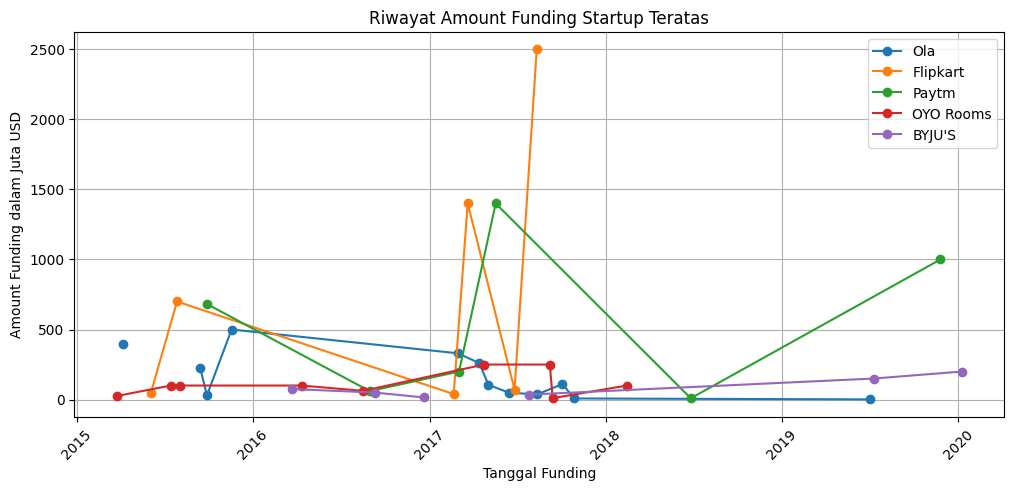


Insight Awal STEP 23:
1. Dari startup yang dianalisis, total funding terbesar dimiliki oleh Flipkart dengan total sekitar 4,759.70 juta USD.
2. Startup dengan jumlah funding terbanyak adalah Ola dengan 13 kali funding.
3. Grafik riwayat funding membantu melihat startup mana yang menerima pendanaan besar pada periode tertentu.
4. Jika terdapat lonjakan sangat tinggi pada satu titik, kemungkinan itu adalah funding round besar yang memengaruhi total funding startup tersebut.


In [79]:
# STEP 23 Detail Riwayat Funding Startup Teratas

# Startup yang akan dianalisis lebih detail
selected_startups = ['Ola', 'Flipkart', 'Paytm', 'OYO Rooms', "BYJU'S"]

# Filter data hanya untuk startup terpilih
startup_history = df[df['startup_name_clean'].isin(selected_startups)].copy()

# Urutkan berdasarkan nama startup dan tanggal funding
startup_history = startup_history.sort_values(by=['startup_name_clean', 'date_clean'])

# Pilih kolom penting untuk ditampilkan
startup_history_detail = startup_history[[
    'date_clean',
    'startup_name_clean',
    'city_clean',
    'industry_group',
    'investment_type_clean',
    'investors',
    'amount_million_usd'
]]

print("STEP 23: Detail Riwayat Funding Startup Teratas")
display(startup_history_detail)


# Ringkasan detail startup teratas
startup_history_summary = startup_history.groupby('startup_name_clean').agg(
    jumlah_funding=('startup_name_clean', 'count'),
    total_funding_juta_usd=('amount_million_usd', 'sum'),
    rata_rata_funding_juta_usd=('amount_million_usd', 'mean'),
    median_funding_juta_usd=('amount_million_usd', 'median'),
    funding_terbesar_juta_usd=('amount_million_usd', 'max'),
    funding_pertama=('date_clean', 'min'),
    funding_terakhir=('date_clean', 'max')
).sort_values(by='total_funding_juta_usd', ascending=False)

print("\nRingkasan Riwayat Funding Startup Teratas")
display(startup_history_summary)


# Visualisasi total funding untuk startup teratas
plt.figure(figsize=(10, 5))
startup_history_summary['total_funding_juta_usd'].plot(kind='bar')

plt.title('Total Funding Startup Teratas')
plt.xlabel('Startup')
plt.ylabel('Total Funding dalam Juta USD')
plt.xticks(rotation=45, ha='right')
plt.show()


# Visualisasi jumlah funding untuk startup teratas
plt.figure(figsize=(10, 5))
startup_history_summary['jumlah_funding'].sort_values(ascending=False).plot(kind='bar')

plt.title('Jumlah Funding Startup Teratas')
plt.xlabel('Startup')
plt.ylabel('Jumlah Funding')
plt.xticks(rotation=45, ha='right')
plt.show()


# Visualisasi riwayat amount funding per startup
plt.figure(figsize=(12, 5))

for startup in selected_startups:
    temp = startup_history[startup_history['startup_name_clean'] == startup]
    temp = temp.sort_values(by='date_clean')

    plt.plot(
        temp['date_clean'],
        temp['amount_million_usd'],
        marker='o',
        label=startup
    )

plt.title('Riwayat Amount Funding Startup Teratas')
plt.xlabel('Tanggal Funding')
plt.ylabel('Amount Funding dalam Juta USD')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()


# Insight otomatis sederhana
top_startup_amount = startup_history_summary.index[0]
top_startup_amount_value = startup_history_summary.iloc[0]['total_funding_juta_usd']

top_startup_count = startup_history_summary.sort_values(
    by='jumlah_funding',
    ascending=False
).index[0]

top_startup_count_value = startup_history_summary.sort_values(
    by='jumlah_funding',
    ascending=False
).iloc[0]['jumlah_funding']

print("\nInsight Awal STEP 23:")
print(f"1. Dari startup yang dianalisis, total funding terbesar dimiliki oleh {top_startup_amount} dengan total sekitar {top_startup_amount_value:,.2f} juta USD.")
print(f"2. Startup dengan jumlah funding terbanyak adalah {top_startup_count} dengan {top_startup_count_value} kali funding.")
print("3. Grafik riwayat funding membantu melihat startup mana yang menerima pendanaan besar pada periode tertentu.")
print("4. Jika terdapat lonjakan sangat tinggi pada satu titik, kemungkinan itu adalah funding round besar yang memengaruhi total funding startup tersebut.")

STEP 24: Top 20 Funding Deal Terbesar


,date_clean,startup_name_clean,city_clean,industry_group,investment_type_clean,investors,amount_million_usd
60,2019-08-27,Rapido Bike Taxi,Bengaluru,Logistics/Transportation,Series B,Westbridge Capital,3900.0
651,2017-08-11,Flipkart,Bengaluru,E-commerce,Private Equity,Softbank,2500.0
966,2017-03-21,Flipkart,Bengaluru,E-commerce,Private Equity,"Microsoft, eBay, Tencent Holdings",1400.0
830,2017-05-18,Paytm,Bengaluru,E-commerce,Private Equity,SoftBank Group,1400.0
31,2019-11-25,Paytm,Noida,FinTech/Finance,Other Funding Round,Vijay Shekhar Sharma,1000.0
2648,2015-07-28,Flipkart,Bengaluru,E-commerce,Private Equity,Steadview Capital and existing investors,700.0
2459,2015-09-29,Paytm,New Delhi,E-commerce,Private Equity,"Alibaba Group, Ant Financial",680.0
188,2018-08-30,True North,Mumbai,FinTech/Finance,Private Equity,NaN,600.0
33,2019-10-02,Udaan,Bengaluru,Others,Series D,"Altimeter Capital, DST Global",585.0
2470,2015-08-01,Snapdeal,New Delhi,E-commerce,Private Equity,"Alibaba, Foxconn, Softbank",500.0


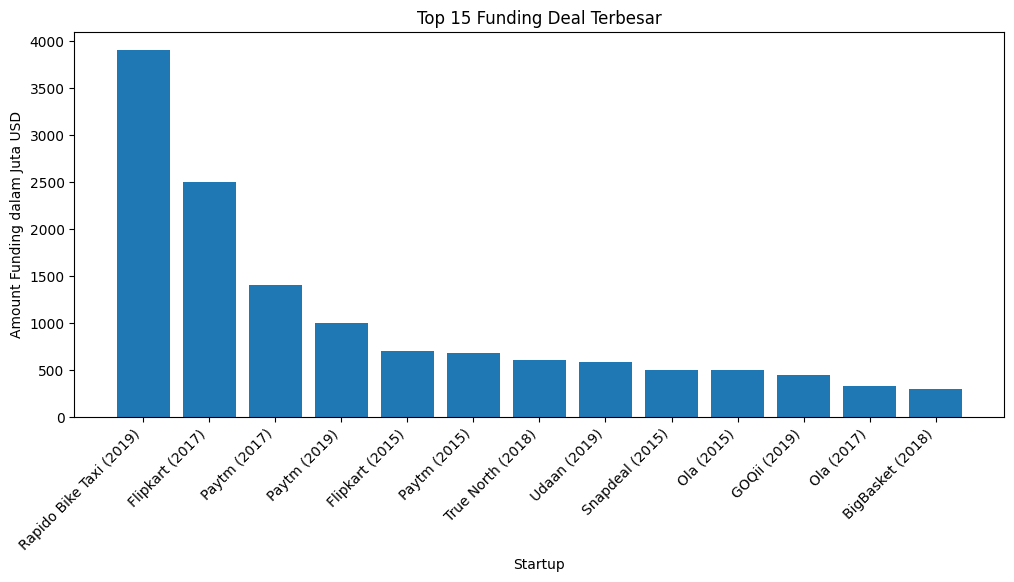


Batas Outlier Berdasarkan IQR
Q1: 0.49 juta USD
Q3: 8.00 juta USD
IQR: 7.51 juta USD
Upper Bound Outlier: 19.27 juta USD

Jumlah data funding yang termasuk outlier:
285

Top 20 Outlier Funding Terbesar


,date_clean,startup_name_clean,city_clean,industry_group,investment_type_clean,investors,amount_million_usd
60,2019-08-27,Rapido Bike Taxi,Bengaluru,Logistics/Transportation,Series B,Westbridge Capital,3900.0
651,2017-08-11,Flipkart,Bengaluru,E-commerce,Private Equity,Softbank,2500.0
966,2017-03-21,Flipkart,Bengaluru,E-commerce,Private Equity,"Microsoft, eBay, Tencent Holdings",1400.0
830,2017-05-18,Paytm,Bengaluru,E-commerce,Private Equity,SoftBank Group,1400.0
31,2019-11-25,Paytm,Noida,FinTech/Finance,Other Funding Round,Vijay Shekhar Sharma,1000.0
2648,2015-07-28,Flipkart,Bengaluru,E-commerce,Private Equity,Steadview Capital and existing investors,700.0
2459,2015-09-29,Paytm,New Delhi,E-commerce,Private Equity,"Alibaba Group, Ant Financial",680.0
188,2018-08-30,True North,Mumbai,FinTech/Finance,Private Equity,NaN,600.0
33,2019-10-02,Udaan,Bengaluru,Others,Series D,"Altimeter Capital, DST Global",585.0
2244,2015-11-18,Ola,Bengaluru,E-commerce,Private Equity,"Baillie Gifford, Falcon Edge Capital, Tiger Gl...",500.0



Kontribusi Outlier terhadap Total Funding
Total funding seluruh data: 38,143.91 juta USD
Total funding dari outlier: 32,466.84 juta USD
Kontribusi outlier: 85.12%


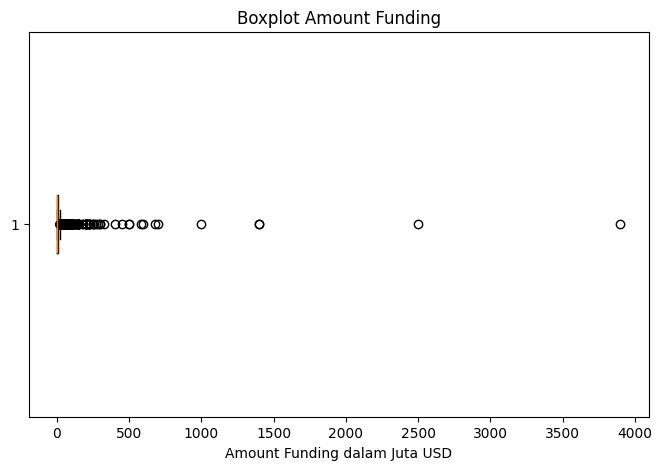

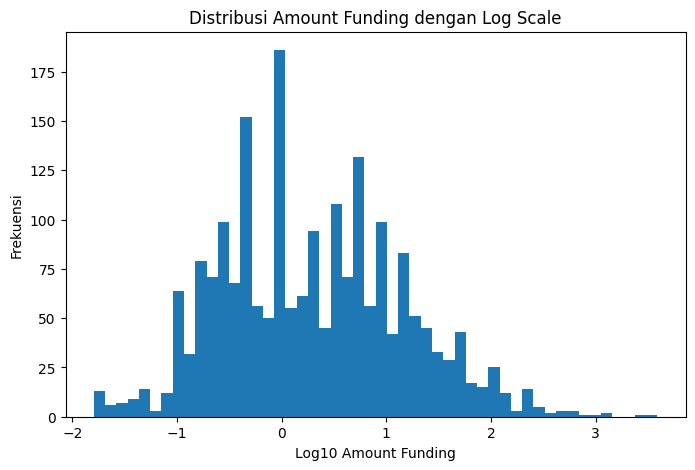


Insight Awal STEP 24:
1. Funding deal terbesar adalah Rapido Bike Taxi dengan nilai sekitar 3,900.00 juta USD.
2. Dengan metode IQR, funding di atas 19.27 juta USD dikategorikan sebagai outlier.
3. Terdapat 285 data funding yang termasuk outlier.
4. Outlier menyumbang sekitar 85.12% dari total funding.
5. Artinya, sebagian besar total funding dapat dipengaruhi oleh sejumlah kecil deal bernilai sangat besar.


In [80]:
# STEP 24 Analisis Outlier Funding Terbesar

# Ambil data yang memiliki amount
funding_with_amount = df[df['amount_million_usd'].notnull()].copy()

# Urutkan berdasarkan amount terbesar
top_funding_deals = funding_with_amount.sort_values(
    by='amount_million_usd',
    ascending=False
)

print("STEP 24: Top 20 Funding Deal Terbesar")
display(top_funding_deals[[
    'date_clean',
    'startup_name_clean',
    'city_clean',
    'industry_group',
    'investment_type_clean',
    'investors',
    'amount_million_usd'
]].head(20))


# Visualisasi top 15 funding deal terbesar
top_15_deals = top_funding_deals.head(15).copy()

# Label untuk grafik
top_15_deals['deal_label'] = (
    top_15_deals['startup_name_clean'].astype(str) +
    ' (' +
    top_15_deals['date_clean'].dt.year.astype(str) +
    ')'
)

plt.figure(figsize=(12, 5))
plt.bar(top_15_deals['deal_label'], top_15_deals['amount_million_usd'])

plt.title('Top 15 Funding Deal Terbesar')
plt.xlabel('Startup')
plt.ylabel('Amount Funding dalam Juta USD')
plt.xticks(rotation=45, ha='right')
plt.show()


# Menghitung outlier dengan metode IQR
Q1 = funding_with_amount['amount_million_usd'].quantile(0.25)
Q3 = funding_with_amount['amount_million_usd'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_funding = funding_with_amount[
    funding_with_amount['amount_million_usd'] > upper_bound
].copy()

outlier_funding = outlier_funding.sort_values(
    by='amount_million_usd',
    ascending=False
)

print("\nBatas Outlier Berdasarkan IQR")
print(f"Q1: {Q1:,.2f} juta USD")
print(f"Q3: {Q3:,.2f} juta USD")
print(f"IQR: {IQR:,.2f} juta USD")
print(f"Upper Bound Outlier: {upper_bound:,.2f} juta USD")

print("\nJumlah data funding yang termasuk outlier:")
print(outlier_funding.shape[0])

print("\nTop 20 Outlier Funding Terbesar")
display(outlier_funding[[
    'date_clean',
    'startup_name_clean',
    'city_clean',
    'industry_group',
    'investment_type_clean',
    'investors',
    'amount_million_usd'
]].head(20))


# Persentase kontribusi outlier terhadap total funding
total_funding_all = funding_with_amount['amount_million_usd'].sum()
total_funding_outlier = outlier_funding['amount_million_usd'].sum()
outlier_contribution = (total_funding_outlier / total_funding_all) * 100

print("\nKontribusi Outlier terhadap Total Funding")
print(f"Total funding seluruh data: {total_funding_all:,.2f} juta USD")
print(f"Total funding dari outlier: {total_funding_outlier:,.2f} juta USD")
print(f"Kontribusi outlier: {outlier_contribution:.2f}%")


# Visualisasi distribusi amount dengan boxplot
plt.figure(figsize=(8, 5))
plt.boxplot(funding_with_amount['amount_million_usd'], vert=False)

plt.title('Boxplot Amount Funding')
plt.xlabel('Amount Funding dalam Juta USD')
plt.show()


# Visualisasi distribusi amount dengan log scale
plt.figure(figsize=(8, 5))
plt.hist(np.log10(funding_with_amount['amount_million_usd']), bins=50)

plt.title('Distribusi Amount Funding dengan Log Scale')
plt.xlabel('Log10 Amount Funding')
plt.ylabel('Frekuensi')
plt.show()


# Insight otomatis sederhana
largest_deal = top_funding_deals.iloc[0]

print("\nInsight Awal STEP 24:")
print(f"1. Funding deal terbesar adalah {largest_deal['startup_name_clean']} dengan nilai sekitar {largest_deal['amount_million_usd']:,.2f} juta USD.")
print(f"2. Dengan metode IQR, funding di atas {upper_bound:,.2f} juta USD dikategorikan sebagai outlier.")
print(f"3. Terdapat {outlier_funding.shape[0]} data funding yang termasuk outlier.")
print(f"4. Outlier menyumbang sekitar {outlier_contribution:.2f}% dari total funding.")
print("5. Artinya, sebagian besar total funding dapat dipengaruhi oleh sejumlah kecil deal bernilai sangat besar.")

STEP 25: Analisis Tanpa Outlier
Q1: 0.49 juta USD
Q3: 8.00 juta USD
IQR: 7.51 juta USD
Upper Bound Outlier: 19.27 juta USD

Jumlah data dengan amount:
2073

Jumlah data tanpa outlier:
1788

Jumlah data outlier yang dikeluarkan:
285

Perbandingan Statistik Amount Funding


,Dengan Outlier,Tanpa Outlier
count,2073.000000,1788.000000
mean,18.400345,3.175098
std,121.140713,4.250381
min,0.016000,0.016000
25%,0.486000,0.375000
50%,1.750000,1.000000
75%,8.000000,4.500000
max,3900.000000,19.000000



Perbandingan Total Funding per Tahun


,dengan_outlier,tanpa_outlier,selisih,persentase_terpengaruh
year,,,,
2015,8673.022368,1722.172368,6950.850,80.143342
2016,3828.088608,1344.788608,2483.300,64.870494
2017,10429.309730,1343.309730,9086.000,87.119860
2018,5122.368369,859.839369,4262.529,83.214027
2019,9700.918535,366.758535,9334.160,96.219342
2020,390.207254,40.207254,350.000,89.695923


<Figure size 1000x500 with 0 Axes>

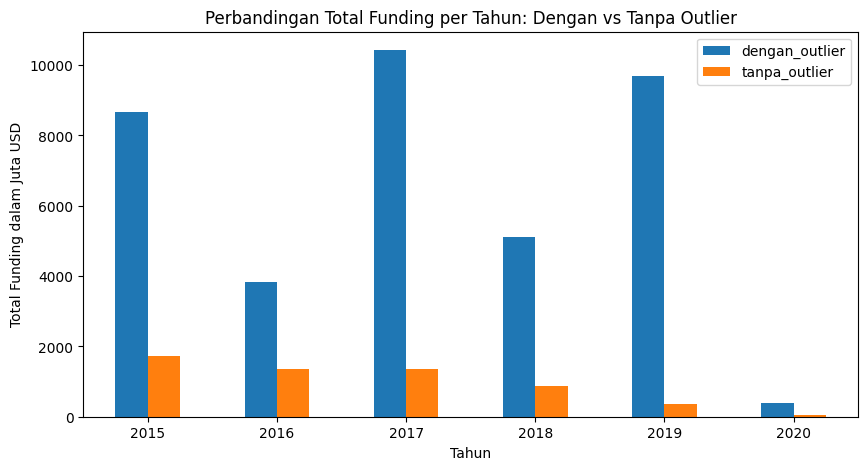


Perbandingan Total Funding Berdasarkan Industri


,dengan_outlier,tanpa_outlier,selisih,persentase_terpengaruh
industry_group,,,,
E-commerce,13166.288693,1208.908693,11957.380,90.818151
Logistics/Transportation,7146.117624,357.617624,6788.500,94.995638
FinTech/Finance,4921.110265,814.011265,4107.099,83.458788
Technology/SaaS,2936.189100,856.609100,2079.580,70.825820
Consumer Internet,2498.198920,670.498920,1827.700,73.160707
Others,2013.756635,336.406635,1677.350,83.294573
Healthcare/HealthTech,1870.469000,364.239000,1506.230,80.526863
EdTech/Education,1010.204065,273.204065,737.000,72.955557
Food & Beverage,972.669195,312.669195,660.000,67.854519


<Figure size 1000x500 with 0 Axes>

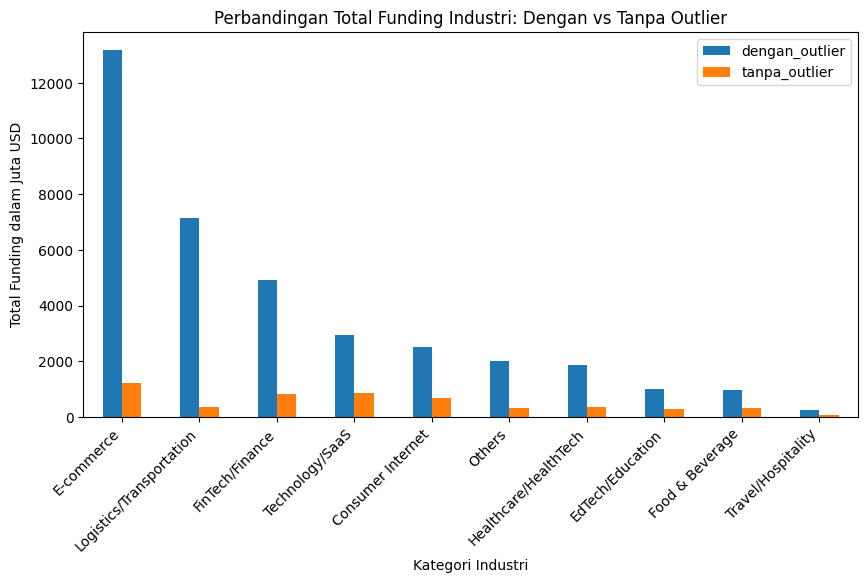


Perbandingan Total Funding Berdasarkan Kota


,dengan_outlier,tanpa_outlier,selisih,persentase_terpengaruh
city_clean,,,,
Bengaluru,18797.708863,1819.808863,16977.900,90.318986
Mumbai,4939.225015,1110.925015,3828.300,77.508111
Gurugram,3872.428658,712.528658,3159.900,81.599954
New Delhi,3358.571515,583.571515,2775.000,82.624413
Noida,1263.164000,135.084000,1128.080,89.305902
Chennai,718.767000,229.468000,489.299,68.074772
Pune,717.582000,195.582000,522.000,72.744300
Menlo Park,450.000000,0.000000,450.000,100.000000
Hyderabad,401.676230,159.476230,242.200,60.297320


<Figure size 1000x500 with 0 Axes>

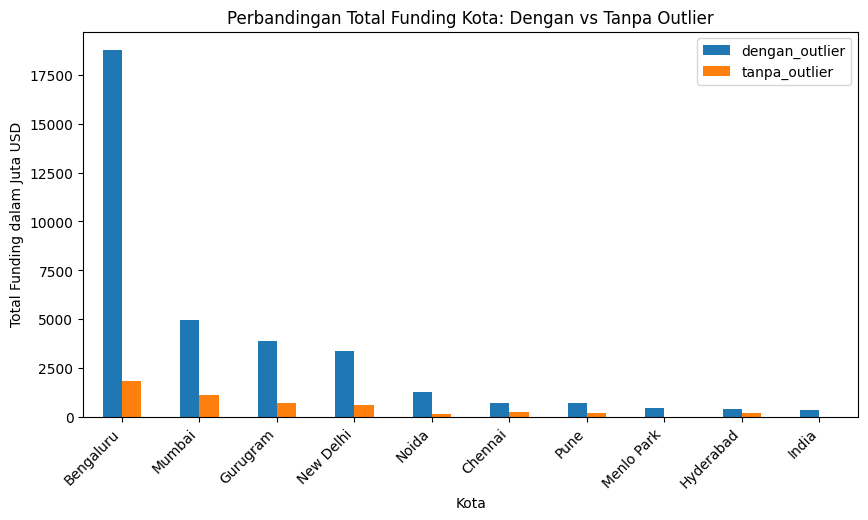


Insight Awal STEP 25:
1. Tahun dengan total funding terbesar dengan outlier adalah 2017.
2. Tahun dengan total funding terbesar tanpa outlier adalah 2015.
3. Industri dengan total funding terbesar dengan outlier adalah E-commerce.
4. Industri dengan total funding terbesar tanpa outlier adalah E-commerce.
5. Kota dengan total funding terbesar dengan outlier adalah Bengaluru.
6. Kota dengan total funding terbesar tanpa outlier adalah Bengaluru.
7. Jika hasil berubah setelah outlier dihapus, berarti insight total funding sangat dipengaruhi oleh deal besar.


In [81]:
# STEP 25 Analisis Tanpa Outlier

# Mengambil data yang memiliki amount
funding_with_amount = df[df['amount_million_usd'].notnull()].copy()

# Menghitung ulang batas outlier dengan metode IQR
Q1 = funding_with_amount['amount_million_usd'].quantile(0.25)
Q3 = funding_with_amount['amount_million_usd'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

# Dataset tanpa outlier
df_no_outlier = funding_with_amount[
    funding_with_amount['amount_million_usd'] <= upper_bound
].copy()

print("STEP 25: Analisis Tanpa Outlier")
print("="*60)

print(f"Q1: {Q1:,.2f} juta USD")
print(f"Q3: {Q3:,.2f} juta USD")
print(f"IQR: {IQR:,.2f} juta USD")
print(f"Upper Bound Outlier: {upper_bound:,.2f} juta USD")

print("\nJumlah data dengan amount:")
print(funding_with_amount.shape[0])

print("\nJumlah data tanpa outlier:")
print(df_no_outlier.shape[0])

print("\nJumlah data outlier yang dikeluarkan:")
print(funding_with_amount.shape[0] - df_no_outlier.shape[0])


# Perbandingan Statistik Amount

comparison_stats = pd.DataFrame({
    'Dengan Outlier': funding_with_amount['amount_million_usd'].describe(),
    'Tanpa Outlier': df_no_outlier['amount_million_usd'].describe()
})

print("\nPerbandingan Statistik Amount Funding")
display(comparison_stats)


# Perbandingan Total Funding per Tahun

yearly_with_outlier = funding_with_amount.groupby('year')['amount_million_usd'].sum()
yearly_no_outlier = df_no_outlier.groupby('year')['amount_million_usd'].sum()

yearly_comparison = pd.DataFrame({
    'dengan_outlier': yearly_with_outlier,
    'tanpa_outlier': yearly_no_outlier
})

yearly_comparison['selisih'] = yearly_comparison['dengan_outlier'] - yearly_comparison['tanpa_outlier']
yearly_comparison['persentase_terpengaruh'] = (
    yearly_comparison['selisih'] / yearly_comparison['dengan_outlier'] * 100
)

print("\nPerbandingan Total Funding per Tahun")
display(yearly_comparison)


plt.figure(figsize=(10, 5))
yearly_comparison[['dengan_outlier', 'tanpa_outlier']].plot(kind='bar', figsize=(10, 5))

plt.title('Perbandingan Total Funding per Tahun: Dengan vs Tanpa Outlier')
plt.xlabel('Tahun')
plt.ylabel('Total Funding dalam Juta USD')
plt.xticks(rotation=0)
plt.show()

# Perbandingan Industri Terbesar
industry_with_outlier = funding_with_amount.groupby('industry_group')['amount_million_usd'].sum().sort_values(ascending=False)
industry_no_outlier = df_no_outlier.groupby('industry_group')['amount_million_usd'].sum().sort_values(ascending=False)

industry_comparison = pd.DataFrame({
    'dengan_outlier': industry_with_outlier,
    'tanpa_outlier': industry_no_outlier
}).fillna(0)

industry_comparison['selisih'] = industry_comparison['dengan_outlier'] - industry_comparison['tanpa_outlier']
industry_comparison['persentase_terpengaruh'] = (
    industry_comparison['selisih'] / industry_comparison['dengan_outlier'] * 100
)

industry_comparison = industry_comparison.sort_values(by='dengan_outlier', ascending=False)

print("\nPerbandingan Total Funding Berdasarkan Industri")
display(industry_comparison)


plt.figure(figsize=(10, 5))
industry_comparison[['dengan_outlier', 'tanpa_outlier']].head(10).plot(kind='bar', figsize=(10, 5))

plt.title('Perbandingan Total Funding Industri: Dengan vs Tanpa Outlier')
plt.xlabel('Kategori Industri')
plt.ylabel('Total Funding dalam Juta USD')
plt.xticks(rotation=45, ha='right')
plt.show()

# Perbandingan Kota Terbesar
city_with_outlier = funding_with_amount.groupby('city_clean')['amount_million_usd'].sum().sort_values(ascending=False)
city_no_outlier = df_no_outlier.groupby('city_clean')['amount_million_usd'].sum().sort_values(ascending=False)

city_comparison = pd.DataFrame({
    'dengan_outlier': city_with_outlier,
    'tanpa_outlier': city_no_outlier
}).fillna(0)

city_comparison['selisih'] = city_comparison['dengan_outlier'] - city_comparison['tanpa_outlier']
city_comparison['persentase_terpengaruh'] = (
    city_comparison['selisih'] / city_comparison['dengan_outlier'] * 100
)

city_comparison = city_comparison.sort_values(by='dengan_outlier', ascending=False)

print("\nPerbandingan Total Funding Berdasarkan Kota")
display(city_comparison.head(15))


plt.figure(figsize=(10, 5))
city_comparison[['dengan_outlier', 'tanpa_outlier']].head(10).plot(kind='bar', figsize=(10, 5))

plt.title('Perbandingan Total Funding Kota: Dengan vs Tanpa Outlier')
plt.xlabel('Kota')
plt.ylabel('Total Funding dalam Juta USD')
plt.xticks(rotation=45, ha='right')
plt.show()

# Insight Otomatis
top_year_with = yearly_comparison['dengan_outlier'].idxmax()
top_year_without = yearly_comparison['tanpa_outlier'].idxmax()

top_industry_with = industry_comparison['dengan_outlier'].idxmax()
top_industry_without = industry_comparison['tanpa_outlier'].idxmax()

top_city_with = city_comparison['dengan_outlier'].idxmax()
top_city_without = city_comparison['tanpa_outlier'].idxmax()

print("\nInsight Awal STEP 25:")
print(f"1. Tahun dengan total funding terbesar dengan outlier adalah {top_year_with}.")
print(f"2. Tahun dengan total funding terbesar tanpa outlier adalah {top_year_without}.")
print(f"3. Industri dengan total funding terbesar dengan outlier adalah {top_industry_with}.")
print(f"4. Industri dengan total funding terbesar tanpa outlier adalah {top_industry_without}.")
print(f"5. Kota dengan total funding terbesar dengan outlier adalah {top_city_with}.")
print(f"6. Kota dengan total funding terbesar tanpa outlier adalah {top_city_without}.")
print("7. Jika hasil berubah setelah outlier dihapus, berarti insight total funding sangat dipengaruhi oleh deal besar.")

STEP 26: Ringkasan Berdasarkan Jenis Investasi


,jumlah_funding,jumlah_startup_unik,total_funding_juta_usd,rata_rata_funding_juta_usd,median_funding_juta_usd
investment_type_clean,,,,,
Seed Funding,1401,1315,930.432108,1.233995,0.330000
Private Equity,1367,1079,27397.248165,25.320932,6.000000
Seed/Angel Funding,138,137,125.384810,1.160970,0.713500
Debt Funding,30,29,191.423174,6.600799,5.000000
Series A,24,24,203.200000,9.236364,4.250000
Series B,21,21,4805.195735,228.818845,15.800000
Series C,14,12,1044.718394,74.622742,50.000000
Series D,12,12,1481.799000,123.483250,65.000000
Pre-Series A,9,9,44.372000,5.546500,2.750000


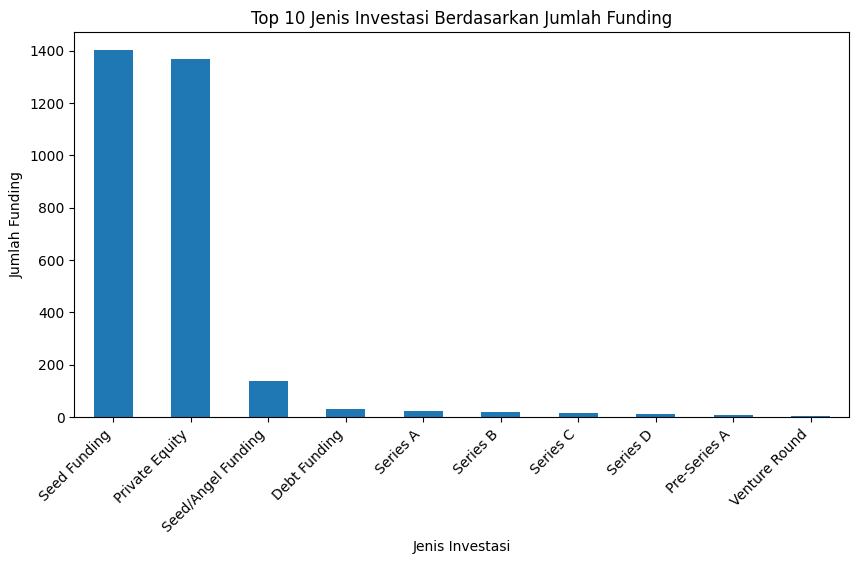

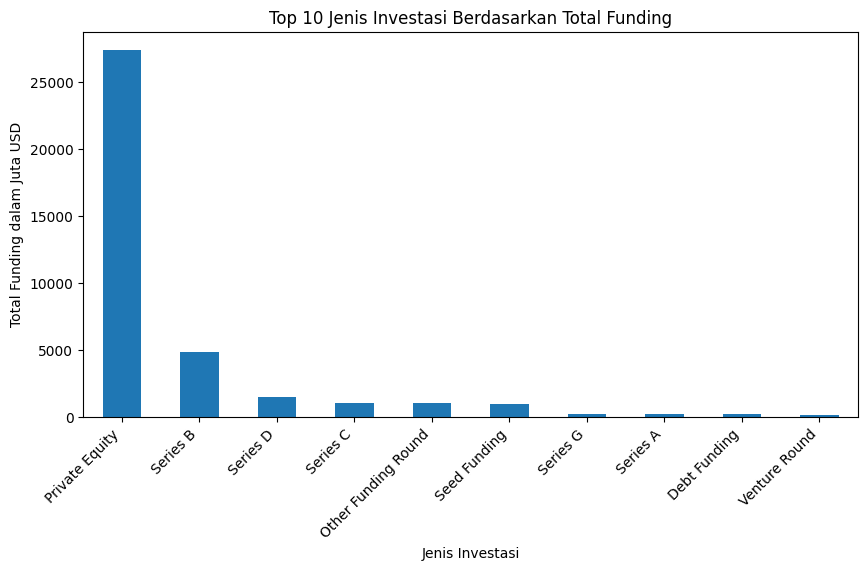

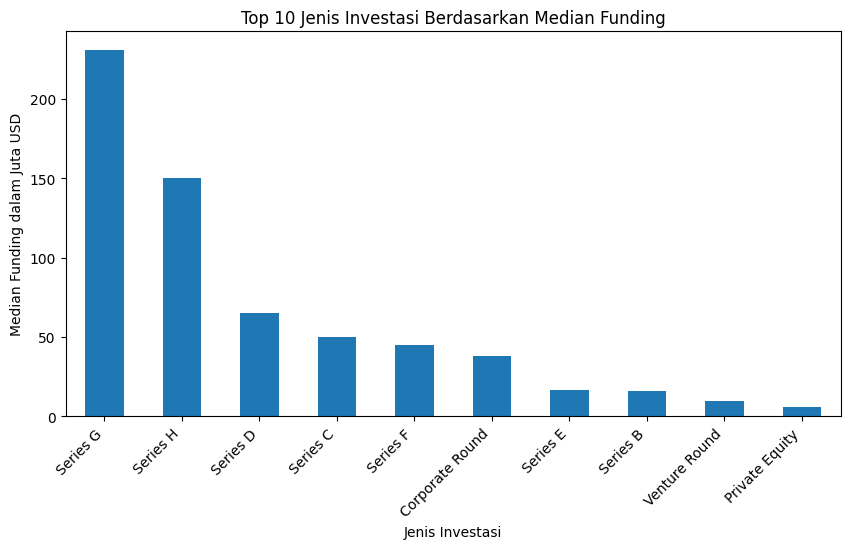


Perbandingan Total Funding Jenis Investasi: Dengan vs Tanpa Outlier


,dengan_outlier,tanpa_outlier,selisih,persentase_terpengaruh
investment_type_clean,,,,
Private Equity,27397.248165,4671.868165,22725.380,82.947674
Series B,4805.195735,132.195735,4673.000,97.248900
Series D,1481.799000,11.000000,1470.799,99.257659
Series C,1044.718394,38.638394,1006.080,96.301549
Other Funding Round,1006.943495,6.943495,1000.000,99.310438
Seed Funding,930.432108,370.432108,560.000,60.187089
Series G,231.000000,0.000000,231.000,100.000000
Series A,203.200000,102.700000,100.500,49.458661
Debt Funding,191.423174,165.423174,26.000,13.582473


<Figure size 1000x500 with 0 Axes>

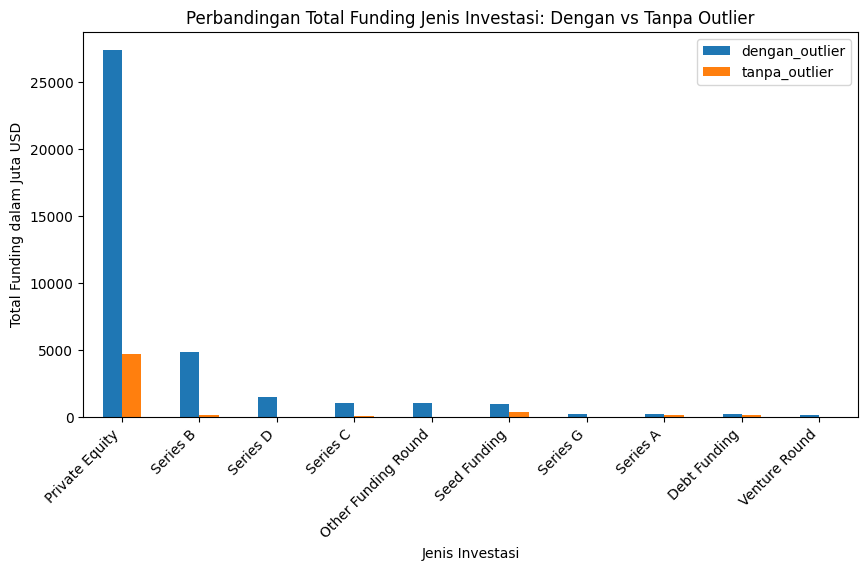


Insight Awal STEP 26:
1. Jenis investasi dengan jumlah funding terbanyak adalah Seed Funding dengan 1401 kali funding.
2. Jenis investasi dengan total funding terbesar adalah Private Equity dengan total sekitar 27,397.25 juta USD.
3. Jenis investasi dengan median funding terbesar adalah Series G dengan median sekitar 231.00 juta USD.
4. Setelah outlier dihapus, jenis investasi dengan total funding terbesar adalah Private Equity.
5. Analisis ini membantu membedakan jenis investasi yang paling sering digunakan dan jenis investasi yang menghasilkan nilai funding paling besar.


In [82]:
# STEP 26 Analisis Jenis Investasi

# Ringkasan jenis investasi
investment_summary = df.groupby('investment_type_clean').agg(
    jumlah_funding=('startup_name', 'count'),
    jumlah_startup_unik=('startup_name', 'nunique'),
    total_funding_juta_usd=('amount_million_usd', 'sum'),
    rata_rata_funding_juta_usd=('amount_million_usd', 'mean'),
    median_funding_juta_usd=('amount_million_usd', 'median')
).sort_values(by='jumlah_funding', ascending=False)

print("STEP 26: Ringkasan Berdasarkan Jenis Investasi")
display(investment_summary)


# Visualisasi 1: Jumlah funding berdasarkan jenis investasi

top_investment_count = investment_summary['jumlah_funding'].head(10)

plt.figure(figsize=(10, 5))
top_investment_count.plot(kind='bar')

plt.title('Top 10 Jenis Investasi Berdasarkan Jumlah Funding')
plt.xlabel('Jenis Investasi')
plt.ylabel('Jumlah Funding')
plt.xticks(rotation=45, ha='right')
plt.show()


# Visualisasi 2: Total funding berdasarkan jenis investasi

top_investment_amount = investment_summary.sort_values(
    by='total_funding_juta_usd',
    ascending=False
)['total_funding_juta_usd'].head(10)

plt.figure(figsize=(10, 5))
top_investment_amount.plot(kind='bar')

plt.title('Top 10 Jenis Investasi Berdasarkan Total Funding')
plt.xlabel('Jenis Investasi')
plt.ylabel('Total Funding dalam Juta USD')
plt.xticks(rotation=45, ha='right')
plt.show()


# Visualisasi 3: Median funding berdasarkan jenis investasi

top_investment_median = investment_summary.sort_values(
    by='median_funding_juta_usd',
    ascending=False
)['median_funding_juta_usd'].head(10)

plt.figure(figsize=(10, 5))
top_investment_median.plot(kind='bar')

plt.title('Top 10 Jenis Investasi Berdasarkan Median Funding')
plt.xlabel('Jenis Investasi')
plt.ylabel('Median Funding dalam Juta USD')
plt.xticks(rotation=45, ha='right')
plt.show()


# Perbandingan dengan dan tanpa outlier

investment_with_outlier = df.groupby('investment_type_clean')['amount_million_usd'].sum()

investment_no_outlier = df_no_outlier.groupby('investment_type_clean')['amount_million_usd'].sum()

investment_comparison = pd.DataFrame({
    'dengan_outlier': investment_with_outlier,
    'tanpa_outlier': investment_no_outlier
}).fillna(0)

investment_comparison['selisih'] = (
    investment_comparison['dengan_outlier'] -
    investment_comparison['tanpa_outlier']
)

investment_comparison['persentase_terpengaruh'] = (
    investment_comparison['selisih'] /
    investment_comparison['dengan_outlier'] * 100
)

investment_comparison = investment_comparison.sort_values(
    by='dengan_outlier',
    ascending=False
)

print("\nPerbandingan Total Funding Jenis Investasi: Dengan vs Tanpa Outlier")
display(investment_comparison)


plt.figure(figsize=(10, 5))
investment_comparison[['dengan_outlier', 'tanpa_outlier']].head(10).plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('Perbandingan Total Funding Jenis Investasi: Dengan vs Tanpa Outlier')
plt.xlabel('Jenis Investasi')
plt.ylabel('Total Funding dalam Juta USD')
plt.xticks(rotation=45, ha='right')
plt.show()


# Insight otomatis

top_investment_by_count = investment_summary['jumlah_funding'].idxmax()
top_investment_count_value = investment_summary.loc[top_investment_by_count, 'jumlah_funding']

top_investment_by_amount = investment_summary['total_funding_juta_usd'].idxmax()
top_investment_amount_value = investment_summary.loc[top_investment_by_amount, 'total_funding_juta_usd']

top_investment_by_median = investment_summary['median_funding_juta_usd'].idxmax()
top_investment_median_value = investment_summary.loc[top_investment_by_median, 'median_funding_juta_usd']

top_investment_without_outlier = investment_comparison['tanpa_outlier'].idxmax()

print("\nInsight Awal STEP 26:")
print(f"1. Jenis investasi dengan jumlah funding terbanyak adalah {top_investment_by_count} dengan {top_investment_count_value} kali funding.")
print(f"2. Jenis investasi dengan total funding terbesar adalah {top_investment_by_amount} dengan total sekitar {top_investment_amount_value:,.2f} juta USD.")
print(f"3. Jenis investasi dengan median funding terbesar adalah {top_investment_by_median} dengan median sekitar {top_investment_median_value:,.2f} juta USD.")
print(f"4. Setelah outlier dihapus, jenis investasi dengan total funding terbesar adalah {top_investment_without_outlier}.")
print("5. Analisis ini membantu membedakan jenis investasi yang paling sering digunakan dan jenis investasi yang menghasilkan nilai funding paling besar.")

STEP 27A: Jumlah Funding per Tahun dan Industri


industry_group,Consumer Internet,E-commerce,EdTech/Education,FinTech/Finance,Food & Beverage,Healthcare/HealthTech,Logistics/Transportation,Others,Real Estate,Technology/SaaS,Travel/Hospitality
year,,,,,,,,,,,
2015,12,158,39,36,51,48,53,234,25,85,24
2016,324,218,49,59,38,94,49,8,5,149,0
2017,148,131,39,76,24,62,38,6,2,161,0
2018,37,47,24,75,14,43,8,6,1,55,0
2019,3,23,8,16,7,8,13,15,0,18,0
2020,0,2,1,1,0,1,2,0,0,0,0



STEP 27B: Total Funding per Tahun dan Industri dalam Juta USD


industry_group,Consumer Internet,E-commerce,EdTech/Education,FinTech/Finance,Food & Beverage,Healthcare/HealthTech,Logistics/Transportation,Others,Real Estate,Technology/SaaS,Travel/Hospitality
year,,,,,,,,,,,
2015,8.680000,3577.390000,82.803000,267.065000,355.667000,272.725,943.995000,1235.081000,75.03,366.3250,256.45
2016,1350.496000,1002.502608,189.858000,313.540000,129.186000,107.535,205.209000,1.188000,18.50,510.0740,0.00
2017,713.475000,6310.424000,116.797000,927.657000,128.916000,244.668,1230.501230,14.200000,23.12,719.5515,0.00
2018,406.416845,935.227089,56.298640,1888.037000,323.710195,542.555,274.480000,8.835000,4.00,682.8086,0.00
2019,19.131075,1320.586136,364.447425,1521.811265,35.190000,552.986,4474.884000,754.452635,0.00,657.4300,0.00
2020,0.000000,20.158860,200.000000,3.000000,0.000000,150.000,17.048394,0.000000,0.00,0.0000,0.00



STEP 27C: Industri Dominan per Tahun Berdasarkan Jumlah Funding


,industri_dominan_jumlah_funding,jumlah_funding
year,,
2015,Others,234
2016,Consumer Internet,324
2017,Technology/SaaS,161
2018,FinTech/Finance,75
2019,E-commerce,23
2020,E-commerce,2



STEP 27D: Industri Dominan per Tahun Berdasarkan Total Funding


,industri_dominan_total_funding,total_funding_juta_usd
year,,
2015,E-commerce,3577.390
2016,Consumer Internet,1350.496
2017,E-commerce,6310.424
2018,FinTech/Finance,1888.037
2019,Logistics/Transportation,4474.884
2020,EdTech/Education,200.000


<Figure size 1200x600 with 0 Axes>

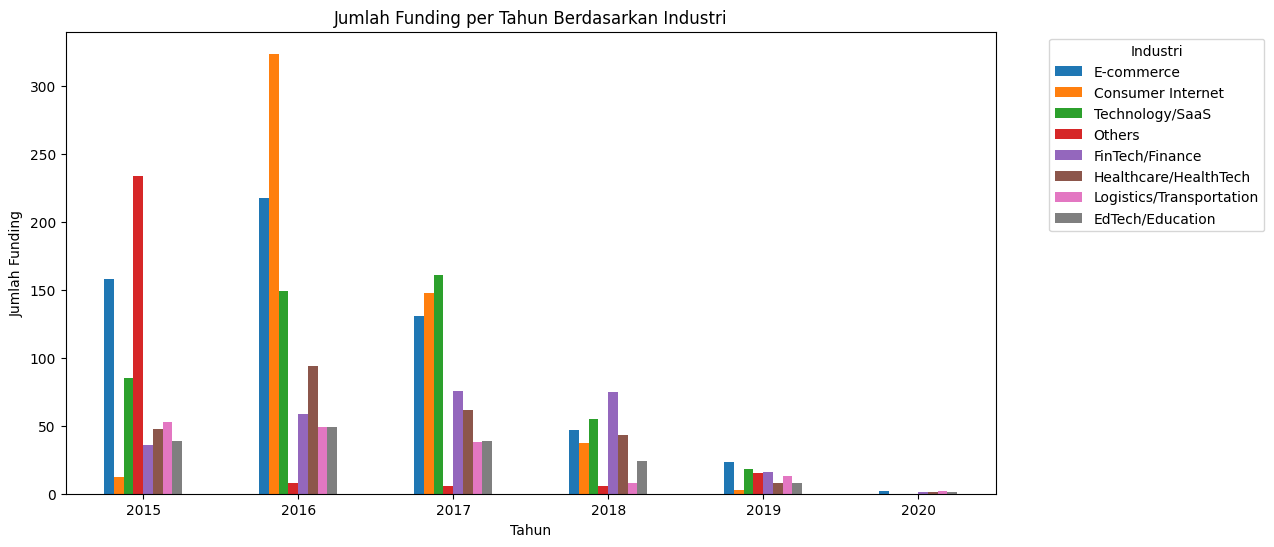

<Figure size 1200x600 with 0 Axes>

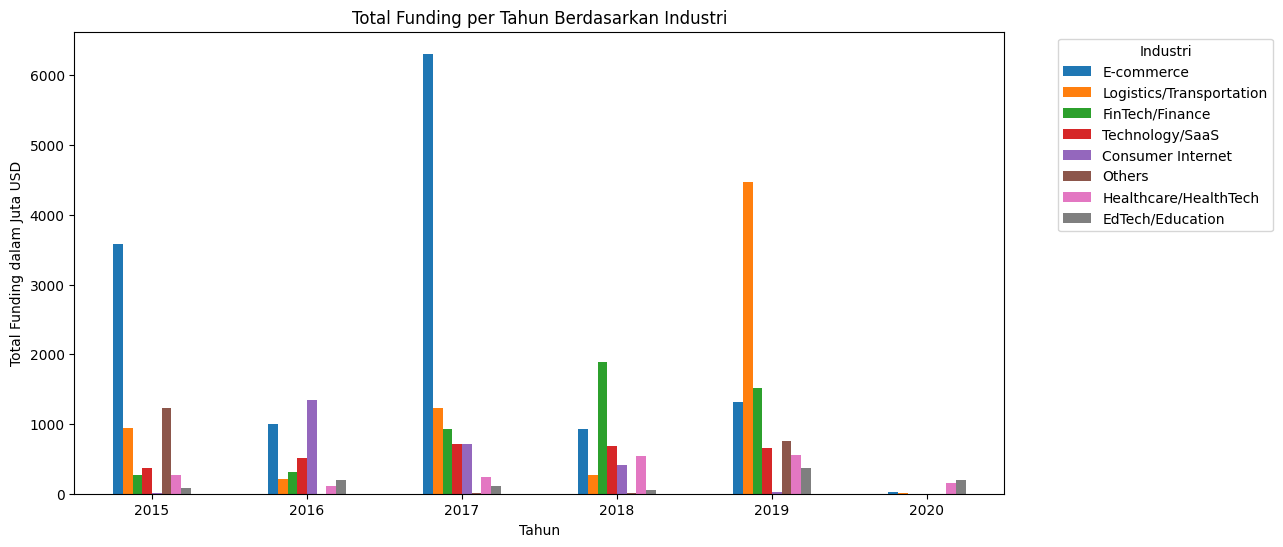

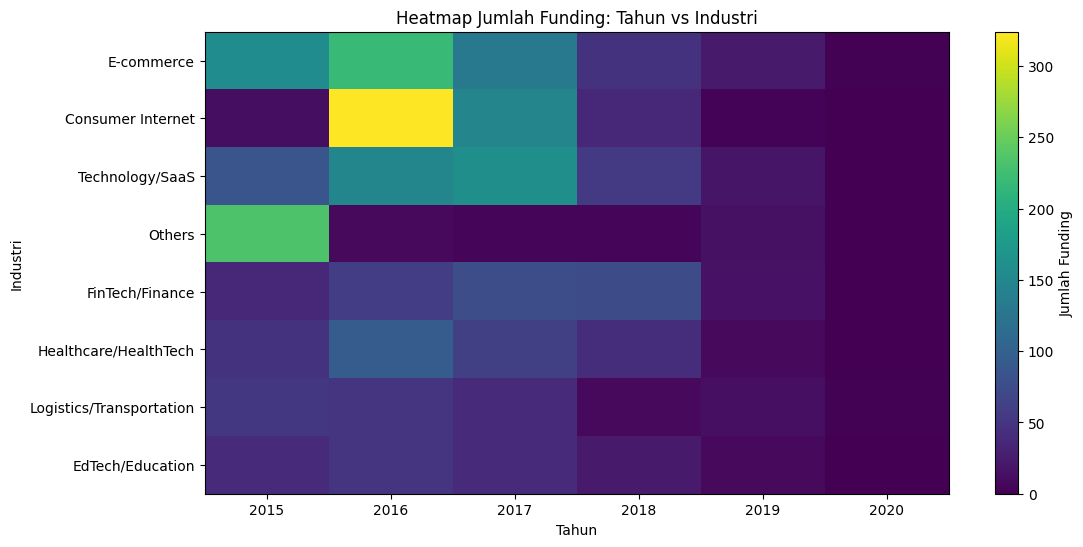

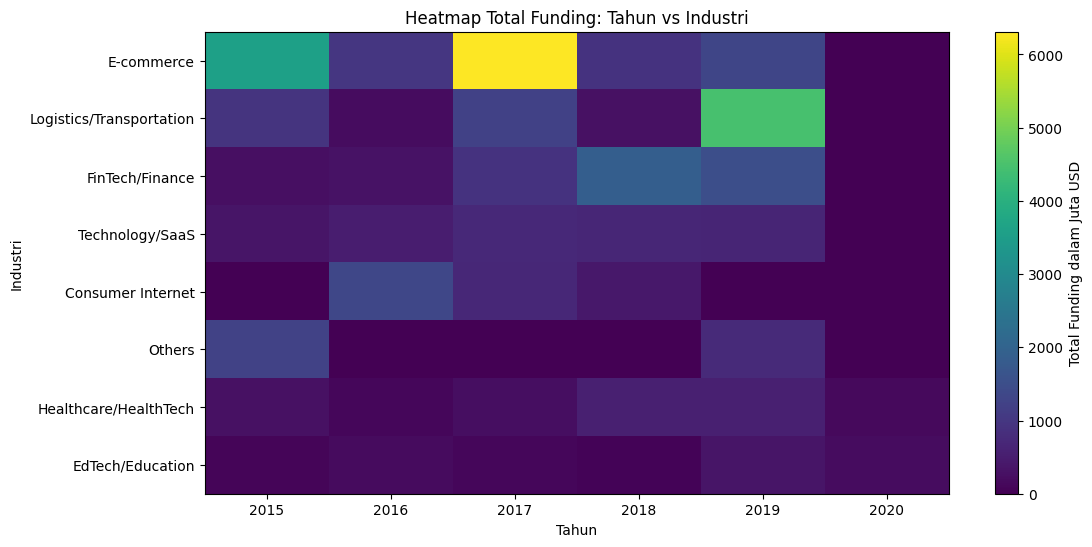


Insight Awal STEP 27:
1. Industri dominan berdasarkan jumlah funding per tahun:
   - 2015: Others dengan 234 kali funding
   - 2016: Consumer Internet dengan 324 kali funding
   - 2017: Technology/SaaS dengan 161 kali funding
   - 2018: FinTech/Finance dengan 75 kali funding
   - 2019: E-commerce dengan 23 kali funding
   - 2020: E-commerce dengan 2 kali funding

2. Industri dominan berdasarkan total funding per tahun:
   - 2015: E-commerce dengan total sekitar 3,577.39 juta USD
   - 2016: Consumer Internet dengan total sekitar 1,350.50 juta USD
   - 2017: E-commerce dengan total sekitar 6,310.42 juta USD
   - 2018: FinTech/Finance dengan total sekitar 1,888.04 juta USD
   - 2019: Logistics/Transportation dengan total sekitar 4,474.88 juta USD
   - 2020: EdTech/Education dengan total sekitar 200.00 juta USD

3. Catatan: Tahun 2020 hanya berisi data Januari, sehingga interpretasinya harus hati-hati.
4. Jika industri dominan berdasarkan jumlah funding berbeda dengan total funding, artin

In [83]:
# STEP 27 Hubungan Tahun dan Industri

# Mengambil data yang memiliki tahun dan industry_group
year_industry_data = df[
    df['year'].notnull() &
    df['industry_group'].notnull()
].copy()

# 1. Jumlah Funding per Tahun dan Industri
year_industry_count = year_industry_data.pivot_table(
    index='year',
    columns='industry_group',
    values='startup_name',
    aggfunc='count',
    fill_value=0
)

print("STEP 27A: Jumlah Funding per Tahun dan Industri")
display(year_industry_count)


# 2. Total Funding per Tahun dan Industri
year_industry_amount = year_industry_data.pivot_table(
    index='year',
    columns='industry_group',
    values='amount_million_usd',
    aggfunc='sum',
    fill_value=0
)

print("\nSTEP 27B: Total Funding per Tahun dan Industri dalam Juta USD")
display(year_industry_amount)


# 3. Industri Dominan per Tahun Berdasarkan Jumlah Funding
dominant_industry_count = year_industry_count.idxmax(axis=1)
dominant_industry_count_value = year_industry_count.max(axis=1)

dominant_industry_count_df = pd.DataFrame({
    'industri_dominan_jumlah_funding': dominant_industry_count,
    'jumlah_funding': dominant_industry_count_value
})

print("\nSTEP 27C: Industri Dominan per Tahun Berdasarkan Jumlah Funding")
display(dominant_industry_count_df)


# 4. Industri Dominan per Tahun Berdasarkan Total Funding
dominant_industry_amount = year_industry_amount.idxmax(axis=1)
dominant_industry_amount_value = year_industry_amount.max(axis=1)

dominant_industry_amount_df = pd.DataFrame({
    'industri_dominan_total_funding': dominant_industry_amount,
    'total_funding_juta_usd': dominant_industry_amount_value
})

print("\nSTEP 27D: Industri Dominan per Tahun Berdasarkan Total Funding")
display(dominant_industry_amount_df)

# 5. Visualisasi Jumlah Funding: Top Industri per Tahun
# Ambil top 8 industri berdasarkan total jumlah funding
top_industries_by_count = year_industry_count.sum().sort_values(ascending=False).head(8).index

year_industry_count_top = year_industry_count[top_industries_by_count]

plt.figure(figsize=(12, 6))
year_industry_count_top.plot(kind='bar', figsize=(12, 6))

plt.title('Jumlah Funding per Tahun Berdasarkan Industri')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Funding')
plt.xticks(rotation=0)
plt.legend(title='Industri', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


# 6. Visualisasi Total Funding: Top Industri per Tahun
# Ambil top 8 industri berdasarkan total funding
top_industries_by_amount = year_industry_amount.sum().sort_values(ascending=False).head(8).index

year_industry_amount_top = year_industry_amount[top_industries_by_amount]

plt.figure(figsize=(12, 6))
year_industry_amount_top.plot(kind='bar', figsize=(12, 6))

plt.title('Total Funding per Tahun Berdasarkan Industri')
plt.xlabel('Tahun')
plt.ylabel('Total Funding dalam Juta USD')
plt.xticks(rotation=0)
plt.legend(title='Industri', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# 7. Heatmap Manual Jumlah Funding
plt.figure(figsize=(12, 6))

plt.imshow(year_industry_count_top.T, aspect='auto')

plt.title('Heatmap Jumlah Funding: Tahun vs Industri')
plt.xlabel('Tahun')
plt.ylabel('Industri')

plt.xticks(
    ticks=range(len(year_industry_count_top.index)),
    labels=year_industry_count_top.index
)

plt.yticks(
    ticks=range(len(year_industry_count_top.columns)),
    labels=year_industry_count_top.columns
)

plt.colorbar(label='Jumlah Funding')
plt.show()

# 8. Heatmap Manual Total Funding
plt.figure(figsize=(12, 6))

plt.imshow(year_industry_amount_top.T, aspect='auto')

plt.title('Heatmap Total Funding: Tahun vs Industri')
plt.xlabel('Tahun')
plt.ylabel('Industri')

plt.xticks(
    ticks=range(len(year_industry_amount_top.index)),
    labels=year_industry_amount_top.index
)

plt.yticks(
    ticks=range(len(year_industry_amount_top.columns)),
    labels=year_industry_amount_top.columns
)

plt.colorbar(label='Total Funding dalam Juta USD')
plt.show()

# 9. Insight Otomatis
print("\nInsight Awal STEP 27:")
print("1. Industri dominan berdasarkan jumlah funding per tahun:")
for year in dominant_industry_count_df.index:
    industry = dominant_industry_count_df.loc[year, 'industri_dominan_jumlah_funding']
    value = dominant_industry_count_df.loc[year, 'jumlah_funding']
    print(f"   - {year}: {industry} dengan {value} kali funding")

print("\n2. Industri dominan berdasarkan total funding per tahun:")
for year in dominant_industry_amount_df.index:
    industry = dominant_industry_amount_df.loc[year, 'industri_dominan_total_funding']
    value = dominant_industry_amount_df.loc[year, 'total_funding_juta_usd']
    print(f"   - {year}: {industry} dengan total sekitar {value:,.2f} juta USD")

print("\n3. Catatan: Tahun 2020 hanya berisi data Januari, sehingga interpretasinya harus hati-hati.")
print("4. Jika industri dominan berdasarkan jumlah funding berbeda dengan total funding, artinya ada sektor yang tidak selalu paling sering didanai tetapi mendapatkan nilai pendanaan besar.")

STEP 28A: Jumlah Funding Berdasarkan Kota dan Industri


industry_group,E-commerce,Consumer Internet,Technology/SaaS,Others,FinTech/Finance,Healthcare/HealthTech,Logistics/Transportation,EdTech/Education
city_clean,,,,,,,,
Bengaluru,152,153,167,74,72,74,61,49
Mumbai,104,118,81,62,74,43,28,24
New Delhi,118,90,52,45,23,46,21,31
Gurugram,90,66,35,24,28,27,22,8
Pune,19,13,35,6,9,8,5,8
Hyderabad,9,12,19,18,6,17,7,7
Chennai,13,15,28,8,14,8,3,8
Noida,21,20,13,7,11,7,2,7
Ahmedabad,9,6,7,2,6,5,2,1



STEP 28B: Total Funding Berdasarkan Kota dan Industri dalam Juta USD


industry_group,E-commerce,Consumer Internet,Technology/SaaS,Others,FinTech/Finance,Healthcare/HealthTech,Logistics/Transportation,EdTech/Education
city_clean,,,,,,,,
Bengaluru,8323.350468,411.303200,496.8426,1016.2086,589.130000,528.950,6392.562000,629.08300
Mumbai,713.053495,737.076000,675.0645,496.0850,1832.847000,121.475,153.425000,76.55482
New Delhi,1940.695000,464.930375,137.8235,129.2280,127.120000,40.333,301.074000,59.84964
Gurugram,1318.190065,602.365434,166.2455,75.5210,572.601265,297.686,234.808394,8.66100
Pune,50.131000,55.071000,402.3500,5.7900,74.080000,104.190,7.560000,1.90000
Hyderabad,6.000000,94.835000,134.2150,47.8250,27.300000,69.612,13.104230,7.28500
Chennai,50.912000,112.622000,59.8910,83.5000,293.349000,95.243,9.250000,11.30000
Noida,81.380000,11.050000,31.5000,52.2200,1037.968000,41.850,0.500000,3.47800
Ahmedabad,25.028000,1.614811,3.7000,1.3200,69.900000,17.473,0.245000,0.40000



STEP 28C: Industri Dominan di Setiap Kota Berdasarkan Jumlah Funding


...

,industri_dominan_total_funding,total_funding_juta_usd
city_clean,,
Bengaluru,E-commerce,8323.350468
New Delhi,E-commerce,1940.695000
Mumbai,FinTech/Finance,1832.847000
Gurugram,E-commerce,1318.190065
Noida,FinTech/Finance,1037.968000
Menlo Park,Healthcare/HealthTech,450.000000
Pune,Technology/SaaS,402.350000
California,Technology/SaaS,300.000000
Chennai,FinTech/Finance,293.349000



STEP 28E: Kota Dominan di Setiap Industri Berdasarkan Jumlah Funding


,kota_dominan_jumlah_funding,jumlah_funding
industry_group,,
Technology/SaaS,Bengaluru,167
Consumer Internet,Bengaluru,153
E-commerce,Bengaluru,152
Others,Bengaluru,74
FinTech/Finance,Mumbai,74
Healthcare/HealthTech,Bengaluru,74
Logistics/Transportation,Bengaluru,61
EdTech/Education,Bengaluru,49
Food & Beverage,Bengaluru,31



STEP 28F: Kota Dominan di Setiap Industri Berdasarkan Total Funding


,kota_dominan_total_funding,total_funding_juta_usd
industry_group,,
E-commerce,Bengaluru,8323.350468
Logistics/Transportation,Bengaluru,6392.562000
FinTech/Finance,Mumbai,1832.847000
Others,Bengaluru,1016.208600
Consumer Internet,Mumbai,737.076000
Technology/SaaS,Mumbai,675.064500
EdTech/Education,Bengaluru,629.083000
Healthcare/HealthTech,Bengaluru,528.950000
Food & Beverage,Gurugram,456.350000


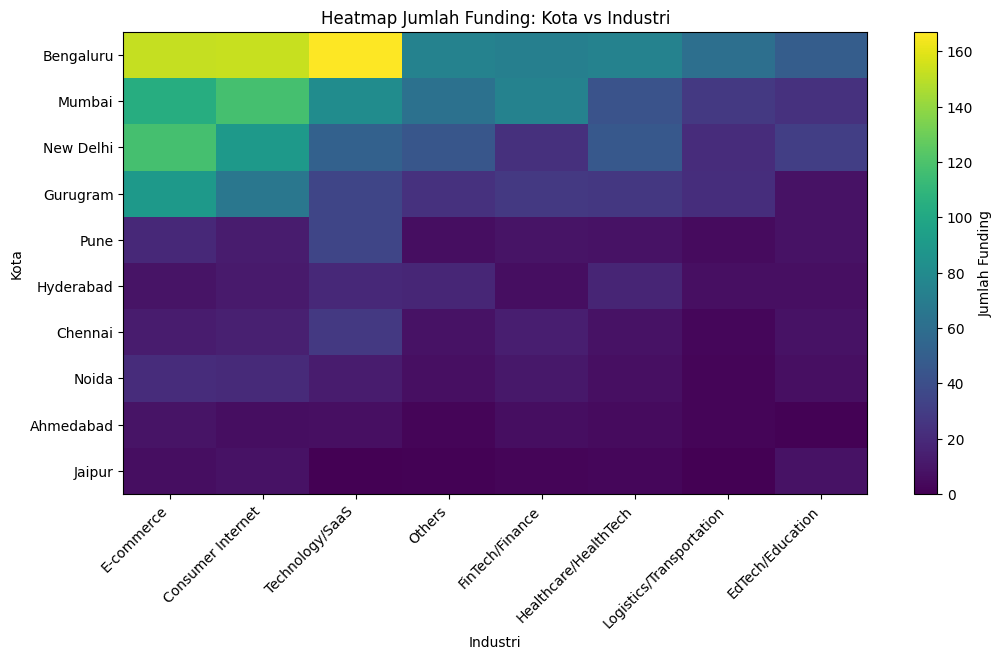

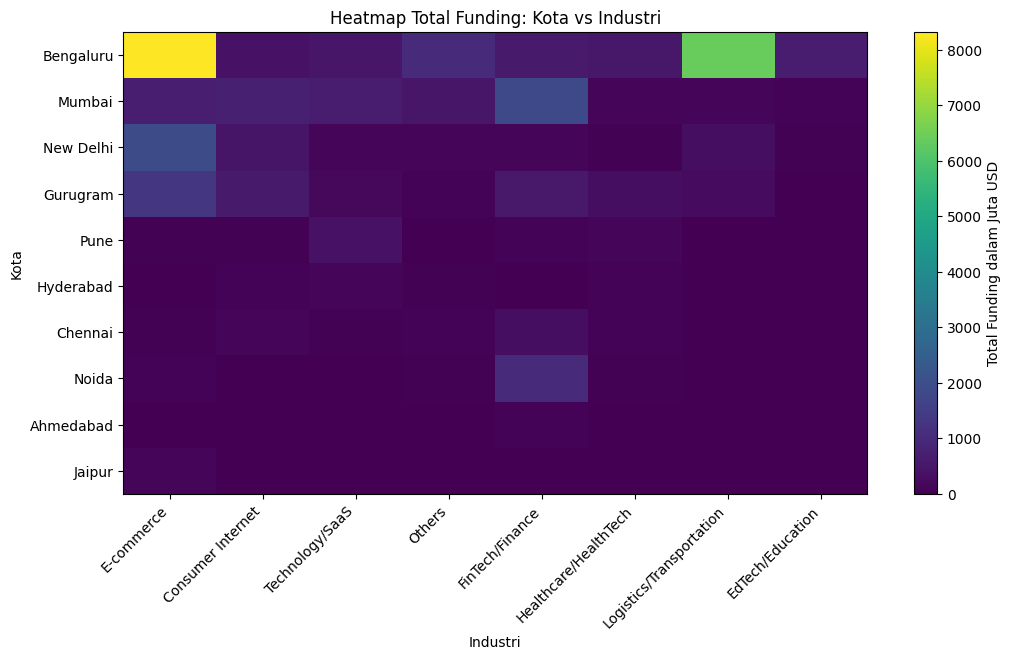


STEP 28G: Top Kombinasi Kota dan Industri Berdasarkan Jumlah Funding


jumlah_funding  jumlah_startup_unik  \
city_clean industry_group                                               
Bengaluru  Technology/SaaS                   167                  159   
           Consumer Internet                 153                  139   
           E-commerce                        152                  117   
Mumbai     Consumer Internet                 118                  109   
New Delhi  E-commerce                        118                  103   
Mumbai     E-commerce                        104                   88   
Gurugram   E-commerce                         90                   70   
New Delhi  Consumer Internet                  90                   85   
Mumbai     Technology/SaaS                    81                   75   
Bengaluru  Healthcare/HealthTech              74                   59   
           Others                             74                   70   
Mumbai     FinTech/Finance                    74                   67   
Bengaluru  FinTech/Finance                    72                   60   
Gurugram   Consumer Internet                  66                   61   
Mumbai     Others                             62                   59   

                                  total_funding_juta_usd  \
city_clean industry_group                                  
Bengaluru  Technology/SaaS                    496.842600   
           Consumer Internet                  411.303200   
           E-commerce                        8323.350468   
Mumbai     Consumer Internet                  737.076000   
New Delhi  E-commerce                        1940.695000   
Mumbai     E-commerce                         713.053495   
Gurugram   E-commerce                        1318.190065   
New Delhi  Consumer Internet                  464.930375   
Mumbai     Technology/SaaS                    675.064500   
Bengaluru  Healthcare/HealthTech              528.950000   
           Others                            1016.208600   
Mumbai     FinTech/Finance                   1832.847000   
Bengaluru  FinTech/Finance                    589.130000   
Gurugram   Consumer Internet                  602.365434   
Mumbai     Others                             496.085000   

                                  rata_rata_funding_juta_usd  \
city_clean industry_group                                      
Bengaluru  Technology/SaaS                          4.436095   
           Consumer Internet                        4.375566   
           E-commerce                              80.032216   
Mumbai     Consumer Internet                        9.330076   
New Delhi  E-commerce                              28.126014   
Mumbai     E-commerce                               9.382283   
Gurugram   E-commerce                              18.566057   
New Delhi  Consumer Internet                        9.116282   
Mumbai     Technology/SaaS                         12.273900   
Bengaluru  Healthcare/HealthTech                   11.754444   
           Others                                  17.828221   
Mumbai     FinTech/Finance                         31.065203   
Bengaluru  FinTech/Finance                         10.157414   
Gurugram   Consumer Internet                       15.059136   
Mumbai     Others                                  11.024111   

                                  median_funding_juta_usd  
city_clean industry_group                                  
Bengaluru  Technology/SaaS                          1.400  
           Consumer Internet                        1.000  
           E-commerce                               5.000  
Mumbai     Consumer Internet                        1.000  
New Delhi  E-commerce                               1.000  
Mumbai     E-commerce                               1.750  
Gurugram   E-commerce                               5.000  
New Delhi  Consumer Internet                        1.000  
Mumbai     Technology/SaaS                          2.700  
Bengaluru  Healthcare/


STEP 28H: Top Kombinasi Kota dan Industri Berdasarkan Total Funding


jumlah_funding  jumlah_startup_unik  \
city_clean industry_group                                                  
Bengaluru  E-commerce                           152                  117   
           Logistics/Transportation              61                   43   
New Delhi  E-commerce                           118                  103   
Mumbai     FinTech/Finance                       74                   67   
Gurugram   E-commerce                            90                   70   
Noida      FinTech/Finance                       11                    9   
Bengaluru  Others                                74                   70   
Mumbai     Consumer Internet                    118                  109   
           E-commerce                           104                   88   
           Technology/SaaS                       81                   75   
Bengaluru  EdTech/Education                      49                   42   
Gurugram   Consumer Internet                     66                   61   
Bengaluru  FinTech/Finance                       72                   60   
Gurugram   FinTech/Finance                       28                   18   
Bengaluru  Healthcare/HealthTech                 74                   59   

                                     total_funding_juta_usd  \
city_clean industry_group                                     
Bengaluru  E-commerce                           8323.350468   
           Logistics/Transportation             6392.562000   
New Delhi  E-commerce                           1940.695000   
Mumbai     FinTech/Finance                      1832.847000   
Gurugram   E-commerce                           1318.190065   
Noida      FinTech/Finance                      1037.968000   
Bengaluru  Others                               1016.208600   
Mumbai     Consumer Internet                     737.076000   
           E-commerce                            713.053495   
           Technology/SaaS                       675.064500   
Bengaluru  EdTech/Education                      629.083000   
Gurugram   Consumer Internet                     602.365434   
Bengaluru  FinTech/Finance                       589.130000   
Gurugram   FinTech/Finance                       572.601265   
Bengaluru  Healthcare/HealthTech                 528.950000   

                                     rata_rata_funding_juta_usd  \
city_clean industry_group                                         
Bengaluru  E-commerce                                 80.032216   
           Logistics/Transportation                  148.664233   
New Delhi  E-commerce                                 28.126014   
Mumbai     FinTech/Finance                            31.065203   
Gurugram   E-commerce                                 18.566057   
Noida      FinTech/Finance                           129.746000   
Bengaluru  Others                                     17.828221   
Mumbai     Consumer Internet                           9.330076   
           E-commerce                                  9.382283   
           Technology/SaaS                            12.273900   
Bengaluru  EdTech/Education                           15.727075   
Gurugram   Consumer Internet                          15.059136   
Bengaluru  FinTech/Finance                            10.157414   
Gurugram   FinTech/Finance                            22.904051   
Bengaluru  Healthcare/HealthTech                      11.754444   

                                     median_funding_juta_usd  
city_clean industry_group                                     
Bengaluru  E-commerce                                  5.000  
           Logistics/Transportation                   10.000  
New Delhi  E-commerce                                  1.000  
Mumbai     FinTech/Finance                             5.900  
Gurugram   E-commerce                                  5.000  
Noida      FinTech/Finance                             5.575  
Bengaluru  Others           

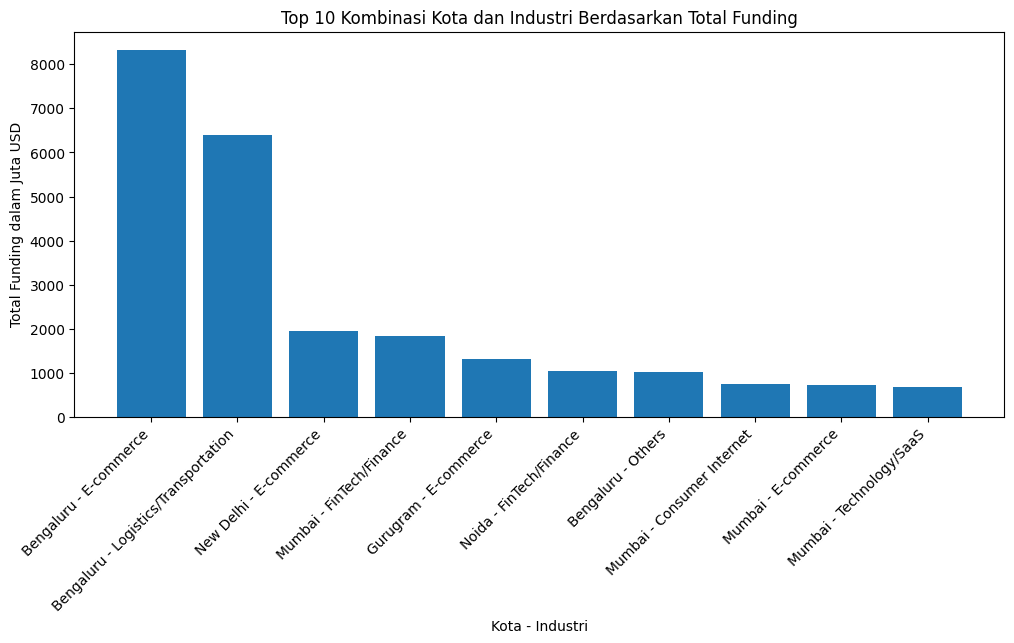


Insight Awal STEP 28:
1. Kombinasi kota-industri dengan jumlah funding terbanyak adalah Bengaluru - Technology/SaaS dengan 167.0 kali funding.
2. Kombinasi kota-industri dengan total funding terbesar adalah Bengaluru - E-commerce dengan total sekitar 8,323.35 juta USD.
3. Analisis ini membantu melihat spesialisasi kota dalam ekosistem startup India.
4. Jika satu kota dominan di banyak industri, kota tersebut dapat dianggap sebagai pusat utama ekosistem startup.


In [84]:
# STEP 28 Hubungan Kota dan Industri

# Mengambil data yang memiliki city_clean dan industry_group
city_industry_data = df[
    df['city_clean'].notnull() &
    df['industry_group'].notnull()
].copy()


# 1. Jumlah Funding Berdasarkan Kota dan Industri
city_industry_count = city_industry_data.pivot_table(
    index='city_clean',
    columns='industry_group',
    values='startup_name',
    aggfunc='count',
    fill_value=0
)

# Ambil top kota berdasarkan total jumlah funding
top_cities = city_industry_count.sum(axis=1).sort_values(ascending=False).head(10).index

# Ambil top industri berdasarkan total jumlah funding
top_industries = city_industry_count.sum(axis=0).sort_values(ascending=False).head(8).index

city_industry_count_top = city_industry_count.loc[top_cities, top_industries]

print("STEP 28A: Jumlah Funding Berdasarkan Kota dan Industri")
display(city_industry_count_top)


# 2. Total Funding Berdasarkan Kota dan Industri
city_industry_amount = city_industry_data.pivot_table(
    index='city_clean',
    columns='industry_group',
    values='amount_million_usd',
    aggfunc='sum',
    fill_value=0
)

city_industry_amount_top = city_industry_amount.loc[top_cities, top_industries]

print("\nSTEP 28B: Total Funding Berdasarkan Kota dan Industri dalam Juta USD")
display(city_industry_amount_top)


# 3. Industri Dominan di Setiap Kota Berdasarkan Jumlah Funding
dominant_industry_by_city_count = city_industry_count.idxmax(axis=1)
dominant_industry_by_city_count_value = city_industry_count.max(axis=1)

dominant_industry_by_city_count_df = pd.DataFrame({
    'industri_dominan_jumlah_funding': dominant_industry_by_city_count,
    'jumlah_funding': dominant_industry_by_city_count_value
}).sort_values(by='jumlah_funding', ascending=False)

print("\nSTEP 28C: Industri Dominan di Setiap Kota Berdasarkan Jumlah Funding")
display(dominant_industry_by_city_count_df.head(15))

# 4. Industri Dominan di Setiap Kota Berdasarkan Total Funding
dominant_industry_by_city_amount = city_industry_amount.idxmax(axis=1)
dominant_industry_by_city_amount_value = city_industry_amount.max(axis=1)

dominant_industry_by_city_amount_df = pd.DataFrame({
    'industri_dominan_total_funding': dominant_industry_by_city_amount,
    'total_funding_juta_usd': dominant_industry_by_city_amount_value
}).sort_values(by='total_funding_juta_usd', ascending=False)

print("\nSTEP 28D: Industri Dominan di Setiap Kota Berdasarkan Total Funding")
display(dominant_industry_by_city_amount_df.head(15))

# 5. Kota Dominan di Setiap Industri Berdasarkan Jumlah Funding
dominant_city_by_industry_count = city_industry_count.idxmax(axis=0)
dominant_city_by_industry_count_value = city_industry_count.max(axis=0)

dominant_city_by_industry_count_df = pd.DataFrame({
    'kota_dominan_jumlah_funding': dominant_city_by_industry_count,
    'jumlah_funding': dominant_city_by_industry_count_value
}).sort_values(by='jumlah_funding', ascending=False)

print("\nSTEP 28E: Kota Dominan di Setiap Industri Berdasarkan Jumlah Funding")
display(dominant_city_by_industry_count_df)


# 6. Kota Dominan di Setiap Industri Berdasarkan Total Funding
dominant_city_by_industry_amount = city_industry_amount.idxmax(axis=0)
dominant_city_by_industry_amount_value = city_industry_amount.max(axis=0)

dominant_city_by_industry_amount_df = pd.DataFrame({
    'kota_dominan_total_funding': dominant_city_by_industry_amount,
    'total_funding_juta_usd': dominant_city_by_industry_amount_value
}).sort_values(by='total_funding_juta_usd', ascending=False)

print("\nSTEP 28F: Kota Dominan di Setiap Industri Berdasarkan Total Funding")
display(dominant_city_by_industry_amount_df)


# 7. Visualisasi Heatmap Jumlah Funding: Kota vs Industri
plt.figure(figsize=(12, 6))

plt.imshow(city_industry_count_top, aspect='auto')

plt.title('Heatmap Jumlah Funding: Kota vs Industri')
plt.xlabel('Industri')
plt.ylabel('Kota')

plt.xticks(
    ticks=range(len(city_industry_count_top.columns)),
    labels=city_industry_count_top.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    ticks=range(len(city_industry_count_top.index)),
    labels=city_industry_count_top.index
)

plt.colorbar(label='Jumlah Funding')
plt.show()


# 8. Visualisasi Heatmap Total Funding: Kota vs Industri
plt.figure(figsize=(12, 6))

plt.imshow(city_industry_amount_top, aspect='auto')

plt.title('Heatmap Total Funding: Kota vs Industri')
plt.xlabel('Industri')
plt.ylabel('Kota')

plt.xticks(
    ticks=range(len(city_industry_amount_top.columns)),
    labels=city_industry_amount_top.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    ticks=range(len(city_industry_amount_top.index)),
    labels=city_industry_amount_top.index
)

plt.colorbar(label='Total Funding dalam Juta USD')
plt.show()


# 9. Top Kombinasi Kota dan Industri Berdasarkan Jumlah Funding
city_industry_combo_count = city_industry_data.groupby(
    ['city_clean', 'industry_group']
).agg(
    jumlah_funding=('startup_name', 'count'),
    jumlah_startup_unik=('startup_name', 'nunique'),
    total_funding_juta_usd=('amount_million_usd', 'sum'),
    rata_rata_funding_juta_usd=('amount_million_usd', 'mean'),
    median_funding_juta_usd=('amount_million_usd', 'median')
).sort_values(by='jumlah_funding', ascending=False)

print("\nSTEP 28G: Top Kombinasi Kota dan Industri Berdasarkan Jumlah Funding")
display(city_industry_combo_count.head(15))

# 10. Top Kombinasi Kota dan Industri Berdasarkan Total Funding
city_industry_combo_amount = city_industry_combo_count.sort_values(
    by='total_funding_juta_usd',
    ascending=False
)

print("\nSTEP 28H: Top Kombinasi Kota dan Industri Berdasarkan Total Funding")
display(city_industry_combo_amount.head(15))


# Visualisasi top kombinasi kota-industri berdasarkan total funding
top_combo_amount = city_industry_combo_amount.head(10).copy()

top_combo_amount['label'] = [
    f"{idx[0]} - {idx[1]}" for idx in top_combo_amount.index
]

plt.figure(figsize=(12, 5))
plt.bar(
    top_combo_amount['label'],
    top_combo_amount['total_funding_juta_usd']
)

plt.title('Top 10 Kombinasi Kota dan Industri Berdasarkan Total Funding')
plt.xlabel('Kota - Industri')
plt.ylabel('Total Funding dalam Juta USD')
plt.xticks(rotation=45, ha='right')
plt.show()


# 11. Insight Otomatis
top_combo_count_index = city_industry_combo_count.index[0]
top_combo_count_value = city_industry_combo_count.iloc[0]['jumlah_funding']

top_combo_amount_index = city_industry_combo_amount.index[0]
top_combo_amount_value = city_industry_combo_amount.iloc[0]['total_funding_juta_usd']

print("\nInsight Awal STEP 28:")
print(f"1. Kombinasi kota-industri dengan jumlah funding terbanyak adalah {top_combo_count_index[0]} - {top_combo_count_index[1]} dengan {top_combo_count_value} kali funding.")
print(f"2. Kombinasi kota-industri dengan total funding terbesar adalah {top_combo_amount_index[0]} - {top_combo_amount_index[1]} dengan total sekitar {top_combo_amount_value:,.2f} juta USD.")
print("3. Analisis ini membantu melihat spesialisasi kota dalam ekosistem startup India.")
print("4. Jika satu kota dominan di banyak industri, kota tersebut dapat dianggap sebagai pusat utama ekosistem startup.")

In [85]:
# STEP 29 Kesimpulan EDA Sementara

funding_with_amount = df[df['amount_million_usd'].notnull()].copy()

# Hitung ulang data tanpa outlier jika belum ada
Q1 = funding_with_amount['amount_million_usd'].quantile(0.25)
Q3 = funding_with_amount['amount_million_usd'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

df_no_outlier = funding_with_amount[
    funding_with_amount['amount_million_usd'] <= upper_bound
].copy()

outlier_funding = funding_with_amount[
    funding_with_amount['amount_million_usd'] > upper_bound
].copy()

# Ringkasan umum dataset
summary_metrics = pd.DataFrame({
    'metrik': [
        'Jumlah seluruh data',
        'Jumlah startup unik',
        'Jumlah data dengan amount valid',
        'Jumlah data tanpa outlier',
        'Jumlah data outlier',
        'Persentase data amount valid',
        'Tanggal awal',
        'Tanggal akhir',
        'Total funding',
        'Rata-rata funding',
        'Median funding',
        'Funding terbesar'
    ],
    'nilai': [
        df.shape[0],
        df['startup_name_clean'].nunique(),
        funding_with_amount.shape[0],
        df_no_outlier.shape[0],
        outlier_funding.shape[0],
        f"{(funding_with_amount.shape[0] / df.shape[0]) * 100:.2f}%",
        df['date_clean'].min(),
        df['date_clean'].max(),
        f"{funding_with_amount['amount_million_usd'].sum():,.2f} juta USD",
        f"{funding_with_amount['amount_million_usd'].mean():,.2f} juta USD",
        f"{funding_with_amount['amount_million_usd'].median():,.2f} juta USD",
        f"{funding_with_amount['amount_million_usd'].max():,.2f} juta USD"
    ]
})

print("STEP 29A: Ringkasan Umum Dataset")
display(summary_metrics)


# Menentukan insight utama secara otomatis
# Tahun
yearly_summary = df.groupby('year').agg(
    jumlah_funding=('startup_name_clean', 'count'),
    total_funding_juta_usd=('amount_million_usd', 'sum'),
    rata_rata_funding_juta_usd=('amount_million_usd', 'mean'),
    median_funding_juta_usd=('amount_million_usd', 'median')
)

top_year_count = yearly_summary['jumlah_funding'].idxmax()
top_year_amount = yearly_summary['total_funding_juta_usd'].idxmax()

# Bulan
monthly_summary = df.groupby('month_name').agg(
    jumlah_funding=('startup_name_clean', 'count'),
    total_funding_juta_usd=('amount_million_usd', 'sum')
)

top_month_count = monthly_summary['jumlah_funding'].idxmax()
top_month_amount = monthly_summary['total_funding_juta_usd'].idxmax()

# Kota
city_summary = df.groupby('city_clean').agg(
    jumlah_funding=('startup_name_clean', 'count'),
    total_funding_juta_usd=('amount_million_usd', 'sum')
).sort_values(by='total_funding_juta_usd', ascending=False)

top_city_count = city_summary.sort_values(by='jumlah_funding', ascending=False).index[0]
top_city_amount = city_summary.index[0]

# Industri
industry_summary = df.groupby('industry_group').agg(
    jumlah_funding=('startup_name_clean', 'count'),
    total_funding_juta_usd=('amount_million_usd', 'sum')
).sort_values(by='total_funding_juta_usd', ascending=False)

top_industry_count = industry_summary.sort_values(by='jumlah_funding', ascending=False).index[0]
top_industry_amount = industry_summary.index[0]

# Jenis investasi
investment_summary = df.groupby('investment_type_clean').agg(
    jumlah_funding=('startup_name_clean', 'count'),
    total_funding_juta_usd=('amount_million_usd', 'sum')
).sort_values(by='total_funding_juta_usd', ascending=False)

top_investment_count = investment_summary.sort_values(by='jumlah_funding', ascending=False).index[0]
top_investment_amount = investment_summary.index[0]

# Startup repeat funding
startup_repeat_summary = df.groupby('startup_name_clean').agg(
    jumlah_funding=('startup_name_clean', 'count'),
    total_funding_juta_usd=('amount_million_usd', 'sum')
)

repeat_startups = startup_repeat_summary[
    startup_repeat_summary['jumlah_funding'] > 1
]

top_startup_repeat_count = repeat_startups.sort_values(
    by='jumlah_funding',
    ascending=False
).index[0]

top_startup_repeat_amount = repeat_startups.sort_values(
    by='total_funding_juta_usd',
    ascending=False
).index[0]

# Investor
investor_funding_clean = investor_funding_clean.sort_values(
    by='total_funding_juta_usd',
    ascending=False
)

top_investor_amount = investor_funding_clean.index[0]

top_investor_count = investor_funding_clean.sort_values(
    by='jumlah_investasi',
    ascending=False
).index[0]

# Outlier
total_funding_all = funding_with_amount['amount_million_usd'].sum()
total_funding_outlier = outlier_funding['amount_million_usd'].sum()
outlier_contribution = (total_funding_outlier / total_funding_all) * 100


# Tabel kesimpulan utama

main_findings = pd.DataFrame({
    'aspek_analisis': [
        'Tahun dengan jumlah funding terbanyak',
        'Tahun dengan total funding terbesar',
        'Bulan dengan jumlah funding terbanyak',
        'Bulan dengan total funding terbesar',
        'Kota dengan jumlah funding terbanyak',
        'Kota dengan total funding terbesar',
        'Industri dengan jumlah funding terbanyak',
        'Industri dengan total funding terbesar',
        'Jenis investasi paling sering',
        'Jenis investasi dengan total funding terbesar',
        'Startup dengan funding berulang terbanyak',
        'Startup repeat funding dengan total funding terbesar',
        'Investor paling aktif',
        'Investor dengan total funding terbesar',
        'Kontribusi outlier terhadap total funding'
    ],
    'hasil': [
        top_year_count,
        top_year_amount,
        top_month_count,
        top_month_amount,
        top_city_count,
        top_city_amount,
        top_industry_count,
        top_industry_amount,
        top_investment_count,
        top_investment_amount,
        top_startup_repeat_count,
        top_startup_repeat_amount,
        top_investor_count,
        top_investor_amount,
        f"{outlier_contribution:.2f}%"
    ]
})

print("\nSTEP 29B: Tabel Kesimpulan Utama EDA")
display(main_findings)

# Narasi insight otomatis
print("\nSTEP 29C: Narasi Kesimpulan EDA Sementara")
print("="*70)

print(f"1. Dataset berisi {df.shape[0]} data funding startup India dengan rentang waktu dari {df['date_clean'].min().date()} sampai {df['date_clean'].max().date()}.")

print(f"2. Tahun dengan jumlah funding terbanyak adalah {top_year_count}, sedangkan tahun dengan total funding terbesar adalah {top_year_amount}.")

print(f"3. Kota yang paling dominan adalah {top_city_amount}, baik dari sisi total funding maupun sebagai pusat utama berbagai sektor startup.")

print(f"4. Industri dengan jumlah funding terbanyak adalah {top_industry_count}, sedangkan industri dengan total funding terbesar adalah {top_industry_amount}.")

print(f"5. Jenis investasi yang paling sering muncul adalah {top_investment_count}, tetapi total funding terbesar berasal dari {top_investment_amount}.")

print(f"6. Startup dengan funding berulang terbanyak adalah {top_startup_repeat_count}, sedangkan startup repeat funding dengan total funding terbesar adalah {top_startup_repeat_amount}.")

print(f"7. Investor paling aktif adalah {top_investor_count}, sedangkan investor dengan total funding terbesar adalah {top_investor_amount}.")

print(f"8. Outlier memiliki pengaruh sangat besar terhadap total funding, yaitu sekitar {outlier_contribution:.2f}% dari total funding.")

print("9. Secara umum, ekosistem pendanaan startup India sangat dipengaruhi oleh kota Bengaluru, sektor E-commerce, jenis investasi Private Equity, dan sejumlah deal besar bernilai ekstrem.")


# Simpan hasil cleaning dan ringkasan EDA

df.to_csv('/content/startup_funding_cleaned.csv', index=False)
summary_metrics.to_csv('/content/summary_metrics.csv', index=False)
main_findings.to_csv('/content/main_findings.csv', index=False)

print("\nSTEP 29D: File berhasil disimpan")
print("1. startup_funding_cleaned.csv")
print("2. summary_metrics.csv")
print("3. main_findings.csv")

STEP 29A: Ringkasan Umum Dataset


,metrik,nilai
0,Jumlah seluruh data,3044
1,Jumlah startup unik,2443
2,Jumlah data dengan amount valid,2073
3,Jumlah data tanpa outlier,1788
4,Jumlah data outlier,285
5,Persentase data amount valid,68.10%
6,Tanggal awal,2015-01-02 00:00:00
7,Tanggal akhir,2020-01-13 00:00:00
8,Total funding,"38,143.91 juta USD"
9,Rata-rata funding,18.40 juta USD



STEP 29B: Tabel Kesimpulan Utama EDA


,aspek_analisis,hasil
0,Tahun dengan jumlah funding terbanyak,2016
1,Tahun dengan total funding terbesar,2017
2,Bulan dengan jumlah funding terbanyak,June
3,Bulan dengan total funding terbesar,August
4,Kota dengan jumlah funding terbanyak,Bengaluru
5,Kota dengan total funding terbesar,Bengaluru
6,Industri dengan jumlah funding terbanyak,E-commerce
7,Industri dengan total funding terbesar,E-commerce
8,Jenis investasi paling sering,Seed Funding
9,Jenis investasi dengan total funding terbesar,Private Equity



STEP 29C: Narasi Kesimpulan EDA Sementara
1. Dataset berisi 3044 data funding startup India dengan rentang waktu dari 2015-01-02 sampai 2020-01-13.
2. Tahun dengan jumlah funding terbanyak adalah 2016, sedangkan tahun dengan total funding terbesar adalah 2017.
3. Kota yang paling dominan adalah Bengaluru, baik dari sisi total funding maupun sebagai pusat utama berbagai sektor startup.
4. Industri dengan jumlah funding terbanyak adalah E-commerce, sedangkan industri dengan total funding terbesar adalah E-commerce.
5. Jenis investasi yang paling sering muncul adalah Seed Funding, tetapi total funding terbesar berasal dari Private Equity.
6. Startup dengan funding berulang terbanyak adalah Ola, sedangkan startup repeat funding dengan total funding terbesar adalah Flipkart.
7. Investor paling aktif adalah Sequoia Capital, sedangkan investor dengan total funding terbesar adalah SoftBank.
8. Outlier memiliki pengaruh sangat besar terhadap total funding, yaitu sekitar 85.12% dari total fundi

# STEP 30 - Kesimpulan EDA Sementara

## 1. Ringkasan Dataset

Dataset Indian Startup Funding berisi data pendanaan startup India dengan total 3.044 baris data. Setelah proses pembersihan data, ditemukan bahwa dataset memiliki rentang waktu dari 2 Januari 2015 sampai 13 Januari 2020.

Dari seluruh data, terdapat 2.073 data yang memiliki nilai funding valid, atau sekitar 68,10% dari total data. Sisanya memiliki nilai funding yang kosong, tidak diketahui, atau tidak dapat digunakan untuk analisis numerik.

Secara keseluruhan, total funding yang tercatat adalah sekitar 38.143,91 juta USD. Rata-rata funding berada pada angka 18,40 juta USD, sedangkan median funding hanya 1,75 juta USD. Perbedaan besar antara rata-rata dan median menunjukkan bahwa data funding memiliki distribusi yang sangat miring karena dipengaruhi oleh beberapa nilai funding yang sangat besar.

## 2. Tren Funding Berdasarkan Waktu

Berdasarkan jumlah funding, tahun 2016 menjadi tahun dengan aktivitas pendanaan startup terbanyak. Pada tahun tersebut terdapat 993 kali funding. Namun, jika dilihat dari total nilai funding, tahun 2017 menjadi tahun dengan total funding terbesar.

Hal ini menunjukkan bahwa jumlah funding yang banyak tidak selalu menghasilkan total funding terbesar. Tahun 2016 memiliki jumlah deal yang tinggi, tetapi nilai funding rata-ratanya lebih kecil dibandingkan tahun 2017 dan 2019.

Tahun 2020 tidak dapat dibandingkan secara langsung dengan tahun lainnya karena data pada tahun tersebut hanya mencakup bulan Januari.

## 3. Analisis Berdasarkan Bulan

Secara umum, bulan June menjadi bulan dengan jumlah funding terbanyak. Namun, bulan August menjadi bulan dengan total funding terbesar.

Perbedaan ini menunjukkan bahwa aktivitas funding paling sering terjadi pada bulan June, sedangkan nilai funding terbesar terkonsentrasi pada bulan August. Lonjakan total funding pada bulan August kemungkinan besar dipengaruhi oleh beberapa deal besar atau outlier.

## 4. Analisis Berdasarkan Kota

Bengaluru menjadi kota yang paling dominan dalam ekosistem pendanaan startup India. Kota ini menempati posisi pertama baik dari sisi jumlah funding maupun total funding.

Bengaluru juga menjadi pusat utama berbagai sektor startup, khususnya E-commerce, Technology/SaaS, Logistics/Transportation, EdTech/Education, dan Healthcare/HealthTech.

Selain Bengaluru, kota lain yang juga memiliki peran besar adalah Mumbai, New Delhi, Gurugram, Noida, Pune, dan Chennai. Mumbai cukup menonjol pada sektor FinTech/Finance, sedangkan New Delhi dan Gurugram kuat pada sektor E-commerce.

## 5. Analisis Berdasarkan Industri

Industri E-commerce menjadi sektor yang paling dominan dalam dataset ini. Sektor ini memiliki jumlah funding terbanyak sekaligus total funding terbesar.

Selain E-commerce, sektor lain yang juga menonjol adalah Consumer Internet, Technology/SaaS, FinTech/Finance, Logistics/Transportation, Healthcare/HealthTech, dan EdTech/Education.

Namun, hasil analisis juga menunjukkan bahwa sektor dengan jumlah funding terbanyak tidak selalu menjadi sektor dengan total funding terbesar pada setiap tahun. Contohnya, pada tahun 2019, sektor Logistics/Transportation memiliki total funding terbesar meskipun bukan sektor dengan jumlah funding terbanyak.

## 6. Analisis Berdasarkan Jenis Investasi

Jenis investasi yang paling sering muncul adalah Seed Funding. Hal ini menunjukkan bahwa banyak startup dalam dataset berada pada tahap awal pendanaan.

Namun, dari sisi total nilai funding, Private Equity menjadi jenis investasi dengan total funding terbesar. Ini menunjukkan bahwa meskipun Seed Funding lebih sering terjadi, nilai pendanaan terbesar justru berasal dari tahap investasi yang lebih besar seperti Private Equity.

Dengan kata lain, Seed Funding dominan dari sisi frekuensi, sedangkan Private Equity dominan dari sisi nilai pendanaan.

## 7. Analisis Investor

Investor paling aktif berdasarkan frekuensi kemunculan adalah Sequoia Capital. Investor ini muncul sebanyak 112 kali dalam dataset setelah proses pembersihan nama investor.

Namun, investor dengan total funding terbesar adalah SoftBank. Hal ini menunjukkan bahwa Sequoia Capital lebih aktif dari sisi jumlah investasi, sedangkan SoftBank lebih banyak terlibat dalam deal dengan nilai funding besar.

Perlu dicatat bahwa total funding investor dalam analisis ini dihitung berdasarkan nilai deal yang melibatkan investor tersebut, bukan kontribusi pasti dari masing-masing investor.

## 8. Analisis Startup dengan Funding Berulang

Terdapat 391 startup yang mendapatkan funding lebih dari satu kali. Startup dengan jumlah funding berulang terbanyak adalah Ola, dengan 13 kali funding.

Sementara itu, startup repeat funding dengan total funding terbesar adalah Flipkart, dengan total funding sekitar 4.759,70 juta USD. Paytm juga menjadi salah satu startup besar dengan total funding sekitar 3.348,95 juta USD.

Startup yang mendapatkan funding berulang dapat dianggap memiliki daya tarik tinggi bagi investor karena mampu memperoleh pendanaan dalam beberapa putaran.

## 9. Analisis Outlier

Analisis outlier menunjukkan bahwa funding dengan nilai di atas 19,27 juta USD dikategorikan sebagai outlier berdasarkan metode IQR.

Terdapat 285 data funding yang termasuk outlier. Meskipun jumlahnya tidak terlalu besar dibandingkan keseluruhan data, outlier ini menyumbang sekitar 85,12% dari total funding.

Hal ini menunjukkan bahwa total funding startup India sangat dipengaruhi oleh sejumlah kecil deal bernilai sangat besar. Oleh karena itu, analisis berdasarkan total funding perlu dibaca dengan hati-hati karena dapat sangat dipengaruhi oleh outlier.

## 10. Kesimpulan Utama

Berdasarkan hasil EDA, dapat disimpulkan bahwa ekosistem pendanaan startup India dalam dataset ini sangat dipengaruhi oleh beberapa faktor utama.

Pertama, Bengaluru merupakan pusat utama pendanaan startup India. Kedua, sektor E-commerce menjadi sektor yang paling dominan baik dari sisi jumlah funding maupun total funding. Ketiga, Seed Funding merupakan jenis investasi yang paling sering terjadi, sedangkan Private Equity menghasilkan total funding terbesar. Keempat, investor seperti Sequoia Capital dan SoftBank memiliki peran penting dalam ekosistem pendanaan startup India. Kelima, outlier memiliki pengaruh yang sangat besar terhadap total funding sehingga perlu diperhatikan dalam interpretasi hasil analisis.

Secara keseluruhan, dataset ini menunjukkan bahwa pendanaan startup India tidak hanya dipengaruhi oleh banyaknya jumlah deal, tetapi juga oleh beberapa deal besar yang sangat menentukan total funding.